# Crypto Quant Research — Executive Summary

**One question:** *is there a tradeable, repeatable edge in liquid crypto, and can we
prove it isn't just an in-sample mirage?*

This notebook builds the machinery to tell a real edge from one that only looks real,
then reports — honestly — what survives. Every strategy is selected on a **training
window only** and judged once on a **locked-away test set** it never saw.

### The headline (master scoreboard)

| # | Strategy | What it bets on | Train | Val | **Test (lockbox)** | Verdict |
|---|----------|-----------------|:---:|:---:|:---:|---|
| **M1** | Long-only low-vol | cross-sectional return prediction | 1.32 | 0.31 | **−0.86** | ❌ it was market **beta**, not skill (DSR ≈ 0) |
| **M2** | Long-short stat-arb | cross-sectional return prediction | −0.07 | −1.01 | **+0.48** | ❌ not significant — DSR ≈ 0.06, sign flips by period |
| **M3** | Vol-managed trend | **risk management** (trend + vol target) | — | — | **full-cycle ✅** | ✅ **halves drawdown** (BTC −77%→−45%); holds on 2017–26 |
| **M4** | Funding carry | structural funding premium | 5.2 | 10.0 | **1.6\*** | ⚠️ real but **decayed to ~2%/yr** & cost-fragile |
| **M5** | Combined book | M3 + M4, risk-parity | 4.9 | 4.0 | **0.52** | ✅ tiny drawdown (−3%), but carry-dominated & thin |

<sub>Sharpe ratios. \*M4 test Sharpe uses idealized costs; it does **not** survive realistic frictions (see M4).</sub>

> **Bottom line.** With spot price data alone, *return prediction does not survive the
> lockbox* — the universe offers only **~2–4 independent bets** in roughly 1½ market
> cycles, so almost anything looks significant in-sample and almost nothing holds out
> (M1, M2). The one thing that is genuinely **robust is risk management**: a trend +
> volatility-targeting overlay roughly **halves drawdowns**, and it repeats over an
> *independent* 2017–2019 cycle the main sample never saw (M3). Adding **funding-rate
> data** reveals a real market-neutral **carry** premium (M4) — but, honestly, that
> premium **compressed to ~2%/yr by the test period and is fragile to realistic costs**.
> The most investable construction is the **carry + vol-managed-trend blend** (M5): very
> low drawdown, though its returns are thin and carry-dominated. **The headline isn't a
> money machine — it's a rigorous demonstration of what does and doesn't survive honest
> out-of-sample testing.**

### How to read this document
It is organized as **self-contained modules** — skim the scoreboard above, then dive into
whichever module interests you. Each follows the same shape: **Question → Method →
Result → Verdict.** The shared engine (§3) and the statistical/methodology details
(Appendix) are reference material you can skip on a first read.

- **§1 Setup & research discipline** · **§2 Data & universe** · **§3 Shared engine**
- **M1** Long-only · **M2** Long-short · **Lockbox** (the verdict on M1+M2)
- **M3** Vol-managed trend · **M4** Funding carry · **M5** Combined book
- **§R** Validation, robustness & data-snooping · **Appendix** — methodology, toolkit, rejected experiments

> **On rigor.** Beyond the train/validation/test lockbox, §R stress-tests every conclusion with
> the modern anti-overfitting toolkit — **Combinatorial Purged CV → Probability of Backtest
> Overfitting**, **White's Reality Check**, anchored walk-forward, bootstrap Sharpe confidence
> intervals, Deflated Sharpe & minimum track-record length, per-regime analysis, and a capacity
> model. Modules also showcase **Hierarchical Risk Parity (Ledoit–Wolf)** and **PCA factor
> neutralization**. The point isn't more strategies — it's *defensible* ones.


# §1 · Setup & Research Discipline

The single most important idea in this project is the **guardrail against overfitting**.
We use a **three-way holdout**:

| Window | Dates | Role |
|---|---|---|
| **Train** | 2020-01 → 2023-12 | build signals, choose every parameter (walk-forward) |
| **Validation** | 2024-01 → 2025-06 | confirm out-of-sample while researching |
| **Test (lockbox)** | 2025-07 → 2026-05 | **held out of every research frame, opened once** |

Selection touches **train only**; the lockbox is opened a single logged time at the end.
We also count every configuration tried (`N_TRIALS`) and discount each Sharpe by a
**Deflated Sharpe Ratio** — the math lives in the Appendix; the discipline lives here.


In [1]:
# ============================================================
# Adaptive Multi-Strategy Crypto Quant Research Engine
# Section 1: Imports
# ============================================================

# ------------------------------------------------------------
# 1. Core Data Libraries
# ------------------------------------------------------------

# pandas is used for time-series data, price matrices, returns, portfolio weights,
# and performance tables.
import pandas as pd

# numpy is used for vectorized math, numerical operations, and signal calculations.
import numpy as np


# ------------------------------------------------------------
# 2. Visualization
# ------------------------------------------------------------

# matplotlib is used for cumulative returns, drawdowns, heatmaps,
# rolling Sharpe plots, and strategy comparisons.
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 3. Date, File, and Download Utilities
# ------------------------------------------------------------

# datetime tools help define backtest windows and handle historical data ranges.
from datetime import datetime, timedelta

# time can be used to pause between downloads if needed.
import time

# warnings lets us suppress non-critical notebook warnings for cleaner output.
import warnings

# os and pathlib help create folders and manage local cached data files.
import os
from pathlib import Path

# zipfile and BytesIO are needed because Binance public historical files
# are downloaded as compressed .zip files.
import zipfile
from io import BytesIO

# requests is used to download public historical data files without relying
# on the live Binance API client.
import requests


# ------------------------------------------------------------
# 4. Statistical Analysis
# ------------------------------------------------------------

# scipy.stats is used for t-tests, correlations, skew, kurtosis,
# and signal predictiveness analysis.
from scipy import stats

# statsmodels is used for alpha/beta regressions against benchmarks.
import statsmodels.api as sm


# ------------------------------------------------------------
# 5. Optimization
# ------------------------------------------------------------

# scipy.optimize will be used later for portfolio optimization,
# such as maximizing expected return after risk and turnover penalties.
from scipy.optimize import minimize


# ------------------------------------------------------------
# 6. Display and Plot Settings
# ------------------------------------------------------------

# Make pandas output easier to inspect in the notebook.
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

# Use readable default chart sizes.
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

# Suppress non-critical warnings to keep the notebook clean.
warnings.filterwarnings("ignore")

# Set random seed for reproducibility when random sampling or optimization
# routines are used later.
np.random.seed(42)

print("All core libraries loaded.")

All core libraries loaded.


In [2]:
# ============================================================
# Global Project Settings
# ============================================================

# ------------------------------------------------------------
# 1. Backtest Date Range
# ------------------------------------------------------------

# We begin in 2020 because this gives the project multiple crypto regimes:
# - 2020-2021 bull market
# - 2022 crypto crash / high-volatility bear market
# - 2023 recovery period
# - 2024+ validation period
START_DATE = "2020-01-01"

# Parameters and strategy decisions will be selected using only data up to this date.
# This prevents lookahead bias because validation data is not used for optimization.
TRAIN_END_DATE = "2023-12-31"

# Validation period begins after the training set.
# All final strategy results should be reported on this out-of-sample period.
VALIDATION_START_DATE = "2024-01-01"

# End date for the historical sample.
# This can be updated depending on what data is available.
END_DATE = "2026-05-31"


# ------------------------------------------------------------
# 1b. Three-Way Holdout (Option A): train / validation / test
# ------------------------------------------------------------
# Validation ends here. Everything we may look at while researching
# (build signals, select parameters, confirm) is TRAIN + VALIDATION,
# together called the "development" window.
VALIDATION_END_DATE = "2025-06-30"

# The TEST period is a LOCKBOX: held out of every research frame and opened
# exactly once, in the final out-of-sample report. Nothing is selected on it.
TEST_START_DATE = "2025-07-01"
TEST_END_DATE = END_DATE  # 2026-05-31


# ------------------------------------------------------------
# 2. Timeframe Selection
# ------------------------------------------------------------

# Primary interval is 4h because many crypto strategies from class,
# such as channel breakouts, moving-average crossovers, short-term reversal,
# and intraday momentum can be tested at this frequency.
PRIMARY_INTERVAL = "4h"

# Secondary interval is daily.
# Daily data is cleaner for medium-term momentum, volatility estimation,
# benchmark comparisons, and portfolio-level risk analysis.
SECONDARY_INTERVAL = "1d"


# ------------------------------------------------------------
# 3. Universe Construction
# ------------------------------------------------------------

# We focus on USDT-quoted spot pairs because they are usually among the most liquid
# Binance crypto markets and put all assets in a common quote currency.
QUOTE_ASSET = "USDT"

# We start with a broad target universe to avoid cherry-picking assets.
# The final universe may be smaller after filtering for data quality,
# liquidity, and sufficient trading history.
TARGET_UNIVERSE_SIZE = 150

# Require at least 2 years of data when possible.
# This helps avoid strategies being driven by assets with very short histories.
MIN_HISTORY_DAYS = 365 * 2

# Minimum average daily dollar volume filter.
# This removes illiquid assets where backtested alpha may be unrealistic
# because real execution would suffer from high slippage.
MIN_AVG_DAILY_VOLUME_USD = 5_000_000


# ------------------------------------------------------------
# 4. Transaction Cost Assumptions
# ------------------------------------------------------------

# Gross case: ignores transaction costs.
# Useful for measuring raw signal quality before implementation costs.
TCOST_GROSS = 0.0000

# Limit-order case: assumes only commission cost.
# The class project guideline suggests approximately 7 bps for limit orders.
TCOST_LIMIT = 0.0007

# Market-order base case: assumes commission + slippage.
# The class project guideline suggests approximately 20 bps total cost.
TCOST_MARKET = 0.0020

# Stress case: higher transaction cost assumption.
# Used to test whether the strategy remains robust under worse execution.
TCOST_STRESS = 0.0050

# Main cost assumption for reported strategy results.
# We use the conservative market-order estimate as the base case.
BASE_TCOST = TCOST_MARKET


# ------------------------------------------------------------
# 5. Portfolio Construction Assumptions
# ------------------------------------------------------------

# Maximum allowed weight in one asset.
# This prevents the portfolio from becoming overly concentrated in one coin,
# which is especially important in crypto because individual assets can crash heavily.
MAX_WEIGHT_PER_ASSET = 0.10

# Target annualized volatility for risk scaling.
# Later, volatility targeting will reduce exposure when forecasted volatility is high
# and increase exposure when forecasted volatility is low.
TARGET_ANNUAL_VOL = 0.25


# ------------------------------------------------------------
# 6. Annualization Assumptions
# ------------------------------------------------------------

# Crypto trades 24/7, so we use 365 trading days per year instead of 252.
DAYS_PER_YEAR_CRYPTO = 365

# There are six 4-hour bars in each day.
BARS_PER_DAY_4H = 6

# Annualization factor for 4h strategies.
BARS_PER_YEAR_4H = BARS_PER_DAY_4H * DAYS_PER_YEAR_CRYPTO

# Annualization factor for daily strategies.
BARS_PER_YEAR_1D = DAYS_PER_YEAR_CRYPTO


# ------------------------------------------------------------
# 7. Print Configuration Summary
# ------------------------------------------------------------

print("Project settings initialized.")
print(f"Training period: {START_DATE} to {TRAIN_END_DATE}")
print(f"Validation period: {VALIDATION_START_DATE} to {VALIDATION_END_DATE}")
print(f"Test period (LOCKBOX, held out): {TEST_START_DATE} to {TEST_END_DATE}")
print(f"Primary interval: {PRIMARY_INTERVAL}")
print(f"Secondary interval: {SECONDARY_INTERVAL}")
print(f"Target universe size before filtering: {TARGET_UNIVERSE_SIZE}")
print(f"Base transaction cost assumption: {BASE_TCOST:.4%}")
print(f"Max asset weight: {MAX_WEIGHT_PER_ASSET:.0%}")
print(f"Target annualized volatility: {TARGET_ANNUAL_VOL:.0%}")

Project settings initialized.
Training period: 2020-01-01 to 2023-12-31
Validation period: 2024-01-01 to 2025-06-30
Test period (LOCKBOX, held out): 2025-07-01 to 2026-05-31
Primary interval: 4h
Secondary interval: 1d
Target universe size before filtering: 150
Base transaction cost assumption: 0.2000%
Max asset weight: 10%
Target annualized volatility: 25%


In [3]:
# ============================================================
# Research Discipline Infrastructure (three-way holdout + ledgers)
# ============================================================
# Central period definitions, period-aware slicing helpers, and the guards
# that keep this project honest about overfitting:
#   - split_three_way / slice_period: consistent train|validation|test slicing
#   - LOCKBOX: wraps every access to the test set, logged, opened once at the end
#   - N_TRIALS: counts configurations evaluated (feeds the Deflated Sharpe Ratio)
#   - VALIDATION_PEEKS: counts decisions informed by the validation set

def _ts(d):
    return pd.to_datetime(d, utc=True)

PERIOD_BOUNDS = {
    "train":      (_ts(START_DATE),            _ts(TRAIN_END_DATE)),
    "validation": (_ts(VALIDATION_START_DATE), _ts(VALIDATION_END_DATE)),
    "test":       (_ts(TEST_START_DATE),       _ts(TEST_END_DATE)),
    "dev":        (_ts(START_DATE),            _ts(VALIDATION_END_DATE)),
    "all":        (_ts(START_DATE),            _ts(END_DATE)),
}

def period_mask(index, period):
    """Boolean mask selecting one period from a DatetimeIndex."""
    lo, hi = PERIOD_BOUNDS[period]
    return (index >= lo) & (index <= hi)

def slice_period(obj, period):
    """Slice a Series/DataFrame (DatetimeIndex) to one period, inclusive."""
    lo, hi = PERIOD_BOUNDS[period]
    return obj.loc[lo:hi]

def split_three_way(obj):
    """Return (train, validation, test) slices."""
    return (slice_period(obj, "train"),
            slice_period(obj, "validation"),
            slice_period(obj, "test"))


class _AccessLedger:
    """Counts and records how often a resource is consulted."""
    def __init__(self, name):
        self.name = name
        self.count = 0
        self.log = []
    def touch(self, reason=""):
        self.count += 1
        self.log.append(reason)
        return self.count

# Number of distinct strategy/parameter configurations evaluated anywhere.
# The Deflated Sharpe Ratio (Phase 2) uses this to discount the best result.
N_TRIALS = _AccessLedger("trials")

# Every time the validation set informs a decision, call VALIDATION_PEEKS.touch(reason).
VALIDATION_PEEKS = _AccessLedger("validation_peeks")


class _Lockbox:
    """The test set is held out. Opening it is logged; it should happen once, at the end."""
    def __init__(self):
        self.opened = 0
        self.reasons = []
    def slice(self, obj, reason="final out-of-sample report"):
        self.opened += 1
        self.reasons.append(reason)
        print(f"LOCKBOX OPENED (access #{self.opened}): {reason}")
        return slice_period(obj, "test")

LOCKBOX = _Lockbox()

print("Research-discipline infrastructure loaded.")
print(f"  train      : {PERIOD_BOUNDS['train'][0].date()} .. {PERIOD_BOUNDS['train'][1].date()}")
print(f"  validation : {PERIOD_BOUNDS['validation'][0].date()} .. {PERIOD_BOUNDS['validation'][1].date()}")
print(f"  test (lock): {PERIOD_BOUNDS['test'][0].date()} .. {PERIOD_BOUNDS['test'][1].date()}")


Research-discipline infrastructure loaded.
  train      : 2020-01-01 .. 2023-12-31
  validation : 2024-01-01 .. 2025-06-30
  test (lock): 2025-07-01 .. 2026-05-31


In [4]:
# ============================================================
# Statistical Toolkit (overfitting-aware metrics)
# ============================================================
# The tools that make selection honest:
#   - probabilistic_sharpe_ratio / deflated_sharpe_ratio: discount a Sharpe for
#     short samples, non-normality, and the number of trials (Bailey & Lopez de
#     Prado). DSR is the headline "is this real?" number.
#   - newey_west_tstat / hac_alpha_beta: HAC standard errors; returns autocorrelate
#     so naive t-stats overstate significance.
#   - effective_breadth: how many independent bets the universe really offers.
#   - block_bootstrap_sharpe_ci: nonparametric confidence interval for a Sharpe.
from scipy.stats import norm

_EULER_GAMMA = 0.5772156649015329


def _ret_moments(returns):
    r = pd.Series(returns).dropna().astype(float)
    T = len(r)
    s = r.std(ddof=1)
    if T < 3 or s == 0 or not np.isfinite(s):
        return None
    return T, r.mean() / s, r.skew(), r.kurtosis()   # pandas kurtosis = EXCESS


def probabilistic_sharpe_ratio(returns, sr_benchmark_period=0.0):
    """P(true per-period Sharpe > benchmark). Bailey & Lopez de Prado (2012)."""
    m = _ret_moments(returns)
    if m is None:
        return np.nan
    T, sr, skew, exkurt = m
    var_term = 1.0 - skew * sr + ((exkurt + 2.0) / 4.0) * sr * sr   # (gamma4-1)/4
    if var_term <= 0:
        return np.nan
    z = (sr - sr_benchmark_period) * np.sqrt(T - 1) / np.sqrt(var_term)
    return float(norm.cdf(z))


def expected_max_sharpe(sr_variance, n_trials):
    """Expected maximum per-period Sharpe under the null across n_trials (LdP)."""
    N = max(2, int(n_trials))
    return np.sqrt(max(sr_variance, 0.0)) * (
        (1 - _EULER_GAMMA) * norm.ppf(1 - 1.0 / N)
        + _EULER_GAMMA * norm.ppf(1 - 1.0 / (N * np.e))
    )


def deflated_sharpe_ratio(returns, n_trials, sr_variance=None):
    """
    Deflated Sharpe Ratio: PSR against the Sharpe you'd expect as the best of
    `n_trials` independent attempts on noise. Near 1 => survives multiple testing.
    """
    m = _ret_moments(returns)
    if m is None:
        return np.nan
    T, sr, skew, exkurt = m
    var_term = 1.0 - skew * sr + ((exkurt + 2.0) / 4.0) * sr * sr
    if var_term <= 0:
        return np.nan
    if sr_variance is None:
        sr_variance = var_term / (T - 1)          # variance of this SR estimate
    return probabilistic_sharpe_ratio(returns, expected_max_sharpe(sr_variance, n_trials))


def _hac_lags(T):
    return max(1, int(np.floor(4 * (T / 100.0) ** (2.0 / 9.0))))


def newey_west_tstat(x, lags=None):
    """HAC (Newey-West) t-stat for the mean of a series being non-zero."""
    s = pd.Series(x).dropna().astype(float)
    T = len(s)
    if T < 5 or s.std() == 0:
        return np.nan
    L = lags if lags is not None else _hac_lags(T)
    model = sm.OLS(s.values, np.ones(T)).fit(cov_type="HAC", cov_kwds={"maxlags": L})
    return float(model.tvalues[0])


def hac_alpha_beta(returns, benchmark, periods_per_year, lags=None):
    """Alpha/beta vs a benchmark with HAC (Newey-West) standard errors."""
    aligned = pd.concat([returns, benchmark], axis=1).dropna()
    aligned.columns = ["strategy", "benchmark"]
    if len(aligned) <= 10:
        return {k: np.nan for k in
                ("alpha_annualized", "beta", "alpha_tstat", "beta_tstat", "r_squared")}
    X = sm.add_constant(aligned["benchmark"])
    L = lags if lags is not None else _hac_lags(len(aligned))
    model = sm.OLS(aligned["strategy"], X).fit(cov_type="HAC", cov_kwds={"maxlags": L})
    return {
        "alpha_annualized": model.params["const"] * periods_per_year,
        "beta": model.params["benchmark"],
        "alpha_tstat": model.tvalues["const"],
        "beta_tstat": model.tvalues["benchmark"],
        "r_squared": model.rsquared,
    }


def effective_breadth(returns_matrix):
    """
    Effective number of independent bets in a cross-section. Crypto is dominated
    by one market factor, so this is far below the nominal asset count.
    """
    R = pd.DataFrame(returns_matrix).dropna(how="all", axis=1)
    corr = R.corr()
    N = corr.shape[0]
    if N < 2:
        return {"n_assets": N, "avg_pairwise_corr": np.nan,
                "n_eff_corr": float(N), "n_eff_eigen": float(N)}
    iu = np.triu_indices(N, 1)
    rho_bar = np.nanmean(corr.values[iu])
    n_eff_corr = N / (1 + (N - 1) * rho_bar) if np.isfinite(rho_bar) and (1 + (N - 1) * rho_bar) > 0 else np.nan
    w = np.linalg.eigvalsh(np.nan_to_num(corr.values, nan=0.0))
    w = w[w > 1e-10]
    n_eff_eigen = float((w.sum() ** 2) / np.square(w).sum()) if w.size else np.nan
    return {"n_assets": N, "avg_pairwise_corr": float(rho_bar),
            "n_eff_corr": float(n_eff_corr), "n_eff_eigen": n_eff_eigen}


def block_bootstrap_sharpe_ci(returns, periods_per_year, n_boot=500, block=None,
                              ci=0.95, seed=0):
    """Circular block-bootstrap confidence interval for an annualized Sharpe."""
    r = pd.Series(returns).dropna().astype(float).values
    T = len(r)
    if T < 10:
        return {"sharpe": np.nan, "ci_low": np.nan, "ci_high": np.nan, "p_value": np.nan}
    block = block or max(1, int(round(T ** (1.0 / 3.0))))
    n_blocks = int(np.ceil(T / block))
    rng = np.random.default_rng(seed)
    point = r.mean() / r.std(ddof=1) * np.sqrt(periods_per_year)
    sims = np.empty(n_boot)
    base = np.arange(block)
    for b in range(n_boot):
        starts = rng.integers(0, T, size=n_blocks)
        idx = ((starts[:, None] + base[None, :]).ravel() % T)[:T]
        sample = r[idx]
        sd = sample.std(ddof=1)
        sims[b] = sample.mean() / sd * np.sqrt(periods_per_year) if sd > 0 else np.nan
    lo, hi = np.nanpercentile(sims, [(1 - ci) / 2 * 100, (1 + ci) / 2 * 100])
    return {"sharpe": float(point), "ci_low": float(lo), "ci_high": float(hi),
            "p_value": float(np.nanmean(sims <= 0))}


print("Statistical toolkit loaded: PSR/DSR, HAC t-stats, effective breadth, bootstrap CI.")


Statistical toolkit loaded: PSR/DSR, HAC t-stats, effective breadth, bootstrap CI.


# §2 · Data & Universe

**Source.** Binance public historical data (`data.binance.vision`) — fully reproducible,
no API keys. Heavy downloads are cached to `crypto_data/` as parquet and loaded here.

**How the universe was built (train-only, no look-ahead).** Starting from a broad
candidate list of ~190 USDT spot pairs, we kept assets that, *using training-period data
only*, had ≥2y history, <50% missing data, and ≥\$5M average daily volume — then took the
top names by liquidity and dropped two with data-quality breaks. The result is a
**117-coin cross-sectional universe** spanning four regimes (2020 bull, 2022 crash, 2023
recovery, 2024-25). Construction code is in the Appendix; here we simply load the cleaned
matrices.


In [5]:
# ============================================================
# Load the cleaned dataset (cached parquet — fully offline)
# ============================================================
# Replaces the heavy download/selection pipeline (kept in the Appendix). We load the
# saved matrices and reproduce the final universe exactly: drop the two assets removed
# for data-quality breaks (DARUSDT, RNDRUSDT) and recompute returns without
# forward-filling, so stale prices never become artificial 0% returns.
DATA_DIR = Path("crypto_data")
PROCESSED_DATA_DIR = DATA_DIR / "processed"
RAW_DATA_DIR = DATA_DIR / "raw"

ASSETS_TO_REMOVE = ["DARUSDT", "RNDRUSDT"]

def _load(name):
    return pd.read_parquet(PROCESSED_DATA_DIR / f"{name}.parquet")

# 4h and daily OHLCV + taker-buy (needed by the order-flow signal & the lockbox rebuild)
close_4h  = _load("close_4h");  high_4h = _load("high_4h"); low_4h = _load("low_4h")
volume_4h = _load("volume_4h"); quote_volume_4h = _load("quote_volume_4h")
taker_buy_base_volume_4h = _load("taker_buy_base_volume_4h")
close_1d  = _load("close_1d");  high_1d = _load("high_1d"); low_1d = _load("low_1d")
volume_1d = _load("volume_1d"); quote_volume_1d = _load("quote_volume_1d")
taker_buy_base_volume_1d = _load("taker_buy_base_volume_1d")

FINAL_SYMBOLS = [s for s in close_1d.columns if s not in ASSETS_TO_REMOVE]

_FRAMES = ["close_4h","high_4h","low_4h","volume_4h","quote_volume_4h","taker_buy_base_volume_4h",
           "close_1d","high_1d","low_1d","volume_1d","quote_volume_1d","taker_buy_base_volume_1d"]
for _n in _FRAMES:
    globals()[_n] = globals()[_n][FINAL_SYMBOLS]

returns_4h = close_4h.pct_change(fill_method=None)
returns_1d = close_1d.pct_change(fill_method=None)
log_returns_4h = np.log(close_4h / close_4h.shift(1))
log_returns_1d = np.log(close_1d / close_1d.shift(1))

print(f"Loaded cleaned dataset — universe = {len(FINAL_SYMBOLS)} coins")
print(f"  daily close : {close_1d.shape}  ({close_1d.index.min().date()} .. {close_1d.index.max().date()})")
print(f"  4h close    : {close_4h.shape}")


Loaded cleaned dataset — universe = 117 coins
  daily close : (2343, 117)  (2020-01-01 .. 2026-05-31)
  4h close    : (14052, 117)


In [6]:
# ============================================================
# Lockbox: hold the TEST period out of every research frame
# ============================================================
# Snapshot full-history frames for the final out-of-sample report only, then
# trim every working frame to the development window (train + validation).
# After this cell, no test-period data is visible to signal construction,
# model selection, or validation confirmation -- the only honest way to keep
# the test set a true holdout.

_FRAMES_TO_TRIM = [
    "close_4h", "high_4h", "low_4h", "volume_4h", "quote_volume_4h",
    "num_trades_4h", "taker_buy_base_volume_4h", "taker_buy_quote_volume_4h",
    "returns_4h", "log_returns_4h",
    "close_1d", "high_1d", "low_1d", "volume_1d", "quote_volume_1d",
    "num_trades_1d", "taker_buy_base_volume_1d", "taker_buy_quote_volume_1d",
    "returns_1d", "log_returns_1d",
]

full_frames = {}            # name -> full-history copy, used ONLY by the final report
_dev_hi = pd.to_datetime(VALIDATION_END_DATE, utc=True)
for _name in _FRAMES_TO_TRIM:
    obj = globals().get(_name)
    if isinstance(obj, (pd.DataFrame, pd.Series)):
        full_frames[_name] = obj.copy()
        globals()[_name] = obj.loc[:_dev_hi]

print("Test period held out. Working frames trimmed to the development window "
      f"({START_DATE} .. {VALIDATION_END_DATE}).")
print(f"Snapshotted {len(full_frames)} full-history frames for the final lockbox report.")
print(f"  close_1d : {close_1d.shape[0]} dev rows "
      f"(full history has {full_frames['close_1d'].shape[0]} rows)")
print(f"  close_4h : {close_4h.shape[0]} dev rows "
      f"(full history has {full_frames['close_4h'].shape[0]} rows)")


Test period held out. Working frames trimmed to the development window (2020-01-01 .. 2025-06-30).
Snapshotted 16 full-history frames for the final lockbox report.
  close_1d : 2008 dev rows (full history has 2343 rows)
  close_4h : 12042 dev rows (full history has 14052 rows)


In [7]:
# ------------------------------------------------------------
# Universe effective breadth (overfitting caveat)
# ------------------------------------------------------------
# Crypto is dominated by one market factor, so the universe offers far fewer
# independent bets than its nominal size. This inflates the apparent
# significance of cross-sectional signals -- keep it in mind when reading IC/Sharpe.
_breadth = effective_breadth(returns_1d)
print("Universe effective breadth (development period, daily returns):")
print(f"  nominal assets          : {_breadth['n_assets']}")
print(f"  avg pairwise correlation: {_breadth['avg_pairwise_corr']:.3f}")
print(f"  effective N (corr-based): {_breadth['n_eff_corr']:.1f}")
print(f"  effective N (eigen PR)  : {_breadth['n_eff_eigen']:.1f}")


Universe effective breadth (development period, daily returns):
  nominal assets          : 117
  avg pairwise correlation: 0.506
  effective N (corr-based): 2.0
  effective N (eigen PR)  : 3.8


### Two-tier universe — history vs. breadth

A longer history means more market cycles (regimes), but crypto listings are young: forcing
*every* coin to exist since 2017 would shrink the cross-section to a handful of names —
**fewer independent bets, which is already our core problem.** We resolve this with a
**two-tier design**:

- **Full cross-sectional universe** (117 coins, 2020→) — used for all cross-sectional work
  (M1, M2), where breadth is the whole point. *No history is sacrificed.*
- **Long-history core** (the ~20 oldest majors, extended back to **2017**) — used only where
  a longer record helps and breadth matters less: **time-series trend and carry** (M3–M5),
  and the regime sanity-check below.

The cell quantifies the trade-off so the choice is data-driven, not assumed.


In [8]:
# ============================================================
# Two-tier universe: quantify the history vs breadth trade-off
# ============================================================
core_close_ext = pd.read_parquet(PROCESSED_DATA_DIR / "spot_close_1d_extended.parquet")
core_returns_ext = core_close_ext.pct_change(fill_method=None)

rows = []
for yr in [2017, 2018, 2019, 2020, 2021, 2022]:
    asof = pd.Timestamp(f"{yr}-06-01", tz="UTC")
    n_full = int((close_1d.reindex(close_1d.index[close_1d.index <= asof]).notna().sum() > 30).sum()) \
        if asof >= close_1d.index.min() else 0
    n_core = int((core_close_ext.loc[:asof].notna().sum() > 30).sum())
    rows.append({"As of": f"{yr}-06", "Full universe (2020+)": n_full, "Long-history core": n_core})
breadth_tradeoff = pd.DataFrame(rows).set_index("As of")
print("How many coins are 'live' at each date — the history/breadth trade-off:")
display(breadth_tradeoff)
print(f"\nLong-history core: {core_close_ext.shape[1]} coins, "
      f"{core_close_ext.index.min().date()} .. {core_close_ext.index.max().date()}")
print("Design: keep the full 117-coin universe for cross-sectional strategies (2020+, no\n"
      "breadth loss); use the long-history core only for time-series trend/carry, where the\n"
      "extra 2017-2019 cycle adds regimes and a wide cross-section is not required.")


How many coins are 'live' at each date — the history/breadth trade-off:


,Full universe (2020+),Long-history core
As of,,
2017-06,0,0
2018-06,0,5
2019-06,0,12
2020-06,55,14
2021-06,105,20
2022-06,117,20



Long-history core: 20 coins, 2017-08-17 .. 2026-05-31
Design: keep the full 117-coin universe for cross-sectional strategies (2020+, no
breadth loss); use the long-history core only for time-series trend/carry, where the
extra 2017-2019 cycle adds regimes and a wide cross-section is not required.


# §3 · Shared Engine *(reference — skip on first read)*

The backtest engine and reporting helpers every module reuses: lagged portfolio returns
with turnover-based costs; a full performance-metrics function (Sharpe, drawdown, PSR,
HAC alpha/beta); three benchmarks (BTC, equal-weight, top-liquid); the
signal-evaluation / IC tooling; walk-forward cross-validation; and `periods_table`, the
compact train/validation/test reporter used throughout Parts III–V.


In [9]:
# ============================================================
# Benchmark Helper Functions
# ============================================================

def calculate_portfolio_returns(weights, returns):
    """
    Calculates portfolio returns from asset weights and asset returns.

    Important:
    - We shift weights by 1 period to avoid lookahead bias.
    - This means today's portfolio return uses weights decided at the previous timestamp.
    """

    aligned_weights, aligned_returns = weights.align(returns, join="right", axis=0)

    # Shift weights so we only trade using information available before returns occur.
    shifted_weights = aligned_weights.shift(1)

    portfolio_returns = (shifted_weights * aligned_returns).sum(axis=1)

    return portfolio_returns


def calculate_turnover(weights):
    """
    Calculates portfolio turnover.

    Turnover measures how much the portfolio changes from one period to the next.
    Higher turnover means higher transaction costs.
    """

    turnover = weights.diff().abs().sum(axis=1)

    return turnover


def apply_transaction_costs(portfolio_returns, weights, transaction_cost=BASE_TCOST):
    """
    Applies transaction costs based on portfolio turnover.

    Net return = gross return - turnover * transaction cost
    """

    # Cost timing: calculate_portfolio_returns trades on weights.shift(1), so the
    # trade whose PnL is earned in period t is the change in the LAGGED weights
    # (w_{t-1} - w_{t-2}). Measuring turnover on the lagged weights charges each
    # trade in the same period as the return it enables (matches the Part II engine).
    turnover = calculate_turnover(weights.shift(1))

    # Align turnover with returns
    turnover = turnover.reindex(portfolio_returns.index).fillna(0)

    transaction_cost_paid = turnover * transaction_cost

    net_returns = portfolio_returns - transaction_cost_paid

    return net_returns, turnover, transaction_cost_paid

In [10]:
# ============================================================
# Performance Metric Functions
# ============================================================

def calculate_max_drawdown(returns):
    """
    Calculates maximum drawdown from a return series.
    """

    cumulative = (1 + returns.fillna(0)).cumprod()
    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1

    return drawdown.min()


def calculate_performance_metrics(returns, periods_per_year, benchmark_returns=None):
    """
    Calculates key performance metrics for a strategy or benchmark.

    Metrics include:
    - annualized return
    - annualized volatility
    - Sharpe ratio
    - Sortino ratio
    - max drawdown
    - Calmar ratio
    - hit rate
    - skew
    - kurtosis
    - alpha/beta vs benchmark if benchmark is provided
    """

    returns = returns.dropna()

    if len(returns) == 0:
        return pd.Series(dtype=float)

    cumulative_return = (1 + returns).prod() - 1

    annualized_return = (1 + cumulative_return) ** (periods_per_year / len(returns)) - 1
    annualized_volatility = returns.std() * np.sqrt(periods_per_year)

    sharpe = annualized_return / annualized_volatility if annualized_volatility != 0 else np.nan

    downside_returns = returns[returns < 0]
    downside_volatility = downside_returns.std() * np.sqrt(periods_per_year)
    sortino = annualized_return / downside_volatility if downside_volatility != 0 else np.nan

    max_drawdown = calculate_max_drawdown(returns)
    calmar = annualized_return / abs(max_drawdown) if max_drawdown != 0 else np.nan

    hit_rate = (returns > 0).mean()

    metrics = {
        "Cumulative Return": cumulative_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Max Drawdown": max_drawdown,
        "Calmar": calmar,
        "Hit Rate": hit_rate,
        "Skew": returns.skew(),
        "Kurtosis": returns.kurtosis(),
        "PSR": probabilistic_sharpe_ratio(returns),
    }

    if benchmark_returns is not None:
        aligned = pd.concat([returns, benchmark_returns], axis=1).dropna()
        aligned.columns = ["strategy", "benchmark"]

        if len(aligned) > 10:
            X = sm.add_constant(aligned["benchmark"])
            y = aligned["strategy"]

            # HAC (Newey-West) errors: returns autocorrelate, so naive OLS
            # t-stats overstate the significance of alpha and beta.
            _L = max(1, int(np.floor(4 * (len(aligned) / 100) ** (2 / 9))))
            model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": _L})

            # Alpha is per-period, so annualize it.
            alpha_periodic = model.params["const"]
            alpha_annualized = alpha_periodic * periods_per_year

            metrics["Alpha Annualized"] = alpha_annualized
            metrics["Beta"] = model.params["benchmark"]
            metrics["Alpha t-stat"] = model.tvalues["const"]
            metrics["Beta t-stat"] = model.tvalues["benchmark"]
            metrics["R-Squared"] = model.rsquared

    return pd.Series(metrics)

In [11]:
# ============================================================
# Benchmark 1: BTC Buy-and-Hold
# ============================================================

# BTC buy-and-hold is the simplest crypto benchmark.
# It answers: can our strategies beat simply holding the dominant crypto asset?

btc_benchmark_4h = returns_4h["BTCUSDT"].copy()
btc_benchmark_1d = returns_1d["BTCUSDT"].copy()

print("BTC benchmark created.")
print(f"4h BTC benchmark length: {len(btc_benchmark_4h.dropna())}")
print(f"Daily BTC benchmark length: {len(btc_benchmark_1d.dropna())}")

BTC benchmark created.
4h BTC benchmark length: 12041
Daily BTC benchmark length: 2007


In [12]:
# ============================================================
# Benchmark 2: Equal-Weight Final Universe Portfolio
# ============================================================

def create_equal_weight_benchmark(returns, rebalance_frequency="1D"):
    """
    Creates an equal-weight benchmark across all available assets.

    At each rebalance date:
    - include assets with valid prices/returns,
    - assign equal weights,
    - hold until the next rebalance.

    This avoids assigning weight to assets before they have data.
    """

    valid_assets = returns.notna()

    # Create raw equal weights whenever asset return data exists.
    raw_weights = valid_assets.div(valid_assets.sum(axis=1), axis=0)

    # Rebalance at chosen frequency.
    rebalance_dates = raw_weights.resample(rebalance_frequency).last().index

    weights = raw_weights.loc[raw_weights.index.intersection(rebalance_dates)]

    # Reindex back to full return frequency and forward-fill weights.
    weights = weights.reindex(returns.index).ffill()

    # If an asset has missing return at a later timestamp, set its weight to zero
    # and renormalize across available assets.
    weights = weights.where(valid_assets, 0)
    weights = weights.div(weights.sum(axis=1), axis=0).fillna(0)

    benchmark_returns = calculate_portfolio_returns(weights, returns)

    return benchmark_returns, weights


equal_weight_benchmark_4h, equal_weight_weights_4h = create_equal_weight_benchmark(
    returns=returns_4h,
    rebalance_frequency="1D"
)

equal_weight_benchmark_1d, equal_weight_weights_1d = create_equal_weight_benchmark(
    returns=returns_1d,
    rebalance_frequency="1D"
)

print("Equal-weight final universe benchmark created.")
print(f"4h benchmark length: {len(equal_weight_benchmark_4h.dropna())}")
print(f"Daily benchmark length: {len(equal_weight_benchmark_1d.dropna())}")

Equal-weight final universe benchmark created.
4h benchmark length: 12042
Daily benchmark length: 2008


In [13]:
# ============================================================
# Benchmark 3: Top-Liquid Equal-Weight Portfolio
# ============================================================

def get_top_liquid_symbols(quote_volume_matrix, top_n=30, train_end_date=TRAIN_END_DATE):
    """
    Selects the top N most liquid symbols based only on training-period
    average daily quote volume.

    This prevents validation-period lookahead.
    """

    train_end = pd.to_datetime(train_end_date, utc=True)

    quote_volume_train = quote_volume_matrix.loc[quote_volume_matrix.index <= train_end]

    avg_daily_quote_volume_train = quote_volume_train.resample("1D").sum().mean()

    top_symbols = avg_daily_quote_volume_train.sort_values(ascending=False).head(top_n).index.tolist()

    return top_symbols


TOP_LIQUID_N = 30

TOP_LIQUID_SYMBOLS = get_top_liquid_symbols(
    quote_volume_matrix=quote_volume_4h,
    top_n=TOP_LIQUID_N
)

print(f"Top {TOP_LIQUID_N} liquid symbols:")
print(TOP_LIQUID_SYMBOLS)

Top 30 liquid symbols:
['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'XRPUSDT', 'DOGEUSDT', 'ADAUSDT', 'SOLUSDT', 'SHIBUSDT', 'DOTUSDT', 'MATICUSDT', 'LINKUSDT', 'LTCUSDT', 'AVAXUSDT', 'TRXUSDT', 'FTMUSDT', 'FILUSDT', 'ETCUSDT', 'EOSUSDT', 'SANDUSDT', 'VETUSDT', 'CHZUSDT', 'BCHUSDT', 'GALAUSDT', 'MANAUSDT', 'ATOMUSDT', 'AXSUSDT', 'NEARUSDT', 'XLMUSDT', 'UNIUSDT', 'SXPUSDT']


In [14]:
# ============================================================
# Create Top-Liquid Equal-Weight Benchmark
# ============================================================

top_liquid_benchmark_4h, top_liquid_weights_4h = create_equal_weight_benchmark(
    returns=returns_4h[TOP_LIQUID_SYMBOLS],
    rebalance_frequency="1D"
)

top_liquid_benchmark_1d, top_liquid_weights_1d = create_equal_weight_benchmark(
    returns=returns_1d[TOP_LIQUID_SYMBOLS],
    rebalance_frequency="1D"
)

print("Top-liquid equal-weight benchmark created.")
print(f"4h benchmark length: {len(top_liquid_benchmark_4h.dropna())}")
print(f"Daily benchmark length: {len(top_liquid_benchmark_1d.dropna())}")

Top-liquid equal-weight benchmark created.
4h benchmark length: 12042
Daily benchmark length: 2008


In [15]:
# ============================================================
# Transaction-Cost Adjusted Benchmark Returns
# ============================================================

# BTC buy-and-hold has effectively only the initial purchase.
# For simplicity in period-return analysis, we treat ongoing turnover as zero.
btc_benchmark_1d_net = btc_benchmark_1d.copy()
btc_benchmark_4h_net = btc_benchmark_4h.copy()

# Equal-weight benchmark transaction costs
equal_weight_benchmark_1d_net, equal_weight_turnover_1d, equal_weight_tcost_1d = apply_transaction_costs(
    portfolio_returns=equal_weight_benchmark_1d,
    weights=equal_weight_weights_1d,
    transaction_cost=BASE_TCOST
)

equal_weight_benchmark_4h_net, equal_weight_turnover_4h, equal_weight_tcost_4h = apply_transaction_costs(
    portfolio_returns=equal_weight_benchmark_4h,
    weights=equal_weight_weights_4h,
    transaction_cost=BASE_TCOST
)

# Top-liquid benchmark transaction costs
top_liquid_benchmark_1d_net, top_liquid_turnover_1d, top_liquid_tcost_1d = apply_transaction_costs(
    portfolio_returns=top_liquid_benchmark_1d,
    weights=top_liquid_weights_1d,
    transaction_cost=BASE_TCOST
)

top_liquid_benchmark_4h_net, top_liquid_turnover_4h, top_liquid_tcost_4h = apply_transaction_costs(
    portfolio_returns=top_liquid_benchmark_4h,
    weights=top_liquid_weights_4h,
    transaction_cost=BASE_TCOST
)

print("Transaction-cost adjusted benchmark returns created.")
print(f"Base transaction cost: {BASE_TCOST:.2%}")

Transaction-cost adjusted benchmark returns created.
Base transaction cost: 0.20%


In [16]:
# ============================================================
# Benchmark Performance Table
# ============================================================

benchmark_returns_1d = {
    "BTC Buy & Hold": btc_benchmark_1d,
    "Equal-Weight Universe Gross": equal_weight_benchmark_1d,
    "Equal-Weight Universe Net": equal_weight_benchmark_1d_net,
    "Top-Liquid Equal-Weight Gross": top_liquid_benchmark_1d,
    "Top-Liquid Equal-Weight Net": top_liquid_benchmark_1d_net
}

benchmark_performance_1d = pd.DataFrame({
    name: calculate_performance_metrics(
        returns=ret,
        periods_per_year=BARS_PER_YEAR_1D,
        benchmark_returns=btc_benchmark_1d
    )
    for name, ret in benchmark_returns_1d.items()
}).T

display(benchmark_performance_1d)

,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Hit Rate,Skew,Kurtosis,PSR,Alpha Annualized,Beta,Alpha t-stat,Beta t-stat,R-Squared
BTC Buy & Hold,13.879702,0.634000,0.636089,0.996715,1.332550,-0.766293,0.827360,0.513204,-0.588074,12.704629,0.994057,-0.000000,1.000000,-2.465438,"33,932,203,075,490,952.000000",1.000000
Equal-Weight Universe Gross,10.604146,0.561413,0.895212,0.627129,0.764061,-0.845382,0.664094,0.559263,-1.051666,8.838171,0.986135,0.084430,1.119171,0.336403,27.404235,0.632066
Equal-Weight Universe Net,10.538994,0.559816,0.895186,0.625363,0.761882,-0.845382,0.662205,0.559263,-1.051779,8.839353,0.986046,0.083416,1.119125,0.332364,27.401101,0.632049
Top-Liquid Equal-Weight Gross,30.684207,0.874185,0.854055,1.023570,1.293850,-0.817242,1.069678,0.559263,-0.776367,8.984948,0.996372,0.242608,1.094326,1.064845,28.929915,0.663960
Top-Liquid Equal-Weight Net,30.549324,0.872733,0.854023,1.021907,1.291690,-0.817242,1.067900,0.559263,-0.776536,8.986511,0.996350,0.241840,1.094276,1.061494,28.927013,0.663949


In [17]:
# ============================================================
# Train / Validation Benchmark Performance
# ============================================================

def split_returns_train_validation(returns):
    """
    Splits a return series into training and validation periods.
    """

    train_returns = returns.loc[returns.index <= pd.to_datetime(TRAIN_END_DATE, utc=True)]
    validation_returns = returns.loc[
        (returns.index >= pd.to_datetime(VALIDATION_START_DATE, utc=True))
        & (returns.index <= pd.to_datetime(VALIDATION_END_DATE, utc=True))
    ]

    return train_returns, validation_returns


def train_validation_metrics(returns, periods_per_year, benchmark_returns=None):
    """Split a return series and compute metrics on train and validation.

    Returns (train_metrics, validation_metrics), with the benchmark aligned to
    each segment. Consolidates the repeated split + dual-metric idiom.
    """
    train_ret, validation_ret = split_returns_train_validation(returns)
    b_tr = benchmark_returns.reindex(train_ret.index) if benchmark_returns is not None else None
    b_va = benchmark_returns.reindex(validation_ret.index) if benchmark_returns is not None else None
    return (
        calculate_performance_metrics(train_ret, periods_per_year, benchmark_returns=b_tr),
        calculate_performance_metrics(validation_ret, periods_per_year, benchmark_returns=b_va),
    )


benchmark_train_validation_results = {}

for name, ret in benchmark_returns_1d.items():
    m_train, m_validation = train_validation_metrics(ret, BARS_PER_YEAR_1D, btc_benchmark_1d)
    benchmark_train_validation_results[(name, "Train")] = m_train
    benchmark_train_validation_results[(name, "Validation")] = m_validation


benchmark_train_validation_table = pd.DataFrame(benchmark_train_validation_results).T

display(benchmark_train_validation_table)

Cumulative Return  Annualized Return  Annualized Volatility    Sharpe  \
BTC Buy & Hold                Train                4.872026           0.556672               0.677313  0.821882   
                              Validation           1.533998           0.859731               0.510550  1.683930   
Equal-Weight Universe Gross   Train               16.847909           1.054389               0.930036  1.133707   
                              Validation          -0.349832          -0.249697               0.793902 -0.314519   
Equal-Weight Universe Net     Train               16.755886           1.051738               0.930005  1.130894   
                              Validation          -0.350131          -0.249928               0.793896 -0.314812   
Top-Liquid Equal-Weight Gross Train               28.832907           1.335724               0.895692  1.491276   
                              Validation           0.062056           0.040992               0.730821  0.056091   
Top-Liquid Equal-Weight Net   Train               28.717827           1.333470               0.895655  1.488822   
                              Validation           0.061630           0.040713               0.730809  0.055710   

                                           Sortino  Max Drawdown    Calmar  Hit Rate      Skew  Kurtosis      PSR  \
BTC Buy & Hold                Train       1.070278     -0.766293  0.726448  0.510274 -0.738376 13.193564 0.974737   
                              Validation  2.697964     -0.280953  3.060057  0.521024  0.439976  2.107033 0.965780   
Equal-Weight Universe Gross   Train       1.319284     -0.845382  1.247234  0.575633 -1.228890 10.190905 0.992237   
                              Validation -0.450521     -0.694113 -0.359735  0.515539 -0.324075  1.346481 0.519211   
Equal-Weight Universe Net     Train       1.315955     -0.845382  1.244098  0.575633 -1.229029 10.192418 0.992183   
                              Validation -0.450940     -0.694179 -0.360034  0.515539 -0.324066  1.346538 0.519019   
Top-Liquid Equal-Weight Gross Train       1.816328     -0.817242  1.634430  0.577002 -0.908525  9.920567 0.996717   
                              Validation  0.081459     -0.612559  0.066919  0.511883 -0.159736  1.593536 0.696763   
Top-Liquid Equal-Weight Net   Train       1.813238     -0.817242  1.631671  0.577002 -0.908718  9.922485 0.996697   
                              Validation  0.080907     -0.612609  0.066459  0.511883 -0.159773  1.593600 0.696605   

                                          Alpha Annualized     Beta  Alpha t-stat                   Beta t-stat  \
BTC Buy & Hold                Train               0.000000 1.000000      2.504008  6,342,375,228,297,641.000000   
                              Validation         -0.000000 1.000000     -1.874038 10,340,998,191,100,670.000000   
Equal-Weight Universe Gross   Train               0.428462 1.104953      1.443002                     22.806973   
                              Validation         -0.858727 1.186708     -1.882394                     20.186376   
Equal-Weight Universe Net     Train               0.427180 1.104895      1.438678                     22.803875   
                              Validation         -0.859045 1.186717     -1.883070                     20.186704   
Top-Liquid Equal-Weight Gross Train               0.531422 1.085518      1.940362                     24.241424   
                              Validation         -0.543807 1.136316     -1.382008                     21.633063   
Top-Liquid Equal-Weight Net   Train               0.530462 1.085460      1.936891                     24.238557   
                              Validation         -0.544073 1.136303     -1.382659                     21.633672   

                                          R-Squared  
BTC Buy & Hold                Train        1.000000  
                              Validation   1.000000  
Equal-Weight Universe Gross   Train        0.647099  
      

In [18]:
# ============================================================
# Signal Evaluation Helper Functions
# ============================================================

def calculate_forward_returns(returns, horizon=1):
    """
    Calculates forward returns from time t to time t+horizon.

    The value at time t represents the return earned after the signal is observed.
    """

    forward_returns = (1 + returns).shift(-1).rolling(window=horizon).apply(np.prod, raw=True) - 1
    forward_returns = forward_returns.shift(-(horizon - 1))

    return forward_returns


def winsorize_dataframe(df, lower=0.01, upper=0.99):
    """
    Winsorizes each timestamp cross-section to reduce the effect of extreme outliers.
    """

    return df.apply(
        lambda row: row.clip(row.quantile(lower), row.quantile(upper)),
        axis=1
    )


def cross_sectional_zscore(df):
    """
    Converts each timestamp cross-section into z-scores.
    """

    mean = df.mean(axis=1)
    std = df.std(axis=1)

    z = df.sub(mean, axis=0).div(std, axis=0)

    return z.replace([np.inf, -np.inf], np.nan)

In [19]:
# ============================================================
# Information Coefficient Functions
# ============================================================

def calculate_information_coefficient(signal, forward_returns, method="pearson"):
    """
    Calculates the cross-sectional Information Coefficient through time.

    IC measures whether higher signal values are associated with higher future returns.

    method='pearson' measures linear correlation.
    method='spearman' measures rank correlation.
    """

    signal_aligned, returns_aligned = signal.align(forward_returns, join="inner", axis=0)

    ic_values = []

    for date in signal_aligned.index:
        x = signal_aligned.loc[date]
        y = returns_aligned.loc[date]

        valid = x.notna() & y.notna()

        if valid.sum() < 5:
            ic_values.append(np.nan)
            continue

        if method == "pearson":
            ic = x[valid].corr(y[valid], method="pearson")
        elif method == "spearman":
            ic = x[valid].corr(y[valid], method="spearman")
        else:
            raise ValueError("method must be 'pearson' or 'spearman'")

        ic_values.append(ic)

    return pd.Series(ic_values, index=signal_aligned.index)


def summarize_ic(ic_series, periods_per_year):
    """
    Summarizes IC behavior.

    Mean IC tells us average predictive relationship.
    IC t-stat tells us whether the relationship is statistically meaningful.
    ICIR is mean IC divided by IC volatility.
    """

    ic = ic_series.dropna()

    if len(ic) == 0:
        return pd.Series(dtype=float)

    mean_ic = ic.mean()
    std_ic = ic.std()
    ic_tstat = mean_ic / (std_ic / np.sqrt(len(ic))) if std_ic != 0 else np.nan
    icir = mean_ic / std_ic if std_ic != 0 else np.nan

    return pd.Series({
        "Mean IC": mean_ic,
        "IC Std": std_ic,
        "IC t-stat": ic_tstat,
        "IC HAC t-stat": newey_west_tstat(ic),
        "ICIR": icir,
        "Positive IC %": (ic > 0).mean(),
        "Num Observations": len(ic)
    })

In [20]:
# ============================================================
# Quantile Return Testing
# ============================================================

def calculate_quantile_forward_returns(signal, forward_returns, n_quantiles=5):
    """
    Calculates average forward returns by signal quantile.

    For each date:
    - rank assets by signal,
    - split into quantiles,
    - calculate next-period average return for each quantile.

    Quantile 1 = lowest signal assets.
    Quantile n = highest signal assets.
    """

    signal_aligned, returns_aligned = signal.align(forward_returns, join="inner", axis=0)

    quantile_returns = []

    for date in signal_aligned.index:
        s = signal_aligned.loc[date]
        r = returns_aligned.loc[date]

        valid = s.notna() & r.notna()

        if valid.sum() < n_quantiles * 2:
            continue

        s_valid = s[valid]
        r_valid = r[valid]

        try:
            quantiles = pd.qcut(
                s_valid.rank(method="first"),
                q=n_quantiles,
                labels=False
            ) + 1
        except ValueError:
            continue

        date_result = r_valid.groupby(quantiles).mean()
        date_result.name = date

        quantile_returns.append(date_result)

    if len(quantile_returns) == 0:
        return pd.DataFrame()

    quantile_returns = pd.DataFrame(quantile_returns)

    quantile_returns.columns = [f"Q{int(col)}" for col in quantile_returns.columns]

    return quantile_returns


def summarize_quantile_returns(quantile_returns, periods_per_year):
    """
    Summarizes average forward returns by quantile.

    Also calculates top-minus-bottom spread.
    """

    if quantile_returns.empty:
        return pd.Series(dtype=float)

    avg_returns = quantile_returns.mean()

    top_col = quantile_returns.columns[-1]
    bottom_col = quantile_returns.columns[0]

    spread = quantile_returns[top_col] - quantile_returns[bottom_col]

    summary = avg_returns.copy()
    summary["Top-Bottom Spread"] = spread.mean()
    summary["Top-Bottom t-stat"] = (
        spread.mean() / (spread.std() / np.sqrt(len(spread.dropna())))
        if spread.std() != 0 else np.nan
    )
    summary["Top-Bottom Sharpe"] = (
        spread.mean() / spread.std() * np.sqrt(periods_per_year)
        if spread.std() != 0 else np.nan
    )

    return summary

In [21]:
# ============================================================
# Complete Signal Evaluation Function
# ============================================================

def evaluate_signal(
    signal,
    returns,
    signal_name,
    horizon=1,
    periods_per_year=BARS_PER_YEAR_1D,
    n_quantiles=5,
    winsorize=True,
    zscore=True
):
    """
    Evaluates a signal's ability to predict future returns.

    Outputs:
    - IC summary
    - rank IC summary
    - quantile return summary
    - quantile return time series
    """

    # Clean and normalize signal
    clean_signal = signal.copy()

    if winsorize:
        clean_signal = winsorize_dataframe(clean_signal)

    if zscore:
        clean_signal = cross_sectional_zscore(clean_signal)

    # Future returns after signal is observed
    forward_returns = calculate_forward_returns(returns, horizon=horizon)

    # Information coefficients
    ic = calculate_information_coefficient(clean_signal, forward_returns, method="pearson")
    rank_ic = calculate_information_coefficient(clean_signal, forward_returns, method="spearman")

    ic_summary = summarize_ic(ic, periods_per_year)
    rank_ic_summary = summarize_ic(rank_ic, periods_per_year)

    # Quantile returns
    quantile_returns = calculate_quantile_forward_returns(
        signal=clean_signal,
        forward_returns=forward_returns,
        n_quantiles=n_quantiles
    )

    quantile_summary = summarize_quantile_returns(
        quantile_returns=quantile_returns,
        periods_per_year=periods_per_year
    )

    result = {
        "signal_name": signal_name,
        "horizon": horizon,
        "clean_signal": clean_signal,
        "forward_returns": forward_returns,
        "ic": ic,
        "rank_ic": rank_ic,
        "ic_summary": ic_summary,
        "rank_ic_summary": rank_ic_summary,
        "quantile_returns": quantile_returns,
        "quantile_summary": quantile_summary
    }

    print(f"Signal evaluated: {signal_name}")
    print(f"Forward return horizon: {horizon}")
    print()
    print("IC Summary:")
    display(ic_summary.to_frame().T)
    print()
    print("Rank IC Summary:")
    display(rank_ic_summary.to_frame().T)
    print()
    print("Quantile Return Summary:")
    display(quantile_summary.to_frame().T)

    return result

In [22]:
# ============================================================
# Train / Validation Signal Evaluation
# ============================================================

def evaluate_signal_train_validation(
    signal,
    returns,
    signal_name,
    horizon=1,
    periods_per_year=BARS_PER_YEAR_1D,
    n_quantiles=5
):
    """
    Evaluates a signal separately in training and validation periods.
    """

    train_mask = signal.index <= pd.to_datetime(TRAIN_END_DATE, utc=True)
    validation_mask = signal.index >= pd.to_datetime(VALIDATION_START_DATE, utc=True)

    signal_train = signal.loc[train_mask]
    returns_train = returns.loc[train_mask]

    signal_validation = signal.loc[validation_mask]
    returns_validation = returns.loc[validation_mask]

    print("=" * 80)
    print(f"{signal_name}: TRAINING PERIOD")
    print("=" * 80)

    train_result = evaluate_signal(
        signal=signal_train,
        returns=returns_train,
        signal_name=f"{signal_name} Train",
        horizon=horizon,
        periods_per_year=periods_per_year,
        n_quantiles=n_quantiles
    )

    print("=" * 80)
    print(f"{signal_name}: VALIDATION PERIOD")
    print("=" * 80)

    validation_result = evaluate_signal(
        signal=signal_validation,
        returns=returns_validation,
        signal_name=f"{signal_name} Validation",
        horizon=horizon,
        periods_per_year=periods_per_year,
        n_quantiles=n_quantiles
    )

    return {
        "train": train_result,
        "validation": validation_result
    }

In [23]:
# ============================================================
# Section 9.5: Walk-Forward Cross-Validation (used for ALL model selection)
# ============================================================
# This is the single methodology used to choose every parameter and signal in
# the project — in both the long-only book (Part I) and the long-short stat-arb
# book (Part II). We NEVER rank candidates by validation performance. Instead we
# score each candidate on the TRAINING period using consecutive out-of-sample
# folds, and reward strategies that are consistent across regimes. The validation
# period is reported only once, at the very end of each part.

def _wf_sharpe(returns, periods_per_year):
    """Annualized Sharpe of a return series (NaN-safe)."""
    r = returns.dropna()
    if len(r) < 2 or r.std() == 0:
        return np.nan
    return r.mean() / r.std() * np.sqrt(periods_per_year)


def walk_forward_score(net_returns, periods_per_year,
                       train_end=TRAIN_END_DATE, n_folds=4, scheme="mean",
                       embargo=None):
    """
    Honest selection score computed ONLY on the training period.

    Splits the train window into `n_folds` consecutive out-of-sample folds and
    scores Sharpe in each, rewarding strategies that are CONSISTENT across
    regimes rather than ones that got lucky in a single fold.

        scheme="mean"  -> average fold Sharpe (default)
        scheme="worst" -> worst fold Sharpe (more conservative)
    """
    r = net_returns[net_returns.index <= pd.to_datetime(train_end, utc=True)].dropna()
    if len(r) < n_folds * 5:
        return {"score": np.nan, "fold_sharpes": [], "mean": np.nan,
                "std": np.nan, "worst": np.nan}
    # Purge + embargo: drop the first `embargo` bars of each fold so serial
    # correlation / signal lookback from the prior fold cannot leak across the
    # boundary (Lopez de Prado, purged k-fold CV).
    if embargo is None:
        embargo = max(1, len(r) // (n_folds * 20))   # ~1% of fold length
    folds = np.array_split(np.arange(len(r)), n_folds)
    folds = [idx[embargo:] if k > 0 else idx for k, idx in enumerate(folds)]
    fold_sharpes = [_wf_sharpe(r.iloc[idx], periods_per_year) for idx in folds]
    fs = pd.Series(fold_sharpes)
    score = fs.mean() if scheme == "mean" else fs.min()
    return {"score": score, "fold_sharpes": fold_sharpes,
            "mean": fs.mean(), "std": fs.std(), "worst": fs.min()}


def wf_train_score(net_returns, periods_per_year, n_folds=4, scheme="mean"):
    """Convenience: just the scalar walk-forward score (train only)."""
    return walk_forward_score(net_returns, periods_per_year,
                              n_folds=n_folds, scheme=scheme)["score"]


def select_best_on_train(candidate_returns, periods_per_year,
                         train_end=TRAIN_END_DATE, n_folds=4, scheme="mean"):
    """
    Rank candidate strategies by walk-forward score on TRAIN ONLY.

    `candidate_returns` : dict[name -> net_returns Series].
    Returns a ranked DataFrame; the top row is the honestly-selected winner.
    """
    n_candidates = max(2, len(candidate_returns))
    rows = []
    for name, ret in candidate_returns.items():
        N_TRIALS.touch(f"select_best_on_train:{name}")
        wf = walk_forward_score(ret, periods_per_year, train_end=train_end,
                                n_folds=n_folds, scheme=scheme)
        # Deflate each candidate's TRAIN Sharpe by how many candidates we are
        # comparing -- an honest multiple-testing correction.
        train_ret = ret[ret.index <= pd.to_datetime(train_end, utc=True)]
        rows.append({
            "Strategy": name,
            "WF Score": wf["score"],
            "WF Mean Sharpe": wf["mean"],
            "WF Std (consistency)": wf["std"],
            "WF Worst Fold": wf["worst"],
            "Train Sharpe": _wf_sharpe(train_ret, periods_per_year),
            "Train DSR": deflated_sharpe_ratio(train_ret, n_trials=n_candidates),
        })
    return (pd.DataFrame(rows)
            .sort_values("WF Score", ascending=False)
            .reset_index(drop=True))


print("Walk-forward cross-validation framework loaded (used for all selection).")


Walk-forward cross-validation framework loaded (used for all selection).


In [24]:
# Compact train/validation/test reporter (used by every Part III-V module).
def periods_table(net):
    """Train/Validation/Test Sharpe, return, drawdown and Deflated Sharpe for a net series."""
    _n_tr = max(2, N_TRIALS.count)
    rows = {}
    for nm in ["train", "validation", "test"]:
        seg = slice_period(net, nm)
        m = calculate_performance_metrics(seg, BARS_PER_YEAR_1D)
        rows[nm.capitalize()] = {
            "Sharpe": m.get("Sharpe", np.nan),
            "Ann. Return": m.get("Annualized Return", np.nan),
            "Max Drawdown": m.get("Max Drawdown", np.nan),
            "DSR (deflated)": deflated_sharpe_ratio(seg, n_trials=_n_tr),
        }
    return pd.DataFrame(rows).T
print("Engine loaded: backtests, metrics, benchmarks, signal eval, walk-forward CV, periods_table.")


Engine loaded: backtests, metrics, benchmarks, signal eval, walk-forward CV, periods_table.


In [25]:
"""Advanced rigor toolkit — unit-tested standalone before integration into the notebook.
All functions operate on plain return Series/DataFrames so they can be tested on synthetic
data here and dropped verbatim into the notebook."""
import numpy as np, pandas as pd
from scipy.stats import norm
from itertools import combinations
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform

# ---------------------------------------------------------------- uncertainty
def minimum_track_record_length(returns, target_sr=0.0, prob=0.95):
    """Min # of observations for the Sharpe to be > target at `prob` confidence
    (Bailey & Lopez de Prado), per-period target_sr. inf if SR<=target."""
    r = pd.Series(returns).dropna().astype(float)
    T = len(r); s = r.std(ddof=1)
    if T < 3 or s == 0: return np.nan
    sr = r.mean() / s
    var = 1 - r.skew() * sr + ((r.kurtosis() + 2) / 4.0) * sr * sr
    if sr <= target_sr or var <= 0: return np.inf
    return float(1 + var * (norm.ppf(prob) / (sr - target_sr)) ** 2)

# ---------------------------------------------------------------- data-snooping
def reality_check(cand, benchmark, n_boot=1000, block=10, seed=0):
    """White's Reality Check p-value: does the BEST of N candidates beat the benchmark
    after accounting for snooping across all N? Circular block bootstrap of sqrt(T)*mean
    excess return; p = P(max bootstrapped stat >= observed max). p>0.05 => not significant."""
    D = cand.sub(benchmark, axis=0).dropna(how="any")
    T, N = D.shape
    if T < 20 or N < 1: return {"reality_check_p": np.nan, "best": None, "V": np.nan}
    means = D.mean().values
    V = (means * np.sqrt(T)).max()
    Dc = D.values - means
    rng = np.random.default_rng(seed)
    nb = int(np.ceil(T / block)); base = np.arange(block)
    maxstats = np.empty(n_boot)
    for b in range(n_boot):
        starts = rng.integers(0, T, size=nb)
        idx = ((starts[:, None] + base[None, :]).ravel() % T)[:T]
        maxstats[b] = (Dc[idx].mean(0) * np.sqrt(T)).max()
    return {"reality_check_p": float(np.mean(maxstats >= V)),
            "best": D.mean().idxmax(), "V": float(V)}

def pbo_cscv(M, S=10):
    """Probability of Backtest Overfitting via Combinatorial Symmetric CV (Bailey,
    Borwein, Lopez de Prado 2017). M: T x N matrix of candidate strategy returns.
    PBO = fraction of IS/OOS splits where the IS-best strategy lands in the bottom
    half OOS (logit<=0). High PBO (>0.5) => selection is overfit."""
    M = M.dropna(how="any")
    T, N = M.shape
    if N < 2 or T < 2 * S: return {"pbo": np.nan, "logits": np.array([]), "n_splits": 0}
    groups = np.array_split(np.arange(T), S)
    def _sh(R):
        sd = R.std(); return (R.mean() / sd.replace(0, np.nan))
    logits = []
    for is_g in combinations(range(S), S // 2):
        is_rows = np.concatenate([groups[g] for g in is_g])
        oos_rows = np.concatenate([groups[g] for g in range(S) if g not in is_g])
        perf_is = _sh(M.iloc[is_rows]); perf_oos = _sh(M.iloc[oos_rows])
        if perf_is.isna().all() or perf_oos.isna().all(): continue
        n_star = perf_is.idxmax()
        rank = perf_oos.rank().loc[n_star]          # 1=worst .. N=best
        w = rank / (N + 1)
        logits.append(np.log(w / (1 - w)))
    logits = np.array(logits)
    return {"pbo": float(np.mean(logits <= 0)) if len(logits) else np.nan,
            "logits": logits, "n_splits": len(logits)}

# ---------------------------------------------------------------- portfolio construction
def cov_to_corr(cov):
    d = np.sqrt(np.diag(cov)); corr = cov / np.outer(d, d)
    return np.clip(corr, -1, 1)

def _quasi_diag(link, n):
    link = link.astype(int); items = [link[-1, 0], link[-1, 1]]
    while max(items) >= n:
        new = []
        for it in items:
            if it < n: new.append(it)
            else: new += [link[it - n, 0], link[it - n, 1]]
        items = new
    return items

def hrp_weights(cov):
    """Hierarchical Risk Parity (Lopez de Prado 2016): tree-cluster on correlation
    distance, quasi-diagonalize, recursive-bisection allocate. Returns weight vector."""
    cov = np.asarray(cov, float); n = cov.shape[0]
    if n == 1: return np.array([1.0])
    corr = cov_to_corr(cov)
    dist = np.sqrt(np.clip((1 - corr) / 2.0, 0, None))
    link = sch.linkage(squareform(dist, checks=False), "single")
    order = _quasi_diag(link, n)
    w = pd.Series(1.0, index=order)
    clusters = [order]
    while clusters:
        clusters = [c[half:] if i else c[:half]
                    for c in clusters for half in (len(c) // 2,) for i in (0, 1) if len(c) > 1]
        for i in range(0, len(clusters), 2):
            c0, c1 = clusters[i], clusters[i + 1]
            v0 = _cluster_var(cov, c0); v1 = _cluster_var(cov, c1)
            alpha = 1 - v0 / (v0 + v1)
            w[c0] *= alpha; w[c1] *= 1 - alpha
    return w.reindex(range(n)).values

def _cluster_var(cov, items):
    c = cov[np.ix_(items, items)]
    iv = 1.0 / np.diag(c); iv /= iv.sum()
    return float(iv @ c @ iv)

def ledoit_wolf_cov(returns):
    """Ledoit-Wolf shrinkage covariance (uses sklearn if available, else identity shrink)."""
    R = pd.DataFrame(returns).dropna()
    try:
        from sklearn.covariance import LedoitWolf
        return LedoitWolf().fit(R.values).covariance_, R.columns
    except Exception:
        S = np.cov(R.values.T); mu = np.trace(S) / S.shape[0]
        return 0.8 * S + 0.2 * mu * np.eye(S.shape[0]), R.columns

# ---------------------------------------------------------------- factor neutralization
def pca_factor_residuals(returns, k=3, train_end=None):
    """Idiosyncratic returns after removing the top-k PCA statistical factors.
    Loadings are fixed from the train window (no look-ahead) and applied forward."""
    R = pd.DataFrame(returns).copy()
    Rf = R.fillna(0.0)
    Rt = Rf.loc[:train_end] if train_end is not None else Rf
    C = np.cov(Rt.values.T)
    _, V = np.linalg.eigh(C)
    load = V[:, -k:]                               # top-k eigenvectors (N x k)
    F = Rf.values @ load                           # factor returns (T x k)
    resid = Rf.values - F @ load.T                 # idiosyncratic (T x N)
    return pd.DataFrame(resid, index=R.index, columns=R.columns).where(R.notna())

# ---------------------------------------------------------------- costs / capacity
def capacity_sharpe(weights, returns, adv_usd, aum, periods_per_year=365,
                    half_spread=0.0005, impact=0.1):
    """Net Sharpe at a given AUM under spread + square-root market-impact slippage:
    cost_t = sum_i |dw_i|*(half_spread + impact*sqrt(participation_i)),
    participation_i = (aum*|dw_i|)/ADV_usd_i."""
    w = weights.shift(1).fillna(0.0)
    gross = (w * returns).sum(axis=1)
    dw = w.diff().abs().fillna(0.0)
    part = (aum * dw).div(adv_usd.replace(0, np.nan), axis=1).clip(upper=1.0)
    cost = (dw * (half_spread + impact * np.sqrt(part.fillna(0.0)))).sum(axis=1)
    net = (gross - cost).dropna()
    return net.mean() / net.std() * np.sqrt(periods_per_year) if net.std() else np.nan

# ---------------------------------------------------------------- regimes
def regime_tag(btc_ret, ma=100, vol_win=30):
    """Label each date Bull / Bear / High-vol-chop from BTC trend + realized vol."""
    price = (1 + btc_ret.fillna(0)).cumprod()
    above = price > price.rolling(ma, min_periods=ma // 2).mean()
    vol = btc_ret.rolling(vol_win, min_periods=vol_win // 2).std() * np.sqrt(365)
    hot = vol > vol.median()
    lab = pd.Series("Bull", index=btc_ret.index)
    lab[~above] = "Bear"
    lab[hot & above] = "High-vol"
    return lab


def rigorous_report(net, periods_per_year=BARS_PER_YEAR_1D, n_trials=None, n_boot=400):
    """Per-period uncertainty profile: Sharpe with bootstrap 95% CI, HAC t-stat,
    PSR, Deflated Sharpe, and minimum track-record length (years)."""
    n_trials = n_trials or max(2, N_TRIALS.count)
    rows = {}
    for nm in ["train", "validation", "test"]:
        seg = slice_period(net, nm).dropna()
        ci = block_bootstrap_sharpe_ci(seg, periods_per_year, n_boot=n_boot)
        rows[nm.capitalize()] = {
            "Sharpe": ci["sharpe"],
            "Sharpe 95% CI": f"[{ci['ci_low']:.2f}, {ci['ci_high']:.2f}]",
            "HAC t-stat": newey_west_tstat(seg),
            "PSR": probabilistic_sharpe_ratio(seg),
            "DSR": deflated_sharpe_ratio(seg, n_trials=n_trials),
            "MinTRL (yrs)": minimum_track_record_length(seg) / periods_per_year,
        }
    return pd.DataFrame(rows).T

def _rigor_self_tests():
    rng = np.random.default_rng(0); T = 1200
    noise = pd.DataFrame(rng.normal(0, 0.01, (T, 15)))
    assert reality_check(noise, pd.Series(0.0, index=noise.index), n_boot=200)["reality_check_p"] > 0.1
    assert 0.2 < pbo_cscv(noise, S=8)["pbo"] < 0.8
    cov = np.cov(rng.normal(0, 1, (300, 5)).T); w = hrp_weights(cov)
    assert abs(w.sum() - 1) < 1e-8 and (w >= 0).all()
    assert np.isfinite(minimum_track_record_length(pd.Series(rng.normal(0.001, 0.01, T))))
    print("Rigor toolkit self-tests PASSED: PBO, Reality Check, HRP/Ledoit-Wolf, "
          "PCA neutralization, capacity, regimes, MinTRL.")
_rigor_self_tests()


Rigor toolkit self-tests PASSED: PBO, Reality Check, HRP/Ledoit-Wolf, PCA neutralization, capacity, regimes, MinTRL.


# M1 · Long-Only Defensive Book  ❌

**Question.** Can a long-only, cross-sectional signal (e.g. *buy the lowest-volatility
coins*) beat a passive crypto benchmark out-of-sample?

**Method.** Build candidate signals, rank them by **walk-forward CV on the training
period only**, hold the top-N as a vol-targeted long-only portfolio. The winner was
*Low-Volatility-14D, top-10, monthly rebalance, 25% vol target*. (The full signal grid
and rebalance/top-N sweep are summarized here and detailed in the Appendix.)

**Result.** Train and validation look genuinely good (Sharpe **1.32 / 0.31**). The
verdict, though, waits for the **Lockbox** below — and it is unkind.


In [26]:
# ============================================================
# Candidate Signal Library - Safe Missing Data Version
# ============================================================

def create_signal_library(close, high, low, volume, quote_volume, taker_buy_base_volume):
    """
    Creates a dictionary of candidate cross-sectional signals.

    Hardened against missing data: pct_change(fill_method=None) so missing
    prices do not become artificial 0% returns, and explicit guards on every
    division so stale / short-history assets cannot dominate the cross-section.

    Beyond the classic price/volume signals, the library includes
    beta-neutralized "idiosyncratic" reversal and momentum -- the residual-
    mean-reversion idea at the centre of statistical arbitrage ("Security A
    minus something correlated to it") -- and a low-beta (betting-against-beta)
    factor that complements the low-volatility anomaly.
    """

    signals = {}

    returns = close.pct_change(fill_method=None)

    # ------------------------------------------------------------
    # 1. Time-Series Momentum Signals
    # ------------------------------------------------------------
    for window in [7, 14, 30, 60, 90, 180]:
        signals[f"TS_Momentum_{window}D"] = close.pct_change(window, fill_method=None)

    # ------------------------------------------------------------
    # 2. Short-Term Reversal Signals
    # ------------------------------------------------------------
    for window in [1, 3, 7, 14]:
        signals[f"Reversal_{window}D"] = -close.pct_change(window, fill_method=None)

    # ------------------------------------------------------------
    # 3. Volatility-Adjusted Momentum
    # ------------------------------------------------------------
    for window in [30, 60, 90]:
        realized_vol = returns.rolling(window, min_periods=int(window * 0.8)).std()
        momentum = close.pct_change(window, fill_method=None)
        signals[f"Vol_Adjusted_Momentum_{window}D"] = momentum / realized_vol.replace(0, np.nan)

    # ------------------------------------------------------------
    # 4. Moving Average Trend Signals
    # ------------------------------------------------------------
    ma_pairs = [(5, 20), (10, 50), (20, 100), (50, 200)]

    for short_window, long_window in ma_pairs:
        short_ma = close.rolling(short_window, min_periods=int(short_window * 0.8)).mean()
        long_ma = close.rolling(long_window, min_periods=int(long_window * 0.8)).mean()

        signals[f"MA_Crossover_{short_window}_{long_window}"] = short_ma / long_ma - 1

    # ------------------------------------------------------------
    # 5. Channel Breakout Signals
    # ------------------------------------------------------------
    for window in [20, 55, 100]:
        rolling_high = high.rolling(window, min_periods=int(window * 0.8)).max()
        rolling_low = low.rolling(window, min_periods=int(window * 0.8)).min()

        # Guard flat windows where high == low (denominator 0 -> inf).
        channel_range = (rolling_high - rolling_low).replace(0, np.nan)
        channel_position = (close - rolling_low) / channel_range
        signals[f"Channel_Position_{window}D"] = channel_position

        previous_high = high.rolling(window, min_periods=int(window * 0.8)).max().shift(1)
        # Mask to NaN where the channel is undefined so stale/short-history assets
        # are not treated as a confident "no breakout" in cross-sectional ranking.
        breakout = (close > previous_high).astype(float)
        signals[f"Channel_Breakout_{window}D"] = breakout.where(previous_high.notna())

    # ------------------------------------------------------------
    # 6. Low-Volatility (defensive) Signals
    # ------------------------------------------------------------
    for window in [14, 30, 60]:
        realized_vol = returns.rolling(window, min_periods=int(window * 0.8)).std()
        signals[f"Low_Volatility_{window}D"] = -realized_vol

    # ------------------------------------------------------------
    # 7. Liquidity / Volume Signals
    # ------------------------------------------------------------
    for window in [20, 60]:
        avg_quote_volume = quote_volume.rolling(window, min_periods=int(window * 0.8)).mean()
        volume_ratio = quote_volume / avg_quote_volume.replace(0, np.nan)
        signals[f"Volume_Ratio_{window}D"] = volume_ratio

    # ------------------------------------------------------------
    # 8. Order Flow (taker buy pressure, centred to [-1, 1])
    # ------------------------------------------------------------
    # Guard zero-volume bars (e.g. resampled no-trade days) that would otherwise
    # produce inf/NaN order-flow values. (Taker_Buy_Pressure was an exact affine
    # transform of this and is dropped as a duplicate.)
    taker_buy_pressure = taker_buy_base_volume / volume.replace(0, np.nan)
    signals["Order_Flow_Imbalance"] = 2 * taker_buy_pressure - 1

    # ------------------------------------------------------------
    # 9-11. Market-neutral (idiosyncratic) signals
    # ------------------------------------------------------------
    # Market proxy = equal-weight cross-sectional mean return (robust; not tied
    # to a single asset). Betas are estimated on a trailing window and SHIFTED
    # one bar so the neutralization never peeks at the contemporaneous return.
    market_ret = returns.mean(axis=1)

    def _rolling_beta(asset_returns, market, window):
        mp = int(window * 0.8)
        mean_xy = asset_returns.mul(market, axis=0).rolling(window, min_periods=mp).mean()
        mean_x = asset_returns.rolling(window, min_periods=mp).mean()
        mean_m = market.rolling(window, min_periods=mp).mean()
        cov = mean_xy.sub(mean_x.mul(mean_m, axis=0))
        var = market.rolling(window, min_periods=mp).var()
        beta = cov.div(var.replace(0, np.nan), axis=0)
        return beta.shift(1)

    beta_60 = _rolling_beta(returns, market_ret, 60)
    idio_returns = returns.sub(beta_60.mul(market_ret, axis=0))

    # 9. Idiosyncratic (beta-neutral) reversal: residual mean reversion.
    for window in [3, 7, 14]:
        signals[f"Idio_Reversal_{window}D"] = -idio_returns.rolling(window, min_periods=window).sum()

    # 10. Idiosyncratic (beta-neutral) momentum: relative strength on residuals.
    for window in [30, 90]:
        signals[f"Idio_Momentum_{window}D"] = idio_returns.rolling(
            window, min_periods=int(window * 0.8)).sum()

    # 11. Low-beta factor (betting-against-beta): long low market-beta names.
    for window in [30, 60]:
        signals[f"Low_Beta_{window}D"] = -_rolling_beta(returns, market_ret, window)

    return signals


daily_signals = create_signal_library(
    close=close_1d,
    high=high_1d,
    low=low_1d,
    volume=volume_1d,
    quote_volume=quote_volume_1d,
    taker_buy_base_volume=taker_buy_base_volume_1d
)

print(f"Number of candidate daily signals created: {len(daily_signals)}")
print(list(daily_signals.keys()))


Number of candidate daily signals created: 36
['TS_Momentum_7D', 'TS_Momentum_14D', 'TS_Momentum_30D', 'TS_Momentum_60D', 'TS_Momentum_90D', 'TS_Momentum_180D', 'Reversal_1D', 'Reversal_3D', 'Reversal_7D', 'Reversal_14D', 'Vol_Adjusted_Momentum_30D', 'Vol_Adjusted_Momentum_60D', 'Vol_Adjusted_Momentum_90D', 'MA_Crossover_5_20', 'MA_Crossover_10_50', 'MA_Crossover_20_100', 'MA_Crossover_50_200', 'Channel_Position_20D', 'Channel_Breakout_20D', 'Channel_Position_55D', 'Channel_Breakout_55D', 'Channel_Position_100D', 'Channel_Breakout_100D', 'Low_Volatility_14D', 'Low_Volatility_30D', 'Low_Volatility_60D', 'Volume_Ratio_20D', 'Volume_Ratio_60D', 'Order_Flow_Imbalance', 'Idio_Reversal_3D', 'Idio_Reversal_7D', 'Idio_Reversal_14D', 'Idio_Momentum_30D', 'Idio_Momentum_90D', 'Low_Beta_30D', 'Low_Beta_60D']


In [27]:
# ============================================================
# Long-Only Signal Portfolio Construction
# ============================================================

def create_top_n_long_only_weights(
    signal,
    returns,
    top_n=20,
    rebalance_frequency="1D",
    max_weight=MAX_WEIGHT_PER_ASSET
):
    """
    Creates long-only portfolio weights from a signal.

    At each rebalance date:
    1. Rank assets by signal value.
    2. Select the top N assets.
    3. Equal weight selected assets.
    4. Apply a maximum weight cap.
    5. Forward-fill the full rebalance portfolio until the next rebalance.

    Important:
    We do NOT replace zero weights with NaN. A zero weight means the asset
    is intentionally not held. Replacing zeros with NaN would incorrectly
    carry old holdings forward.

    We also require both valid signal data and valid current return data before
    an asset can be selected. This helps prevent stale or missing assets from
    entering the portfolio.
    """

    # Align signal and returns to the same dates/symbols.
    signal, returns = signal.align(returns, join="inner", axis=0)

    # Identify rebalance dates.
    rebalance_dates = signal.resample(rebalance_frequency).last().index
    rebalance_dates = signal.index.intersection(rebalance_dates)

    # Store weights only on rebalance dates first.
    rebalance_weights = pd.DataFrame(
        0.0,
        index=rebalance_dates,
        columns=signal.columns
    )

    for date in rebalance_dates:
        signal_today = signal.loc[date]
        returns_today = returns.loc[date]

        # Only rank assets with both valid signal values and valid current return data.
        valid_assets = signal_today[
            signal_today.notna() &
            returns_today.notna()
        ]

        if len(valid_assets) == 0:
            continue

        # Select top N assets by signal.
        selected_assets = valid_assets.sort_values(ascending=False).head(top_n).index

        # Equal-weight selected assets.
        raw_weight = 1.0 / len(selected_assets)

        # Apply max weight cap.
        capped_weight = min(raw_weight, max_weight)

        rebalance_weights.loc[date, selected_assets] = capped_weight

        # If capped weights sum to less than 1, the remainder stays in cash.
        # For top_n = 10 and max_weight = 10%, portfolio is fully invested.
        # For top_n = 20 and max_weight = 10%, each asset gets 5%.

    # Forward-fill the complete rebalance portfolio between rebalance dates.
    # This preserves intentional zero weights.
    weights = rebalance_weights.reindex(signal.index).ffill().fillna(0)

    # Do not hold assets when returns are missing.
    weights = weights.where(returns.notna(), 0)

    # If unavailable assets are removed and total weight somehow exceeds 1,
    # scale weights down. If total weight is less than 1, leave the rest in cash.
    total_weight = weights.sum(axis=1)
    weights = weights.div(total_weight.where(total_weight > 1, 1), axis=0)

    return weights


def backtest_long_only_signal_strategy(
    signal,
    returns,
    strategy_name,
    top_n=20,
    rebalance_frequency="1D",
    transaction_cost=BASE_TCOST,
    max_weight=MAX_WEIGHT_PER_ASSET
):
    """
    Backtests a long-only signal strategy.

    Steps:
    1. Build portfolio weights from signal rankings.
    2. Calculate gross returns using shifted weights to avoid lookahead bias.
    3. Calculate turnover.
    4. Subtract transaction costs based on turnover.

    Returns:
    - gross returns
    - net returns after transaction costs
    - weights
    - turnover
    - transaction costs paid
    """

    weights = create_top_n_long_only_weights(
        signal=signal,
        returns=returns,
        top_n=top_n,
        rebalance_frequency=rebalance_frequency,
        max_weight=max_weight
    )

    gross_returns = calculate_portfolio_returns(weights, returns)

    net_returns, turnover, transaction_cost_paid = apply_transaction_costs(
        portfolio_returns=gross_returns,
        weights=weights,
        transaction_cost=transaction_cost
    )

    result = {
        "strategy_name": strategy_name,
        "top_n": top_n,
        "rebalance_frequency": rebalance_frequency,
        "transaction_cost": transaction_cost,
        "weights": weights,
        "gross_returns": gross_returns,
        "net_returns": net_returns,
        "turnover": turnover,
        "transaction_cost_paid": transaction_cost_paid
    }

    return result

In [28]:
# ============================================================
# Volatility Targeting Helper Functions
# ============================================================

def calculate_rolling_annualized_volatility(
    returns,
    lookback_window=30,
    periods_per_year=BARS_PER_YEAR_1D
):
    """
    Calculates rolling annualized volatility for a return series.

    Parameters
    ----------
    returns : pd.Series
        Strategy returns.
    lookback_window : int
        Number of periods used to estimate recent volatility.
    periods_per_year : int
        Annualization factor.

    Returns
    -------
    pd.Series
        Rolling annualized volatility.
    """

    rolling_vol = returns.rolling(lookback_window).std() * np.sqrt(periods_per_year)

    return rolling_vol


def apply_volatility_targeting(
    returns,
    target_vol=0.35,
    lookback_window=30,
    periods_per_year=BARS_PER_YEAR_1D,
    max_exposure=1.00,
    min_exposure=0.00
):
    """
    Applies volatility targeting to a strategy return series.

    Exposure rule:
        exposure_t = target_vol / realized_vol_t

    Then exposure is clipped between min_exposure and max_exposure.

    Important:
    We shift exposure by 1 period to avoid lookahead bias.
    Today's return uses yesterday's estimated exposure.
    """

    realized_vol = calculate_rolling_annualized_volatility(
        returns=returns,
        lookback_window=lookback_window,
        periods_per_year=periods_per_year
    )

    raw_exposure = target_vol / realized_vol

    exposure = raw_exposure.clip(lower=min_exposure, upper=max_exposure)

    # Shift exposure so today's return uses information available yesterday.
    shifted_exposure = exposure.shift(1)

    vol_targeted_returns = shifted_exposure * returns

    result = {
        "vol_targeted_returns": vol_targeted_returns,
        "realized_vol": realized_vol,
        "raw_exposure": raw_exposure,
        "exposure": exposure,
        "shifted_exposure": shifted_exposure
    }

    return result

In [29]:
# ============================================================
# Long-Only Parameter Grid Setup
# ============================================================

# We focus on the signals that were most interesting from the first long-only backtest.
# Some had good gross performance but too much turnover, so we test slower rebalancing.

OPTIMIZATION_SIGNALS = {
    "Low_Volatility_60D": daily_signals["Low_Volatility_60D"],
    "Low_Volatility_14D": daily_signals["Low_Volatility_14D"],
    "Channel_Position_20D": daily_signals["Channel_Position_20D"],
    "Reversal_3D": daily_signals["Reversal_3D"],
    "Order_Flow_Imbalance": daily_signals["Order_Flow_Imbalance"],
    "Volume_Ratio_20D": daily_signals["Volume_Ratio_20D"]
}

# Number of assets to hold.
# Smaller top_n creates more concentrated portfolios.
# Larger top_n creates broader, lower-turnover portfolios.
TOP_N_GRID = [10, 20, 30, 50]

# Rebalance frequency.
# Slower rebalancing should reduce turnover and transaction costs.
REBALANCE_GRID = ["1D", "7D", "30D"]

print("Optimization signals:")
for signal_name in OPTIMIZATION_SIGNALS:
    print("-", signal_name)

print()
print(f"Top-N grid: {TOP_N_GRID}")
print(f"Rebalance grid: {REBALANCE_GRID}")

Optimization signals:
- Low_Volatility_60D
- Low_Volatility_14D
- Channel_Position_20D
- Reversal_3D
- Order_Flow_Imbalance
- Volume_Ratio_20D

Top-N grid: [10, 20, 30, 50]
Rebalance grid: ['1D', '7D', '30D']


In [30]:
# ============================================================
# Run Long-Only Strategy Optimization Grid
# ============================================================

long_only_grid_results = []
long_only_grid_backtests = {}

for signal_name, signal_df in OPTIMIZATION_SIGNALS.items():
    for top_n in TOP_N_GRID:
        for rebalance_frequency in REBALANCE_GRID:

            strategy_id = f"{signal_name}_Top{top_n}_{rebalance_frequency}"

            print(f"Backtesting {strategy_id}...")

            result = backtest_long_only_signal_strategy(
                signal=signal_df,
                returns=returns_1d,
                strategy_name=strategy_id,
                top_n=top_n,
                rebalance_frequency=rebalance_frequency,
                transaction_cost=BASE_TCOST,
                max_weight=MAX_WEIGHT_PER_ASSET
            )

            long_only_grid_backtests[strategy_id] = result

            # Metrics on train / validation for gross and net (top-liquid benchmark).
            gross_train_metrics, gross_validation_metrics = train_validation_metrics(
                result["gross_returns"], BARS_PER_YEAR_1D, top_liquid_benchmark_1d)
            net_train_metrics, net_validation_metrics = train_validation_metrics(
                result["net_returns"], BARS_PER_YEAR_1D, top_liquid_benchmark_1d)

            turnover = result["turnover"].dropna()
            tcost_paid = result["transaction_cost_paid"].dropna()

            row = {
                "Strategy ID": strategy_id,
                "Signal": signal_name,
                "Top N": top_n,
                "Rebalance Frequency": rebalance_frequency,

                "Train Gross Sharpe": gross_train_metrics.get("Sharpe", np.nan),
                "Validation Gross Sharpe": gross_validation_metrics.get("Sharpe", np.nan),

                "Train Net Sharpe": net_train_metrics.get("Sharpe", np.nan),
                "Validation Net Sharpe": net_validation_metrics.get("Sharpe", np.nan),

                "Train Net Annualized Return": net_train_metrics.get("Annualized Return", np.nan),
                "Validation Net Annualized Return": net_validation_metrics.get("Annualized Return", np.nan),

                "Train Net Max Drawdown": net_train_metrics.get("Max Drawdown", np.nan),
                "Validation Net Max Drawdown": net_validation_metrics.get("Max Drawdown", np.nan),

                "Validation Net Alpha": net_validation_metrics.get("Alpha Annualized", np.nan),
                "Validation Net Beta": net_validation_metrics.get("Beta", np.nan),
                "Validation Net Alpha t-stat": net_validation_metrics.get("Alpha t-stat", np.nan),

                "Average Daily Turnover": turnover.mean(),
                "Median Daily Turnover": turnover.median(),
                "Annualized Turnover": turnover.mean() * BARS_PER_YEAR_1D,
                "Annualized Transaction Cost Drag": tcost_paid.mean() * BARS_PER_YEAR_1D
            }

            long_only_grid_results.append(row)

long_only_grid_table = pd.DataFrame(long_only_grid_results)

print("Long-only optimization grid complete.")
print(f"Total strategies tested: {len(long_only_grid_table)}")

display(long_only_grid_table.head())

Backtesting Low_Volatility_60D_Top10_1D...


Backtesting Low_Volatility_60D_Top10_7D...
Backtesting Low_Volatility_60D_Top10_30D...
Backtesting Low_Volatility_60D_Top20_1D...


Backtesting Low_Volatility_60D_Top20_7D...
Backtesting Low_Volatility_60D_Top20_30D...
Backtesting Low_Volatility_60D_Top30_1D...


Backtesting Low_Volatility_60D_Top30_7D...
Backtesting Low_Volatility_60D_Top30_30D...
Backtesting Low_Volatility_60D_Top50_1D...


Backtesting Low_Volatility_60D_Top50_7D...
Backtesting Low_Volatility_60D_Top50_30D...
Backtesting Low_Volatility_14D_Top10_1D...


...

Backtesting Volume_Ratio_20D_Top10_7D...
Backtesting Volume_Ratio_20D_Top10_30D...
Backtesting Volume_Ratio_20D_Top20_1D...


Backtesting Volume_Ratio_20D_Top20_7D...
Backtesting Volume_Ratio_20D_Top20_30D...
Backtesting Volume_Ratio_20D_Top30_1D...


Backtesting Volume_Ratio_20D_Top30_7D...
Backtesting Volume_Ratio_20D_Top30_30D...
Backtesting Volume_Ratio_20D_Top50_1D...


Backtesting Volume_Ratio_20D_Top50_7D...
Backtesting Volume_Ratio_20D_Top50_30D...
Long-only optimization grid complete.
Total strategies tested: 72


,Strategy ID,Signal,Top N,Rebalance Frequency,Train Gross Sharpe,Validation Gross Sharpe,Train Net Sharpe,Validation Net Sharpe,Train Net Annualized Return,Validation Net Annualized Return,Train Net Max Drawdown,Validation Net Max Drawdown,Validation Net Alpha,Validation Net Beta,Validation Net Alpha t-stat,Average Daily Turnover,Median Daily Turnover,Annualized Turnover,Annualized Transaction Cost Drag
0,Low_Volatility_60D_Top10_1D,Low_Volatility_60D,10,1D,0.889810,0.272111,0.758885,0.164260,0.592343,0.092078,-0.777555,-0.505339,0.022549,0.722234,0.166109,0.082271,0.000000,30.028884,0.060058
1,Low_Volatility_60D_Top10_7D,Low_Volatility_60D,10,7D,0.971295,0.219850,0.905397,0.166235,0.703093,0.094477,-0.779160,-0.532981,0.026179,0.732158,0.191572,0.039940,0.000000,14.578187,0.029156
2,Low_Volatility_60D_Top10_30D,Low_Volatility_60D,10,30D,1.133148,0.516784,1.093510,0.486704,0.862030,0.278693,-0.731491,-0.513374,0.181516,0.740980,1.209547,0.021514,0.000000,7.852590,0.015705
3,Low_Volatility_60D_Top20_1D,Low_Volatility_60D,20,1D,0.822748,0.176542,0.718563,0.079668,0.585850,0.051993,-0.801873,-0.607896,-0.001580,0.863570,-0.011755,0.073954,0.100000,26.993277,0.053987
4,Low_Volatility_60D_Top20_7D,Low_Volatility_60D,20,7D,0.925182,0.046009,0.868951,0.004128,0.704757,0.002714,-0.795942,-0.624398,-0.048264,0.870538,-0.386947,0.036404,0.000000,13.287600,0.026575


In [31]:
# ============================================================
# Select Base Strategy for Risk Management
# ============================================================

# The best individual/combined long-only strategy was:
# Low_Volatility_14D, Top 10 assets, monthly rebalance.

BASE_LONG_ONLY_STRATEGY_ID = "Low_Volatility_14D_Top10_30D"

base_long_only_result = long_only_grid_backtests[BASE_LONG_ONLY_STRATEGY_ID]

base_long_only_net_returns = base_long_only_result["net_returns"]
base_long_only_gross_returns = base_long_only_result["gross_returns"]

print(f"Base strategy selected: {BASE_LONG_ONLY_STRATEGY_ID}")
print(f"Return series length: {len(base_long_only_net_returns.dropna())}")

Base strategy selected: Low_Volatility_14D_Top10_30D
Return series length: 2008


In [32]:
# ============================================================
# Volatility Targeting Grid
# ============================================================

# We test multiple volatility targets and lookback windows.
# Lower target volatility should reduce drawdowns but may reduce returns.
# Higher target volatility allows more risk but may preserve more upside.

VOL_TARGET_GRID = [0.25, 0.35, 0.50]
VOL_LOOKBACK_GRID = [14, 30, 60]

vol_target_results = {}
vol_target_summary_rows = []

for target_vol in VOL_TARGET_GRID:
    for lookback_window in VOL_LOOKBACK_GRID:

        strategy_name = f"{BASE_LONG_ONLY_STRATEGY_ID}_VolTarget{int(target_vol*100)}_Lookback{lookback_window}"

        print(f"Testing {strategy_name}...")

        vt_result = apply_volatility_targeting(
            returns=base_long_only_net_returns,
            target_vol=target_vol,
            lookback_window=lookback_window,
            periods_per_year=BARS_PER_YEAR_1D,
            max_exposure=1.00,
            min_exposure=0.00
        )

        vt_returns = vt_result["vol_targeted_returns"]

        train_metrics, validation_metrics = train_validation_metrics(
            vt_returns, BARS_PER_YEAR_1D, top_liquid_benchmark_1d)

        exposure = vt_result["shifted_exposure"]

        vol_target_results[strategy_name] = vt_result

        vol_target_summary_rows.append({
            "Strategy": strategy_name,
            "Target Vol": target_vol,
            "Lookback Window": lookback_window,

            "WF Train Score": wf_train_score(vt_returns, BARS_PER_YEAR_1D),

            "Train Sharpe": train_metrics.get("Sharpe", np.nan),
            "Validation Sharpe": validation_metrics.get("Sharpe", np.nan),

            "Train Annualized Return": train_metrics.get("Annualized Return", np.nan),
            "Validation Annualized Return": validation_metrics.get("Annualized Return", np.nan),

            "Train Max Drawdown": train_metrics.get("Max Drawdown", np.nan),
            "Validation Max Drawdown": validation_metrics.get("Max Drawdown", np.nan),

            "Validation Alpha": validation_metrics.get("Alpha Annualized", np.nan),
            "Validation Beta": validation_metrics.get("Beta", np.nan),
            "Validation Alpha t-stat": validation_metrics.get("Alpha t-stat", np.nan),

            "Average Exposure": exposure.mean(),
            "Median Exposure": exposure.median(),
            "Minimum Exposure": exposure.min(),
            "Maximum Exposure": exposure.max()
        })

vol_target_summary_table = pd.DataFrame(vol_target_summary_rows)

vol_target_summary_table = vol_target_summary_table.sort_values(
    "WF Train Score",
    ascending=False
)

display(vol_target_summary_table)

Testing Low_Volatility_14D_Top10_30D_VolTarget25_Lookback14...
Testing Low_Volatility_14D_Top10_30D_VolTarget25_Lookback30...
Testing Low_Volatility_14D_Top10_30D_VolTarget25_Lookback60...
Testing Low_Volatility_14D_Top10_30D_VolTarget35_Lookback14...
Testing Low_Volatility_14D_Top10_30D_VolTarget35_Lookback30...
Testing Low_Volatility_14D_Top10_30D_VolTarget35_Lookback60...
Testing Low_Volatility_14D_Top10_30D_VolTarget50_Lookback14...
Testing Low_Volatility_14D_Top10_30D_VolTarget50_Lookback30...


Testing Low_Volatility_14D_Top10_30D_VolTarget50_Lookback60...


,Strategy,Target Vol,Lookback Window,WF Train Score,Train Sharpe,Validation Sharpe,Train Annualized Return,Validation Annualized Return,Train Max Drawdown,Validation Max Drawdown,Validation Alpha,Validation Beta,Validation Alpha t-stat,Average Exposure,Median Exposure,Minimum Exposure,Maximum Exposure
6,Low_Volatility_14D_Top10_30D_VolTarget50_Lookb...,0.500000,14,1.221682,1.323011,0.305023,0.697158,0.154724,-0.663007,-0.480602,0.072695,0.646776,0.468208,0.783309,0.828606,0.171924,1.000000
1,Low_Volatility_14D_Top10_30D_VolTarget25_Lookb...,0.250000,30,1.205585,1.505639,0.969808,0.433365,0.267140,-0.412079,-0.250025,0.167913,0.345748,1.656060,0.425342,0.402995,0.116100,1.000000
7,Low_Volatility_14D_Top10_30D_VolTarget50_Lookb...,0.500000,30,1.200695,1.500656,0.669809,0.792780,0.341342,-0.670951,-0.450555,0.222190,0.650246,1.434635,0.769745,0.805990,0.232200,1.000000
3,Low_Volatility_14D_Top10_30D_VolTarget35_Lookb...,0.350000,14,1.184497,1.331582,0.214224,0.536369,0.086351,-0.531373,-0.393043,0.009093,0.501992,0.060847,0.622361,0.580024,0.120346,1.000000
4,Low_Volatility_14D_Top10_30D_VolTarget35_Lookb...,0.350000,30,1.177582,1.470577,0.903754,0.579702,0.347149,-0.536232,-0.335972,0.222336,0.483170,1.626873,0.586765,0.564193,0.162540,1.000000
0,Low_Volatility_14D_Top10_30D_VolTarget25_Lookb...,0.250000,14,1.160645,1.340679,0.272843,0.402984,0.082411,-0.429037,-0.319547,0.010443,0.370464,0.085442,0.468024,0.414303,0.085962,1.000000
2,Low_Volatility_14D_Top10_30D_VolTarget25_Lookb...,0.250000,60,1.041870,1.305118,0.925506,0.364163,0.250855,-0.374339,-0.247016,0.154776,0.342520,1.738414,0.396259,0.367693,0.143752,0.822463
5,Low_Volatility_14D_Top10_30D_VolTarget35_Lookb...,0.350000,60,1.029271,1.289527,0.897114,0.502398,0.340424,-0.492871,-0.332783,0.216687,0.479527,1.738414,0.553114,0.514771,0.201252,1.000000
8,Low_Volatility_14D_Top10_30D_VolTarget50_Lookb...,0.500000,60,0.976310,1.183975,0.795895,0.636762,0.411923,-0.638949,-0.426315,0.274814,0.658544,1.749738,0.750914,0.735387,0.287504,1.000000


In [33]:
# ============================================================
# Save Final Long-Only Strategy Candidate
# ============================================================

best_vt_strategy_name = vol_target_summary_table.iloc[0]["Strategy"]
best_vt_result = vol_target_results[best_vt_strategy_name]

final_long_only_strategy_name = best_vt_strategy_name
final_long_only_returns = best_vt_result["vol_targeted_returns"]
final_long_only_exposure = best_vt_result["shifted_exposure"]

print(f"Final long-only strategy candidate: {final_long_only_strategy_name}")

final_long_only_train_metrics, final_long_only_validation_metrics = train_validation_metrics(
    final_long_only_returns, BARS_PER_YEAR_1D, top_liquid_benchmark_1d)

final_long_only_metrics_table = pd.DataFrame({
    "Train": final_long_only_train_metrics,
    "Validation": final_long_only_validation_metrics
}).T

display(final_long_only_metrics_table)

Final long-only strategy candidate: Low_Volatility_14D_Top10_30D_VolTarget50_Lookback14


,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Hit Rate,Skew,Kurtosis,PSR,Alpha Annualized,Beta,Alpha t-stat,Beta t-stat,R-Squared
Train,7.141561,0.697158,0.526948,1.323011,1.626410,-0.663007,1.051511,0.554250,-0.763230,5.419860,0.993053,0.046530,0.513584,0.364438,21.167913,0.764396
Validation,0.240599,0.154724,0.507253,0.305023,0.443023,-0.480602,0.321937,0.531993,0.120281,2.597705,0.744424,0.072695,0.646776,0.468208,36.096515,0.868323


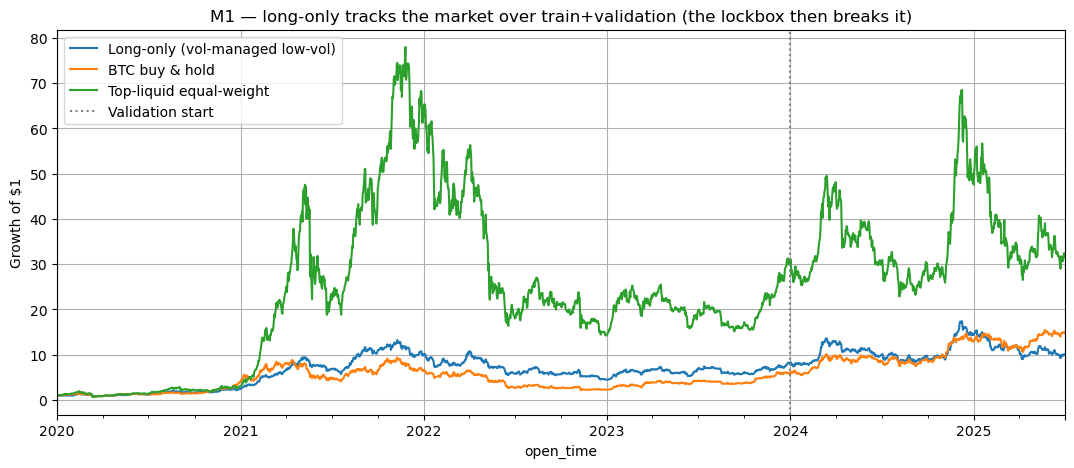

In [34]:
# Visual: the long-only book moves with the market (train+validation) -> beta, not alpha.
plt.figure(figsize=(13, 5))
for lab, r in [("Long-only (vol-managed low-vol)", final_long_only_returns),
               ("BTC buy & hold", btc_benchmark_1d),
               ("Top-liquid equal-weight", top_liquid_benchmark_1d)]:
    (1 + slice_period(r, "dev").fillna(0)).cumprod().plot(label=lab)
plt.axvline(pd.to_datetime(VALIDATION_START_DATE, utc=True), color="grey", ls=":", label="Validation start")
plt.title("M1 — long-only tracks the market over train+validation (the lockbox then breaks it)")
plt.ylabel("Growth of $1"); plt.legend(); plt.show()


# M2 · Long-Short Statistical Arbitrage  ❌

**Question.** Drop the market entirely: can a **dollar-neutral** long-short book
(long the strong, short the weak) extract cross-sectional alpha?

**Method.** The *unconstrained* course backtest — cross-sectionally demean each signal to
dollar-neutral, normalize gross to 1, lag positions, charge turnover at 20 bps. We honestly
select one **momentum**, one **reversal**, and one **defensive** sleeve on train walk-forward,
then blend them by inverse-volatility **risk parity**.

**Result.** Even the best sleeves are thin; the risk-parity ensemble is the most defensible.
As with M1, the real test is the **Lockbox**.


In [35]:
# ============================================================
# Section 17: Unconstrained Long-Short Backtest Engine
# ============================================================

def build_unconstrained_weights(signal, gross=1.0, max_weight=None):
    """
    Convert a raw signal (alpha) matrix into UNCONSTRAINED long-short weights.

    Method (the "unconstrained" backtest from the course):
      1. Cross-sectionally DEMEAN the signal each period -> dollar-neutral (sum w = 0).
      2. Normalize so gross exposure sum|w| = `gross`.
      3. Optional per-asset cap, then renormalize gross.

    Missing assets (NaN signal) get zero weight and are excluded from the
    cross-sectional mean / normalization, so stale or not-yet-listed coins never
    enter the book.
    """
    s = signal.astype(float)

    # 1. Demean across valid assets each period (NaN skipped by mean).
    s = s.sub(s.mean(axis=1), axis=0)

    # 2. Normalize to fixed gross exposure sum|w| = gross.
    denom = s.abs().sum(axis=1)
    w = s.div(denom.where(denom > 0, np.nan), axis=0) * gross
    w = w.fillna(0.0)

    # 3. Optional per-asset cap, then renormalize gross.
    if max_weight is not None:
        w = w.clip(lower=-max_weight, upper=max_weight)
        denom2 = w.abs().sum(axis=1)
        w = w.div(denom2.where(denom2 > 0, np.nan), axis=0) * gross
        w = w.fillna(0.0)

    return w


def backtest_unconstrained(signal, returns, tcost=BASE_TCOST, gross=1.0,
                           max_weight=None, lag=1):
    """
    Backtest an unconstrained long-short signal.

    No-lookahead:
        Positions are LAGGED by `lag` periods, so the return earned in period t
        uses weights decided at t-lag (information available then).

    Cost timing:
        Turnover is measured on the SAME lagged (effective) weights used for PnL,
        so a trade's cost is charged in the period whose PnL the trade enables.
        This fixes the 1-period cost/return misalignment in the Part I engine.

        net_t = (w_eff_t . r_t) - tcost * |w_eff_t - w_eff_{t-1}|
    """
    signal, returns = signal.align(returns, join="inner", axis=0)
    signal, returns = signal.align(returns, join="inner", axis=1)

    w = build_unconstrained_weights(signal, gross=gross, max_weight=max_weight)
    w_eff = w.shift(lag)                       # effective (held) positions

    gross_returns = (w_eff * returns).sum(axis=1)
    turnover = w_eff.diff().abs().sum(axis=1)
    cost = turnover * tcost
    net_returns = gross_returns - cost

    return {
        "weights": w,
        "effective_weights": w_eff,
        "gross_returns": gross_returns,
        "net_returns": net_returns,
        "turnover": turnover,
        "cost": cost,
    }


print("Unconstrained long-short engine loaded.")


Unconstrained long-short engine loaded.


Momentum signals ranked by walk-forward score (TRAIN ONLY):


,Strategy,WF Score,WF Mean Sharpe,WF Std (consistency),WF Worst Fold,Train Sharpe,Train DSR
0,MA_Crossover_20_100,0.056609,0.056609,1.206855,-1.683836,0.050433,0.047482
1,MA_Crossover_10_50,-0.069926,-0.069926,1.014269,-1.274490,0.099124,0.057969
2,MA_Crossover_5_20,-0.137106,-0.137106,1.219092,-1.455274,0.115948,0.062030
3,MA_Crossover_50_200,-0.151548,-0.151548,1.155815,-1.218332,-0.423685,0.004591
4,TS_Momentum_30D,-0.377174,-0.377174,1.590300,-2.242566,-0.042614,0.031741
5,Vol_Adjusted_Momentum_90D,-0.430676,-0.430676,1.059782,-1.768106,-0.478544,0.003223
6,Vol_Adjusted_Momentum_30D,-0.457032,-0.457032,1.686005,-2.273268,-0.022914,0.034648
7,Vol_Adjusted_Momentum_60D,-0.487799,-0.487799,0.971522,-1.747695,-0.360464,0.006426
8,Idio_Momentum_90D,-0.490133,-0.490133,1.150306,-2.187450,-0.519625,0.002560
9,TS_Momentum_180D,-0.621659,-0.621659,1.670631,-3.030409,-0.338209,0.007356



Best momentum signal (train walk-forward): MA_Crossover_20_100


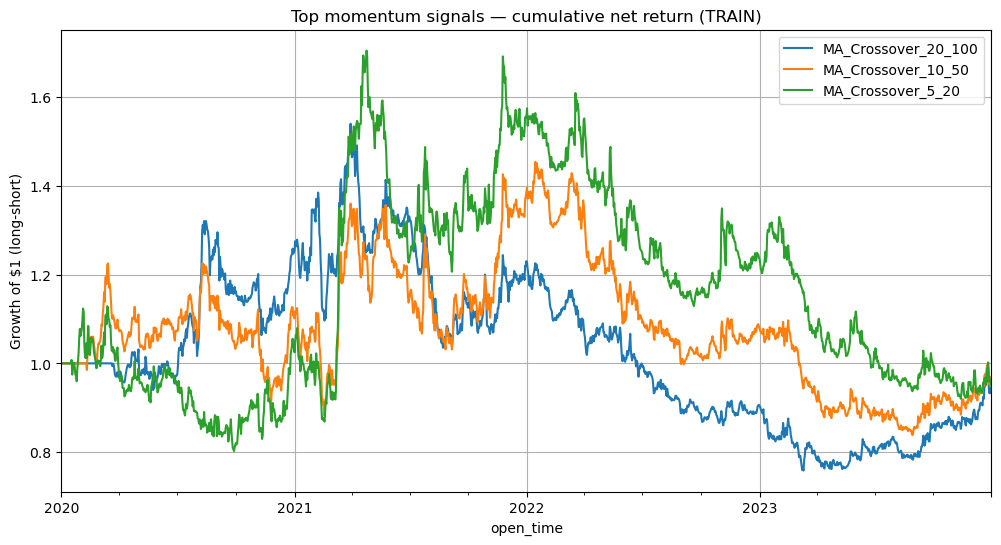

In [36]:
# ============================================================
# Section 19: Cross-Sectional Momentum Research
# ============================================================
# Guideline: "Longer time horizons generally lead to momentum. Test different
# time horizons and see where momentum might exist." We test the momentum family
# across horizons in the unconstrained long-short book and select on walk-forward.

def prepare_signal(signal, winsorize=True, zscore=True):
    """Winsorize + cross-sectional z-score a raw signal before the L/S engine,
    so a few extreme values can't dominate the gross-normalized book."""
    s = signal.copy()
    if winsorize:
        s = winsorize_dataframe(s)
    if zscore:
        s = cross_sectional_zscore(s)
    return s


def run_ls(signal, returns, tcost=BASE_TCOST, gross=1.0, max_weight=None, lag=1):
    """Prepare a signal and backtest it as an unconstrained long-short book."""
    s = prepare_signal(signal)
    return backtest_unconstrained(s, returns, tcost=tcost, gross=gross,
                                  max_weight=max_weight, lag=lag)


# The momentum family: time-series momentum, vol-adjusted momentum, MA trend.
momentum_signal_names = (
    [k for k in daily_signals if k.startswith("TS_Momentum")]
    + [k for k in daily_signals if k.startswith("Vol_Adjusted_Momentum")]
    + [k for k in daily_signals if k.startswith("MA_Crossover")]
    + [k for k in daily_signals if k.startswith("Idio_Momentum")]
)

momentum_ls_results = {
    name: run_ls(daily_signals[name], returns_1d, tcost=BASE_TCOST)
    for name in momentum_signal_names
}
momentum_candidates = {n: r["net_returns"] for n, r in momentum_ls_results.items()}

momentum_ranked = select_best_on_train(
    momentum_candidates, periods_per_year=BARS_PER_YEAR_1D, n_folds=4
)

print("Momentum signals ranked by walk-forward score (TRAIN ONLY):")
display(momentum_ranked)

# Best momentum signal (honestly selected on train).
best_momentum_name = momentum_ranked.iloc[0]["Strategy"]
print(f"\nBest momentum signal (train walk-forward): {best_momentum_name}")

# Visualize the train-period cumulative net return of the top 3 momentum signals.
plt.figure()
for name in momentum_ranked["Strategy"].head(3):
    r = momentum_candidates[name]
    r_train = r[r.index <= pd.to_datetime(TRAIN_END_DATE, utc=True)].fillna(0)
    (1 + r_train).cumprod().plot(label=name)
plt.title("Top momentum signals — cumulative net return (TRAIN)")
plt.ylabel("Growth of $1 (long-short)")
plt.legend()
plt.show()


In [37]:
# ============================================================
# Section 20: Cross-Sectional Reversal Research
# ============================================================
# Guideline: "Shorter time horizons generally lead to reversal. Test different
# time horizons." Crypto is dominated by retail flow, so short-horizon
# cross-sectional reversal is a prime candidate. We test the reversal family in
# the unconstrained book and select on walk-forward.

reversal_signal_names = (
    [k for k in daily_signals if k.startswith("Reversal")]
    + [k for k in daily_signals if k.startswith("Idio_Reversal")]
)

reversal_ls_results = {
    name: run_ls(daily_signals[name], returns_1d, tcost=BASE_TCOST)
    for name in reversal_signal_names
}
reversal_candidates = {n: r["net_returns"] for n, r in reversal_ls_results.items()}

reversal_ranked = select_best_on_train(
    reversal_candidates, periods_per_year=BARS_PER_YEAR_1D, n_folds=4
)

print("Reversal signals ranked by walk-forward score (TRAIN ONLY):")
display(reversal_ranked)

best_reversal_name = reversal_ranked.iloc[0]["Strategy"]
print(f"\nBest reversal signal (train walk-forward): {best_reversal_name}")

# Turnover matters most for reversal (it is high-frequency). Show gross vs net
# Sharpe and average turnover for each reversal horizon on the train period.
rows = []
for name in reversal_signal_names:
    res = reversal_ls_results[name]
    g_train = res["gross_returns"][res["gross_returns"].index <= pd.to_datetime(TRAIN_END_DATE, utc=True)]
    n_train = res["net_returns"][res["net_returns"].index <= pd.to_datetime(TRAIN_END_DATE, utc=True)]
    rows.append({
        "Signal": name,
        "Gross Sharpe (train)": _wf_sharpe(g_train, BARS_PER_YEAR_1D),
        "Net Sharpe (train)": _wf_sharpe(n_train, BARS_PER_YEAR_1D),
        "Avg Daily Turnover": res["turnover"].mean(),
    })
reversal_cost_table = pd.DataFrame(rows).sort_values("Net Sharpe (train)", ascending=False)
print("\nReversal: gross vs net (cost sensitivity) on TRAIN:")
display(reversal_cost_table)


Reversal signals ranked by walk-forward score (TRAIN ONLY):


,Strategy,WF Score,WF Mean Sharpe,WF Std (consistency),WF Worst Fold,Train Sharpe,Train DSR
0,Idio_Reversal_14D,-0.835662,-0.835662,1.032039,-2.364312,-1.011140,0.000251
1,Reversal_14D,-0.960556,-0.960556,0.824654,-2.063092,-1.108074,0.000110
2,Idio_Reversal_3D,-1.449611,-1.449611,1.219950,-2.472902,-1.607567,0.000001
3,Reversal_7D,-1.522381,-1.522381,1.019236,-2.673720,-1.762475,0.000000
4,Reversal_3D,-1.554423,-1.554423,1.260476,-2.375683,-1.766461,0.000000
5,Idio_Reversal_7D,-1.633552,-1.633552,1.092346,-3.083970,-1.839545,0.000000
6,Reversal_1D,-3.015883,-3.015883,1.101646,-4.664911,-2.717746,0.000000



Best reversal signal (train walk-forward): Idio_Reversal_14D

Reversal: gross vs net (cost sensitivity) on TRAIN:


,Signal,Gross Sharpe (train),Net Sharpe (train),Avg Daily Turnover
6,Idio_Reversal_14D,-0.172074,-1.011140,0.365534
3,Reversal_14D,-0.343973,-1.108074,0.380519
4,Idio_Reversal_3D,0.156280,-1.607567,0.802150
2,Reversal_7D,-0.704766,-1.762475,0.540474
1,Reversal_3D,-0.091960,-1.766461,0.824091
5,Idio_Reversal_7D,-0.699313,-1.839545,0.521780
0,Reversal_1D,0.191613,-2.717746,1.423560


In [38]:
# ============================================================
# Section 23: Combining Sleeves (decorrelated risk-parity ensemble)
# ============================================================
# Guideline: "you may find 1 momentum strategy and 1 reversal strategy ...
# combine them appropriately." We go further and build a decorrelated ENSEMBLE
# of three honestly-selected sleeves -- momentum, short-horizon reversal, and a
# defensive (low-beta / low-vol) book -- weighted by inverse train-volatility
# (risk parity). Diversifying across weakly-correlated sleeves is the most
# reliable way to lift a Sharpe when any single edge is thin (recall the
# universe offers only a few effective independent bets).

mom_sig = prepare_signal(daily_signals[best_momentum_name])
rev_sig = prepare_signal(daily_signals[best_reversal_name])

# Defensive sleeve: low-beta / low-volatility as a dollar-neutral long-short book.
defensive_signal_names = (
    [k for k in daily_signals if k.startswith("Low_Beta")]
    + [k for k in daily_signals if k.startswith("Low_Volatility")]
)
defensive_ls_results = {
    name: run_ls(daily_signals[name], returns_1d, tcost=BASE_TCOST)
    for name in defensive_signal_names
}
defensive_candidates = {n: r["net_returns"] for n, r in defensive_ls_results.items()}
defensive_ranked = select_best_on_train(
    defensive_candidates, periods_per_year=BARS_PER_YEAR_1D, n_folds=4
)
best_defensive_name = defensive_ranked.iloc[0]["Strategy"]
print("Defensive sleeve candidates (TRAIN walk-forward):")
display(defensive_ranked)
print(f"Best defensive signal (train walk-forward): {best_defensive_name}\n")
def_sig = prepare_signal(daily_signals[best_defensive_name])

mom_net = momentum_candidates[best_momentum_name]
rev_net = reversal_candidates[best_reversal_name]
def_net = defensive_candidates[best_defensive_name]

# Inverse-volatility (risk-parity) weights estimated on TRAIN ONLY.
def _train_vol(r):
    rt = r[r.index <= pd.to_datetime(TRAIN_END_DATE, utc=True)].dropna()
    return rt.std()

sleeve_sig = {"momentum": mom_sig, "reversal": rev_sig, "defensive": def_sig}
sleeve_net = {"momentum": mom_net, "reversal": rev_net, "defensive": def_net}
inv_vol = {k: 1.0 / _train_vol(v) for k, v in sleeve_net.items()}
rp_w = {k: inv_vol[k] / sum(inv_vol.values()) for k in inv_vol}
print("Risk-parity sleeve weights (inverse train-vol): "
      + ", ".join(f"{k}={rp_w[k]:.2f}" for k in rp_w))

# Blend at the signal level into single dollar-neutral books.
combined_signal = sum(rp_w[k] * sleeve_sig[k] for k in sleeve_sig)
ew_signal = sum((1.0 / 3.0) * sleeve_sig[k] for k in sleeve_sig)
combined_result = backtest_unconstrained(combined_signal, returns_1d, tcost=BASE_TCOST)
combined_net = combined_result["net_returns"]
ew_net = backtest_unconstrained(ew_signal, returns_1d, tcost=BASE_TCOST)["net_returns"]

mom_label = f"Momentum_only ({best_momentum_name})"
rev_label = f"Reversal_only ({best_reversal_name})"
def_label = f"Defensive_only ({best_defensive_name})"

combine_candidates = {
    mom_label: mom_net,
    rev_label: rev_net,
    def_label: def_net,
    "Ensemble_RiskParity": combined_net,
    "Ensemble_EqualWeight": ew_net,
}
# Signal matrix behind each candidate, so the final report can rebuild any of them
# at different cost assumptions without an if/elif chain.
final_signal_map = {
    mom_label: mom_sig,
    rev_label: rev_sig,
    def_label: def_sig,
    "Ensemble_RiskParity": combined_signal,
    "Ensemble_EqualWeight": ew_signal,
}

combine_ranked = select_best_on_train(
    combine_candidates, periods_per_year=BARS_PER_YEAR_1D, n_folds=4
)
print("\nSleeves and ensembles ranked (TRAIN walk-forward):")
display(combine_ranked)

# Diversification check: correlation of the three sleeves on TRAIN.
sleeve_corr = pd.concat(
    [mom_net.rename("momentum"), rev_net.rename("reversal"), def_net.rename("defensive")],
    axis=1
).loc[lambda d: d.index <= pd.to_datetime(TRAIN_END_DATE, utc=True)].corr()
print("\nTrain correlation across sleeves:")
display(sleeve_corr)

# The honestly-selected final strategy.
final_strategy_name = combine_ranked.iloc[0]["Strategy"]
final_strategy_net = combine_candidates[final_strategy_name]
print(f"\nFinal selected strategy (train walk-forward): {final_strategy_name}")


Defensive sleeve candidates (TRAIN walk-forward):


,Strategy,WF Score,WF Mean Sharpe,WF Std (consistency),WF Worst Fold,Train Sharpe,Train DSR
0,Low_Volatility_60D,-0.445568,-0.445568,0.966510,-1.228096,-0.621862,0.007015
1,Low_Beta_60D,-0.679606,-0.679606,0.725051,-1.666612,-0.847123,0.001920
2,Low_Volatility_14D,-0.726388,-0.726388,0.810807,-1.378296,-0.828711,0.001946
3,Low_Volatility_30D,-0.859810,-0.859810,1.044057,-1.815613,-1.062563,0.000357
4,Low_Beta_30D,-1.296943,-1.296943,0.480377,-1.958178,-1.379446,0.000037


Best defensive signal (train walk-forward): Low_Volatility_60D



Risk-parity sleeve weights (inverse train-vol): momentum=0.38, reversal=0.29, defensive=0.33

Sleeves and ensembles ranked (TRAIN walk-forward):


,Strategy,WF Score,WF Mean Sharpe,WF Std (consistency),WF Worst Fold,Train Sharpe,Train DSR
0,Momentum_only (MA_Crossover_20_100),0.056609,0.056609,1.206855,-1.683836,0.050433,0.137485
1,Defensive_only (Low_Volatility_60D),-0.445568,-0.445568,0.966510,-1.228096,-0.621862,0.007015
2,Ensemble_RiskParity,-0.478118,-0.478118,1.256790,-2.309230,-0.777188,0.002665
3,Ensemble_EqualWeight,-0.537576,-0.537576,1.244584,-2.376108,-0.837432,0.001774
4,Reversal_only (Idio_Reversal_14D),-0.835662,-0.835662,1.032039,-2.364312,-1.011140,0.000509



Train correlation across sleeves:


,momentum,reversal,defensive
momentum,1.000000,-0.367093,-0.522041
reversal,-0.367093,1.000000,0.431577
defensive,-0.522041,0.431577,1.000000



Final selected strategy (train walk-forward): Momentum_only (MA_Crossover_20_100)


# 🔒 Lockbox Test — the verdict on M1 & M2

We now open the test set **exactly once**. Both return-prediction books are rebuilt on full
history with their development-fixed recipes and scored on train / validation / **test**.


LONG-ONLY final book: Low_Volatility_14D_Top10_30D_VolTarget50_Lookback14
LOCKBOX OPENED (access #1): long-only final book


,Train,Validation,Test (lockbox)
Annualized Return,0.697158,0.154724,-0.431007
Annualized Volatility,0.526948,0.507253,0.499590
Sharpe,1.323011,0.305023,-0.862721
Max Drawdown,-0.663007,-0.480602,-0.598937
PSR,0.993053,0.744424,0.192747
DSR (deflated),0.640620,0.074535,0.001500
Alpha Annualized,0.291029,-0.305854,-0.151040
Beta,0.600760,0.770713,0.912459
Alpha t-stat,1.594021,-1.028492,-0.497243



LONG-SHORT final book: Momentum_only (MA_Crossover_20_100)
LOCKBOX OPENED (access #2): long-short final book


,Train,Validation,Test (lockbox)
Annualized Return,-0.016906,-0.186935,0.124728
Annualized Volatility,0.242255,0.185465,0.257485
Sharpe,-0.069788,-1.007922,0.484408
Max Drawdown,-0.507337,-0.299803,-0.176115
PSR,0.540187,0.102245,0.713310
DSR (deflated),0.022806,0.000378,0.062173
Alpha Annualized,0.006466,-0.185989,0.113536
Beta,0.008488,-0.004865,-0.119409
Alpha t-stat,0.050541,-1.381168,0.369518



RESEARCH DISCIPLINE SUMMARY
Configurations evaluated (N_TRIALS)        : 32
Validation peeks logged                    : 0
Lockbox (test set) openings                : 2
DSR deflates each Sharpe by 32 trials.

Honest takeaway:
  Long-only  test Sharpe = -0.86, DSR = 0.00, alpha vs BTC = -15.10%
  Long-short test Sharpe = 0.48, DSR = 0.06


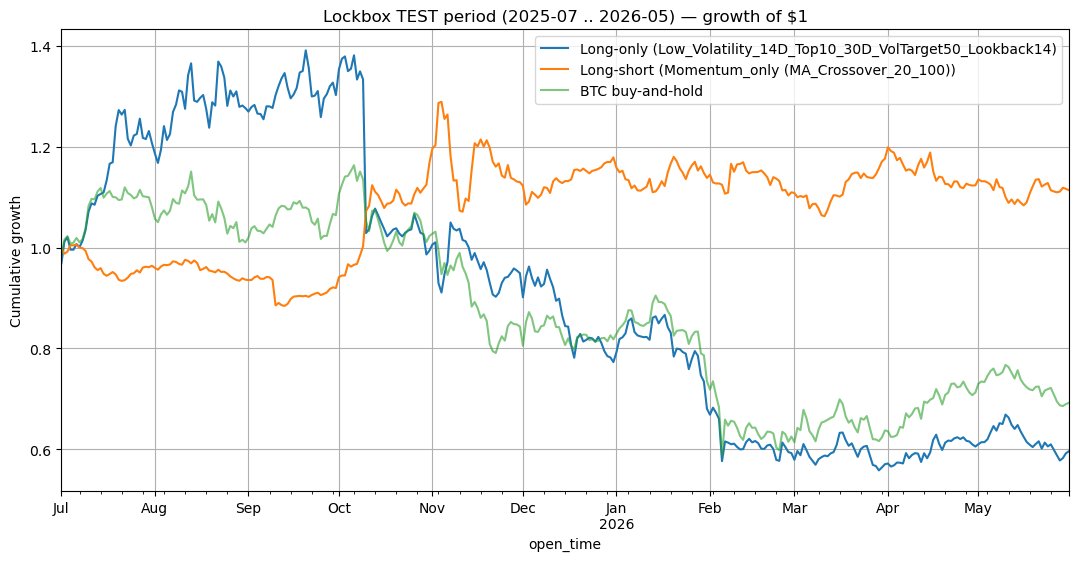

In [39]:
# ============================================================
# Section 25: Lockbox Test (opened exactly once)
# ============================================================
# Rebuild the candidate signal library on FULL history, then reconstruct the two
# honestly-selected books with their development-fixed recipes and evaluate them
# on train / validation / test. Test access goes through LOCKBOX so it is logged.

full_signals = create_signal_library(
    close=full_frames["close_1d"],
    high=full_frames["high_1d"],
    low=full_frames["low_1d"],
    volume=full_frames["volume_1d"],
    quote_volume=full_frames["quote_volume_1d"],
    taker_buy_base_volume=full_frames["taker_buy_base_volume_1d"],
)
full_returns_1d = full_frames["returns_1d"]
full_btc = (full_returns_1d["BTCUSDT"]
            if "BTCUSDT" in full_returns_1d.columns else None)

# ---- Reconstruct the final LONG-SHORT book on full history --------------------
sleeve_best = {"momentum": best_momentum_name,
               "reversal": best_reversal_name,
               "defensive": best_defensive_name}

def reconstruct_ls_signal(sigs):
    if final_strategy_name == mom_label:
        return prepare_signal(sigs[best_momentum_name])
    if final_strategy_name == rev_label:
        return prepare_signal(sigs[best_reversal_name])
    if final_strategy_name == def_label:
        return prepare_signal(sigs[best_defensive_name])
    if final_strategy_name == "Ensemble_RiskParity":
        return sum(rp_w[k] * prepare_signal(sigs[sleeve_best[k]]) for k in rp_w)
    if final_strategy_name == "Ensemble_EqualWeight":
        return sum((1.0 / 3.0) * prepare_signal(sigs[sleeve_best[k]]) for k in sleeve_best)
    raise KeyError(final_strategy_name)

full_ls_net = backtest_unconstrained(
    reconstruct_ls_signal(full_signals), full_returns_1d, tcost=BASE_TCOST
)["net_returns"]

# ---- Reconstruct the final LONG-ONLY book on full history ---------------------
import re as _re
_base_sig_name, _rest = BASE_LONG_ONLY_STRATEGY_ID.split("_Top")
_top_n = int(_rest.split("_")[0])
_rebal = _rest.split("_")[1]
_m = _re.search(r"VolTarget(\d+)_Lookback(\d+)", best_vt_strategy_name)
_target_vol, _lookback = int(_m.group(1)) / 100.0, int(_m.group(2))

_lo_base_net = backtest_long_only_signal_strategy(
    signal=full_signals[_base_sig_name], returns=full_returns_1d,
    strategy_name=BASE_LONG_ONLY_STRATEGY_ID, top_n=_top_n, rebalance_frequency=_rebal,
)["net_returns"]
full_lo_net = apply_volatility_targeting(
    returns=_lo_base_net, target_vol=_target_vol, lookback_window=_lookback,
    periods_per_year=BARS_PER_YEAR_1D, max_exposure=1.00, min_exposure=0.00,
)["vol_targeted_returns"]

# ---- Evaluate each book across train / validation / test ----------------------
_n_trials = max(2, N_TRIALS.count)

def _eval3(net, label):
    train = slice_period(net, "train")
    val = slice_period(net, "validation")
    test = LOCKBOX.slice(net, f"{label} final book")          # the one logged test access
    cols = {}
    for nm, seg in [("Train", train), ("Validation", val), ("Test (lockbox)", test)]:
        bench = full_btc.reindex(seg.index) if full_btc is not None else None
        m = calculate_performance_metrics(seg, BARS_PER_YEAR_1D, benchmark_returns=bench)
        m["DSR (deflated)"] = deflated_sharpe_ratio(seg, n_trials=_n_trials)
        cols[nm] = m
    return pd.DataFrame(cols)

print(f"LONG-ONLY final book: {best_vt_strategy_name}")
lo_report = _eval3(full_lo_net, "long-only")
display(lo_report.loc[["Annualized Return", "Annualized Volatility", "Sharpe",
                       "Max Drawdown", "PSR", "DSR (deflated)",
                       "Alpha Annualized", "Beta", "Alpha t-stat"]])

print(f"\nLONG-SHORT final book: {final_strategy_name}")
ls_report = _eval3(full_ls_net, "long-short")
display(ls_report.loc[["Annualized Return", "Annualized Volatility", "Sharpe",
                       "Max Drawdown", "PSR", "DSR (deflated)",
                       "Alpha Annualized", "Beta", "Alpha t-stat"]])

# ---- Research-discipline summary ---------------------------------------------
print("\n" + "=" * 64)
print("RESEARCH DISCIPLINE SUMMARY")
print("=" * 64)
print(f"Configurations evaluated (N_TRIALS)        : {N_TRIALS.count}")
print(f"Validation peeks logged                    : {VALIDATION_PEEKS.count}")
print(f"Lockbox (test set) openings                : {LOCKBOX.opened}")
print(f"DSR deflates each Sharpe by {_n_trials} trials.")
print("\nHonest takeaway:")
print(f"  Long-only  test Sharpe = {lo_report.loc['Sharpe','Test (lockbox)']:.2f}, "
      f"DSR = {lo_report.loc['DSR (deflated)','Test (lockbox)']:.2f}, "
      f"alpha vs BTC = {lo_report.loc['Alpha Annualized','Test (lockbox)']:.2%}")
print(f"  Long-short test Sharpe = {ls_report.loc['Sharpe','Test (lockbox)']:.2f}, "
      f"DSR = {ls_report.loc['DSR (deflated)','Test (lockbox)']:.2f}")

# ---- Test-period cumulative curves -------------------------------------------
plt.figure(figsize=(13, 6))
_lo_test = slice_period(full_lo_net, "test").fillna(0)
_ls_test = slice_period(full_ls_net, "test").fillna(0)
(1 + _lo_test).cumprod().plot(label=f"Long-only ({best_vt_strategy_name})")
(1 + _ls_test).cumprod().plot(label=f"Long-short ({final_strategy_name})")
if full_btc is not None:
    (1 + slice_period(full_btc, "test").reindex(_lo_test.index).fillna(0)).cumprod().plot(
        label="BTC buy-and-hold", alpha=0.6)
plt.title("Lockbox TEST period (2025-07 .. 2026-05) — growth of $1")
plt.ylabel("Cumulative growth"); plt.legend(); plt.show()


> ### Verdict on M1 & M2 ❌
> The validation ranking **reverses** out of sample. The long-only book's strong train/val
> Sharpe (1.32 / 0.31) collapses to **−0.86** in the lockbox; the long-short book's deflated
> Sharpe is **~0**. With only **~2–4 effective independent bets** in one-and-a-half cycles,
> the in-sample results were **regime luck**, not skill — exactly what the discipline is
> built to catch.
>
> **Why was the long-only Sharpe "good" in validation but terrible in the lockbox?** Because
> it was **market beta, not alpha** — confirmed directly below: hedging out the market
> collapses the book's Sharpe toward zero, and what little residual remains is regime-unstable.


In [40]:
# ============================================================
# Section 27: Beta-Neutral Market-Hedged Low-Vol Book
# ============================================================
# Long basket = the base low-vol long-only book on FULL history; hedge = short a
# rolling (lagged) beta times the equal-weight market index.

lv_long = backtest_long_only_signal_strategy(
    signal=full_signals["Low_Volatility_14D"], returns=full_returns_1d,
    strategy_name="LowVol_Long", top_n=10, rebalance_frequency="30D",
)["net_returns"]

market_ret = full_frames["returns_1d"].mean(axis=1)            # equal-weight market

def rolling_beta_1d(asset_ret, mkt_ret, window=90):
    mp = int(window * 0.8)
    cov = ((asset_ret * mkt_ret).rolling(window, min_periods=mp).mean()
           - asset_ret.rolling(window, min_periods=mp).mean()
           * mkt_ret.rolling(window, min_periods=mp).mean())
    var = mkt_ret.rolling(window, min_periods=mp).var()
    return (cov / var.replace(0, np.nan)).shift(1)             # lagged: no lookahead

hedge_beta = rolling_beta_1d(lv_long, market_ret, window=90)
hedge_turnover = hedge_beta.diff().abs().fillna(0.0)
lv_hedged = lv_long - hedge_beta * market_ret - hedge_turnover * BASE_TCOST

def realized_beta(seg_ret, seg_mkt):
    a, m = seg_ret.align(seg_mkt, join="inner")
    d = pd.concat([a, m], axis=1).dropna()
    if len(d) < 10 or d.iloc[:, 1].var() == 0:
        return np.nan
    return d.iloc[:, 0].cov(d.iloc[:, 1]) / d.iloc[:, 1].var()

print("LONG-ONLY low-vol book (unhedged):")
display(periods_table(lv_long))
print("BETA-NEUTRAL low-vol book (market hedged out):")
display(periods_table(lv_hedged))

print("\nRealized beta to market by period (hedge should drive it ~0):")
beta_rows = {}
for nm in ["train", "validation", "test"]:
    m_seg = slice_period(market_ret, nm)
    beta_rows[nm.capitalize()] = {
        "Unhedged beta": realized_beta(slice_period(lv_long, nm), m_seg),
        "Hedged beta": realized_beta(slice_period(lv_hedged, nm), m_seg),
    }
display(pd.DataFrame(beta_rows).T)

print("\nReading: if the unhedged book's train/validation Sharpe was real alpha, the\n"
      "hedged book stays positive across regimes; if it was beta, the hedged book\n"
      "collapses toward zero -- the direct test of the long-only overfitting question.")


LONG-ONLY low-vol book (unhedged):


,Sharpe,Ann. Return,Max Drawdown,DSR (deflated)
Train,1.177230,0.967616,-0.783955,0.625321
Validation,0.354198,0.219193,-0.583628,0.091770
Test,-0.872503,-0.471439,-0.621033,0.001402


BETA-NEUTRAL low-vol book (market hedged out):


,Sharpe,Ann. Return,Max Drawdown,DSR (deflated)
Train,0.298779,0.089829,-0.295566,0.107567
Validation,2.049341,0.463183,-0.109361,0.593329
Test,-0.950660,-0.167652,-0.303060,0.001220



Realized beta to market by period (hedge should drive it ~0):


,Unhedged beta,Hedged beta
Train,0.820913,0.005841
Validation,0.728135,0.005076
Test,0.747548,0.044892



Reading: if the unhedged book's train/validation Sharpe was real alpha, the
hedged book stays positive across regimes; if it was beta, the hedged book
collapses toward zero -- the direct test of the long-only overfitting question.


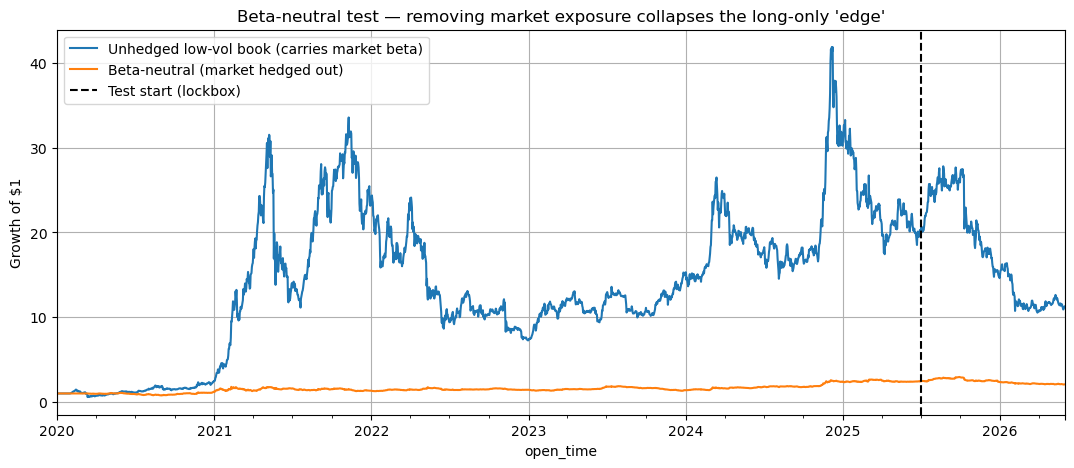

In [41]:
# Visual: hedging out the market collapses the low-vol "edge" -> it was beta.
plt.figure(figsize=(13, 5))
(1 + slice_period(lv_long, "all").fillna(0)).cumprod().plot(label="Unhedged low-vol book (carries market beta)")
(1 + slice_period(lv_hedged, "all").fillna(0)).cumprod().plot(label="Beta-neutral (market hedged out)")
plt.axvline(pd.to_datetime(TEST_START_DATE, utc=True), color="k", ls="--", label="Test start (lockbox)")
plt.title("Beta-neutral test — removing market exposure collapses the long-only 'edge'")
plt.ylabel("Growth of $1"); plt.legend(); plt.show()


### M2 rigor — multi-factor (PCA) neutralization
The library's idiosyncratic signals hedge a *single* rolling market beta. A more rigorous
neutralization removes the **top-3 statistical (PCA) factors** estimated on train (loadings
fixed → no look-ahead), leaving true residuals to trade reversal on.

In [42]:
# Residual reversal: single market-beta vs a 3-factor PCA statistical model.
resid_returns = pca_factor_residuals(returns_1d, k=3, train_end=pd.to_datetime(TRAIN_END_DATE, utc=True))
pca_rev_net = backtest_unconstrained(
    prepare_signal(-resid_returns.rolling(5, min_periods=3).sum()), returns_1d, tcost=BASE_TCOST)["net_returns"]
beta_rev_net = run_ls(daily_signals["Idio_Reversal_3D"], returns_1d, tcost=BASE_TCOST)["net_returns"]
N_TRIALS.touch("pca_factor_reversal")
print(f"3-factor PCA model removes {1 - resid_returns.var().sum()/returns_1d.var().sum():.0%} "
      "of cross-sectional variance (the systematic part).")
print("\nSingle market-beta residual reversal (Idio_Reversal_3D), development window:")
display(periods_table(beta_rev_net).drop("Test"))
print("3-factor PCA residual reversal (more rigorous neutralization), development window:")
display(periods_table(pca_rev_net).drop("Test"))
print("Reading: cleaner neutralization, but the residual edge stays thin after costs — "
      "consistent with M1/M2. Rigor sharpens the measurement; it doesn't conjure alpha.")


3-factor PCA model removes 51% of cross-sectional variance (the systematic part).

Single market-beta residual reversal (Idio_Reversal_3D), development window:


,Sharpe,Ann. Return,Max Drawdown,DSR (deflated)
Train,-1.347950,-0.439381,-0.916013,0.000000
Validation,-1.183746,-0.249068,-0.407337,0.000129


3-factor PCA residual reversal (more rigorous neutralization), development window:


,Sharpe,Ann. Return,Max Drawdown,DSR (deflated)
Train,-1.364807,-0.463107,-0.920474,0.000000
Validation,-1.155016,-0.233916,-0.361632,0.000152


Reading: cleaner neutralization, but the residual edge stays thin after costs — consistent with M1/M2. Rigor sharpens the measurement; it doesn't conjure alpha.


# M3 · Vol-Managed Trend  ✅

**Question.** If *return prediction* fails, does **risk management** survive? I.e. can a
simple trend overlay plus volatility targeting improve risk-adjusted return without
pretending to forecast direction?

**Method.** No selection of a "best" lookback (that overfits). Instead an **ensemble** of
8 trend rules (time-series-momentum and moving-average, lookbacks 30/60/100/200) gives a
continuous 0–1 exposure, then **volatility targeting** scales it toward a fixed 50% vol.
Applied to BTC and the equal-weight index.

**Result.** This is the first thing that holds up — not as a return edge but as
**drawdown control**.


Trend / market-timing candidates ranked (TRAIN walk-forward):


,Strategy,WF Score,WF Mean Sharpe,WF Std (consistency),WF Worst Fold,Train Sharpe,Train DSR
0,MA_EWIndex_30D,1.555698,1.555698,1.612978,-0.497604,2.009333,0.980507
1,TSMOM_EWIndex_30D,1.519479,1.519479,1.546347,-0.681715,1.878835,0.952233
2,MA_BTC_200D,1.392459,1.392459,1.703188,-0.467048,1.056395,0.629259
3,TSMOM_BTC_30D,1.123431,1.123431,2.001913,-1.669218,1.521344,0.900790
4,TSMOM_EWIndex_100D,0.985951,0.985951,0.599562,0.361170,1.155384,0.669220
5,TSMOM_BTC_200D,0.944947,0.944947,1.717379,-0.683096,0.876769,0.486373
6,MA_EWIndex_60D,0.903960,0.903960,1.578843,-1.241708,1.471363,0.831008
7,MA_EWIndex_100D,0.843362,0.843362,1.947193,-1.977363,1.449054,0.823202
8,MA_BTC_60D,0.826383,0.826383,2.218532,-2.390898,1.315300,0.807798
9,MA_BTC_100D,0.805590,0.805590,1.673749,-1.487831,1.298602,0.798967



Best timing rule (train walk-forward): MA_EWIndex_30D

TIMER  MA_EWIndex_30D (long/flat, costs included):


,Sharpe,Ann. Return,Max Drawdown,DSR (deflated)
Train,2.962945,1.774726,-0.465686,0.944783
Validation,-0.298685,-0.158261,-0.600518,0.009708
Test,-1.379646,-0.594029,-0.685120,0.000005


BUY-AND-HOLD of the same underlying:


,Sharpe,Ann. Return,Max Drawdown,DSR (deflated)
Train,1.102143,1.026047,-0.845382,0.548952
Validation,-0.314669,-0.249893,-0.693689,0.013192
Test,-0.747133,-0.512952,-0.657339,0.001628


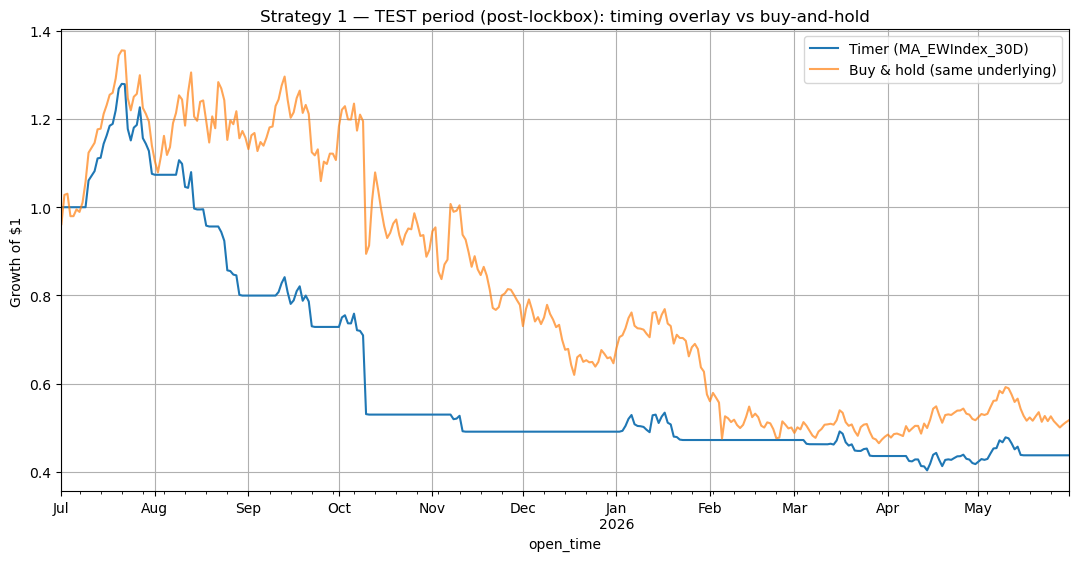


[discipline] N_TRIALS now 49; timing selected on TRAIN only; test column is a post-lockbox contaminated check, deflated by 49 trials.


In [43]:
# ============================================================
# Section 26: Trend / Market-Timing Overlay (long / flat)
# ============================================================
# Underlyings on FULL history (signals use only past data, so slicing any period
# is leak-free). Timing decisions are selected on the training period only.

mkt_ew = full_frames["returns_1d"].mean(axis=1)                       # equal-weight index
underlyings = {"EWIndex": mkt_ew}
if "BTCUSDT" in full_frames["returns_1d"].columns:
    underlyings["BTC"] = full_frames["returns_1d"]["BTCUSDT"]

def _price(idx_ret):
    return (1 + idx_ret.fillna(0)).cumprod()

def trend_tsmom(idx_ret, lookback):
    """Long if the trailing `lookback`-day index return is positive, else flat."""
    return (_price(idx_ret).pct_change(lookback) > 0).astype(float)

def trend_ma(idx_ret, lookback):
    """Long if index price is above its `lookback`-day moving average, else flat."""
    price = _price(idx_ret)
    ma = price.rolling(lookback, min_periods=int(lookback * 0.8)).mean()
    return (price > ma).astype(float)

def backtest_timing(idx_ret, position, tcost=BASE_TCOST):
    """Long/flat timing P&L. Position is shifted one bar (decide today, trade next)."""
    pos = position.shift(1).fillna(0.0)
    turnover = pos.diff().abs().fillna(0.0)
    return pos * idx_ret.fillna(0.0) - turnover * tcost

timing_candidates, timing_underlying = {}, {}
for uname, ur in underlyings.items():
    for lb in [30, 60, 100, 200]:
        timing_candidates[f"TSMOM_{uname}_{lb}D"] = backtest_timing(ur, trend_tsmom(ur, lb))
        timing_candidates[f"MA_{uname}_{lb}D"] = backtest_timing(ur, trend_ma(ur, lb))
        timing_underlying[f"TSMOM_{uname}_{lb}D"] = ur
        timing_underlying[f"MA_{uname}_{lb}D"] = ur

timing_ranked = select_best_on_train(timing_candidates, periods_per_year=BARS_PER_YEAR_1D, n_folds=4)
print("Trend / market-timing candidates ranked (TRAIN walk-forward):")
display(timing_ranked)

best_timing = timing_ranked.iloc[0]["Strategy"]
print(f"\nBest timing rule (train walk-forward): {best_timing}")

timer_net = timing_candidates[best_timing]
bh_net = timing_underlying[best_timing]            # buy-and-hold of the same underlying
_n_tr = max(2, N_TRIALS.count)

def periods_table(net):
    rows = {}
    for nm in ["train", "validation", "test"]:
        seg = slice_period(net, nm)
        m = calculate_performance_metrics(seg, BARS_PER_YEAR_1D)
        rows[nm.capitalize()] = {
            "Sharpe": m.get("Sharpe", np.nan),
            "Ann. Return": m.get("Annualized Return", np.nan),
            "Max Drawdown": m.get("Max Drawdown", np.nan),
            "DSR (deflated)": deflated_sharpe_ratio(seg, n_trials=_n_tr),
        }
    return pd.DataFrame(rows).T

print(f"\nTIMER  {best_timing} (long/flat, costs included):")
display(periods_table(timer_net))
print("BUY-AND-HOLD of the same underlying:")
display(periods_table(bh_net))

# Test-period cumulative: did the timer step aside before the drawdown?
plt.figure(figsize=(13, 6))
_t_timer = slice_period(timer_net, "test").fillna(0)
_t_bh = slice_period(bh_net, "test").fillna(0)
(1 + _t_timer).cumprod().plot(label=f"Timer ({best_timing})")
(1 + _t_bh).cumprod().plot(label="Buy & hold (same underlying)", alpha=0.7)
plt.title("Strategy 1 — TEST period (post-lockbox): timing overlay vs buy-and-hold")
plt.ylabel("Growth of $1"); plt.legend(); plt.show()

print(f"\n[discipline] N_TRIALS now {N_TRIALS.count}; timing selected on TRAIN only; "
      f"test column is a post-lockbox contaminated check, deflated by {_n_tr} trials.")



Ensemble_EWIndex  (average of 8 trend rules; continuous exposure):


,Sharpe,Ann. Return,Max Drawdown,DSR (deflated)
Train,1.859781,1.086285,-0.572485,0.750842
Validation,-0.141089,-0.071178,-0.514865,0.016391
Test,-1.358283,-0.461121,-0.514659,0.000010


  vs buy-and-hold of the same underlying:


,Sharpe,Ann. Return,Max Drawdown,DSR (deflated)
Train,1.102143,1.026047,-0.845382,0.548952
Validation,-0.314669,-0.249893,-0.693689,0.013192
Test,-0.747133,-0.512952,-0.657339,0.001628



Ensemble_BTC  (average of 8 trend rules; continuous exposure):


,Sharpe,Ann. Return,Max Drawdown,DSR (deflated)
Train,1.383292,0.570734,-0.507590,0.646241
Validation,1.111050,0.418091,-0.315130,0.188431
Test,-0.672330,-0.122863,-0.231890,0.002017


  vs buy-and-hold of the same underlying:


,Sharpe,Ann. Return,Max Drawdown,DSR (deflated)
Train,0.821882,0.556672,-0.766293,0.377114
Validation,1.683930,0.859731,-0.280953,0.327638
Test,-0.773601,-0.330392,-0.495343,0.001520


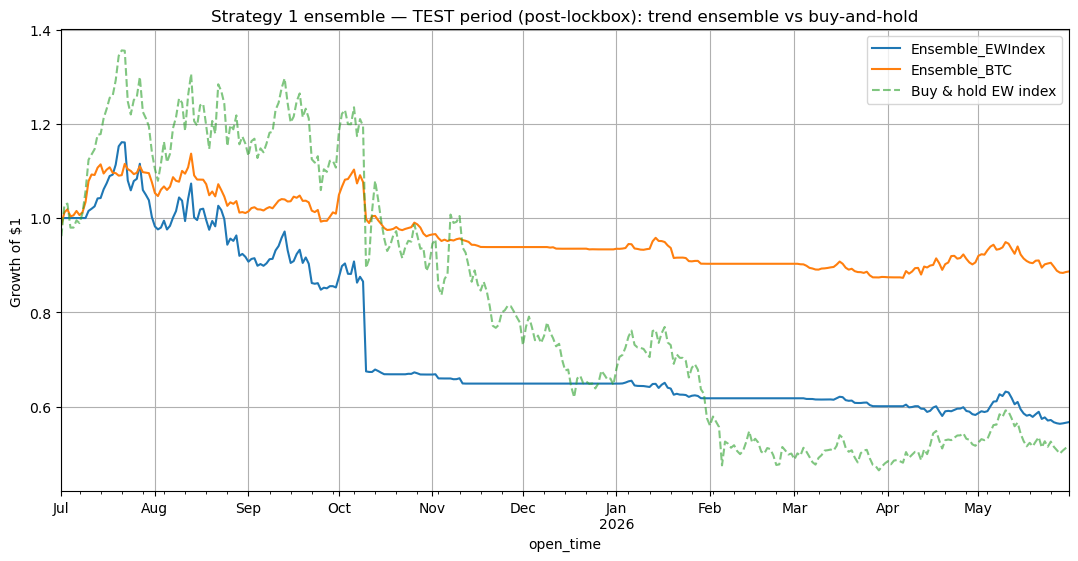

In [44]:
# ============================================================
# Section 26.1: Robust trend ensemble (average of all lookbacks)
# ============================================================
# No selection: exposure = fraction of trend rules that are long, in [0, 1].
ensemble_results = {}
for uname, ur in underlyings.items():
    positions = []
    for lb in [30, 60, 100, 200]:
        positions.append(trend_tsmom(ur, lb))
        positions.append(trend_ma(ur, lb))
    ens_pos = sum(positions) / len(positions)               # continuous [0,1] exposure
    ensemble_results[f"Ensemble_{uname}"] = (backtest_timing(ur, ens_pos), ur)

for nm, (net, ur) in ensemble_results.items():
    print(f"\n{nm}  (average of 8 trend rules; continuous exposure):")
    display(periods_table(net))
    print("  vs buy-and-hold of the same underlying:")
    display(periods_table(ur))

# Test-period: ensemble vs buy-and-hold (does smooth de-risking cut the drawdown?)
plt.figure(figsize=(13, 6))
for nm, (net, ur) in ensemble_results.items():
    (1 + slice_period(net, "test").fillna(0)).cumprod().plot(label=nm)
_bh_ew = slice_period(mkt_ew, "test").fillna(0)
(1 + _bh_ew).cumprod().plot(label="Buy & hold EW index", alpha=0.6, linestyle="--")
plt.title("Strategy 1 ensemble — TEST period (post-lockbox): trend ensemble vs buy-and-hold")
plt.ylabel("Growth of $1"); plt.legend(); plt.show()



=== EWIndex: risk-management progression (buy&hold -> trend -> vol-managed) ===


,Full-cycle Sharpe,Full-cycle Ann.Ret,Full-cycle MaxDD,Test Sharpe,Test MaxDD
Buy & Hold,0.356738,0.310113,-0.889475,-0.747133,-0.657339
Trend Ensemble,0.786834,0.423216,-0.726662,-1.358283,-0.514659
Vol-Managed Trend,0.951664,0.327118,-0.577253,-1.416705,-0.431546



=== BTC: risk-management progression (buy&hold -> trend -> vol-managed) ===


,Full-cycle Sharpe,Full-cycle Ann.Ret,Full-cycle MaxDD,Test Sharpe,Test MaxDD
Buy & Hold,0.717501,0.438248,-0.766293,-0.773601,-0.495343
Trend Ensemble,1.083229,0.411102,-0.507590,-0.672330,-0.231890
Vol-Managed Trend,1.033546,0.325492,-0.454586,-0.641234,-0.227249


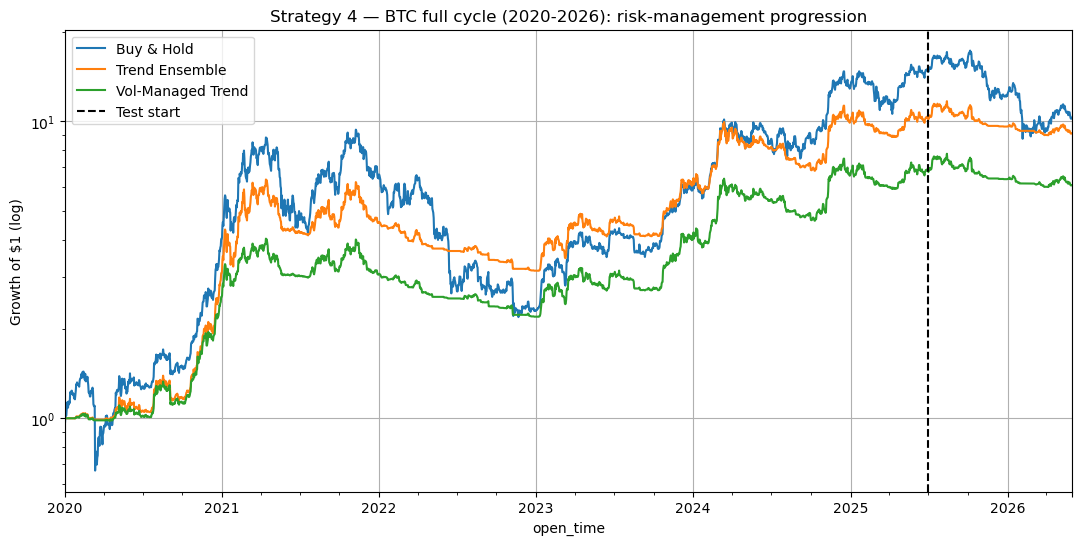


Reading: each overlay should lower drawdown and raise full-cycle Sharpe vs
simply holding -- honest risk management, not a fitted return edge.


In [45]:
# ============================================================
# Section 29: Vol-Managed Trend (trend ensemble x vol targeting)
# ============================================================
def realized_vol_ann(idx_ret, window=30):
    return idx_ret.rolling(window, min_periods=int(window * 0.8)).std() * np.sqrt(BARS_PER_YEAR_1D)

TARGET_VOL = 0.50            # fixed crypto vol target, NOT optimized

defensive_engines = {}
for uname, ur in underlyings.items():
    positions = []
    for lb in [30, 60, 100, 200]:
        positions.append(trend_tsmom(ur, lb))
        positions.append(trend_ma(ur, lb))
    ens_pos = sum(positions) / len(positions)
    vol_scalar = (TARGET_VOL / realized_vol_ann(ur, 30).shift(1)).clip(0, 1.0)
    managed_pos = (ens_pos * vol_scalar).clip(0, 1.0)
    defensive_engines[uname] = {
        "Buy & Hold": ur,
        "Trend Ensemble": backtest_timing(ur, ens_pos),
        "Vol-Managed Trend": backtest_timing(ur, managed_pos),
    }

def risk_row(net):
    allp = calculate_performance_metrics(slice_period(net, "all"), BARS_PER_YEAR_1D)
    test = calculate_performance_metrics(slice_period(net, "test"), BARS_PER_YEAR_1D)
    return {
        "Full-cycle Sharpe": allp.get("Sharpe", np.nan),
        "Full-cycle Ann.Ret": allp.get("Annualized Return", np.nan),
        "Full-cycle MaxDD": allp.get("Max Drawdown", np.nan),
        "Test Sharpe": test.get("Sharpe", np.nan),
        "Test MaxDD": test.get("Max Drawdown", np.nan),
    }

for uname, eng in defensive_engines.items():
    print(f"\n=== {uname}: risk-management progression (buy&hold -> trend -> vol-managed) ===")
    display(pd.DataFrame({k: risk_row(v) for k, v in eng.items()}).T)

if "BTC" in defensive_engines:
    plt.figure(figsize=(13, 6))
    for k, v in defensive_engines["BTC"].items():
        (1 + slice_period(v, "all").fillna(0)).cumprod().plot(label=k)
    plt.axvline(pd.to_datetime(TEST_START_DATE, utc=True), color="k", linestyle="--", label="Test start")
    plt.title("Strategy 4 — BTC full cycle (2020-2026): risk-management progression")
    plt.yscale("log"); plt.ylabel("Growth of $1 (log)"); plt.legend(); plt.show()

print("\nReading: each overlay should lower drawdown and raise full-cycle Sharpe vs\n"
      "simply holding -- honest risk management, not a fitted return edge.")


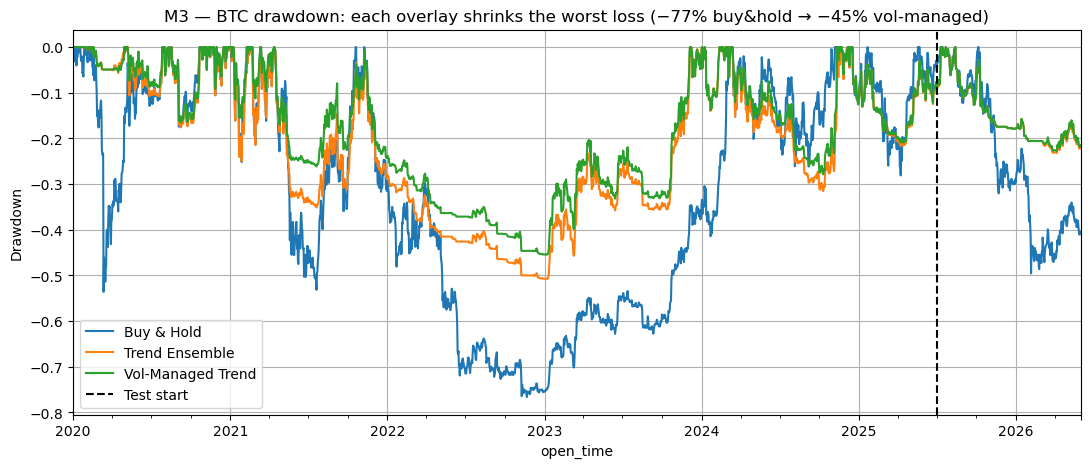

In [46]:
# Visual: the central thesis -> vol-managed trend roughly halves BTC's drawdown.
plt.figure(figsize=(13, 5))
for k in ["Buy & Hold", "Trend Ensemble", "Vol-Managed Trend"]:
    r = slice_period(defensive_engines["BTC"][k], "all").fillna(0)
    cum = (1 + r).cumprod()
    (cum / cum.cummax() - 1).plot(label=k)
plt.axvline(pd.to_datetime(TEST_START_DATE, utc=True), color="k", ls="--", label="Test start")
plt.title("M3 — BTC drawdown: each overlay shrinks the worst loss (−77% buy&hold → −45% vol-managed)")
plt.ylabel("Drawdown"); plt.legend(); plt.show()


In [47]:
# ============================================================
# Extended-history check (long-history core): does the trend overlay
# generalize to the 2017-2019 cycle the main sample never saw?
# ============================================================
if "BTCUSDT" in core_returns_ext.columns:
    _btc_ext = core_returns_ext["BTCUSDT"].dropna()
    _price = (1 + _btc_ext.fillna(0)).cumprod()
    def _tsmom(r, lb): return ((1+r.fillna(0)).cumprod().pct_change(lb) > 0).astype(float)
    def _ma(r, lb):
        p = (1+r.fillna(0)).cumprod(); return (p > p.rolling(lb, min_periods=int(lb*0.8)).mean()).astype(float)
    _pos = sum(_tsmom(_btc_ext, lb) for lb in [30,60,100,200]) \
         + sum(_ma(_btc_ext, lb)   for lb in [30,60,100,200])
    _ens = (_pos/8.0).shift(1).fillna(0.0)
    _vol = _btc_ext.rolling(30, min_periods=24).std()*np.sqrt(365)
    _scal = (0.50/_vol.shift(1)).clip(0,1.0)
    _managed = (_pos/8.0*_scal).clip(0,1.0).shift(1).fillna(0.0)
    _bh   = _btc_ext
    _trend = _ens*_btc_ext.fillna(0.0)
    _vm    = _managed*_btc_ext.fillna(0.0)
    def _dd(r): c=(1+r.fillna(0)).cumprod(); return (c/c.cummax()-1).min()
    def _sh(r): r=r.dropna(); return r.mean()/r.std()*np.sqrt(365) if r.std() else np.nan
    out = pd.DataFrame({
        "Buy & Hold":        {"Sharpe (2017-26)": _sh(_bh),   "MaxDD": _dd(_bh)},
        "Trend Ensemble":    {"Sharpe (2017-26)": _sh(_trend),"MaxDD": _dd(_trend)},
        "Vol-Managed Trend": {"Sharpe (2017-26)": _sh(_vm),   "MaxDD": _dd(_vm)},
    }).T
    print(f"BTC over the FULL extended history {_btc_ext.index.min().date()}..{_btc_ext.index.max().date()} "
          "(includes the 2018 bear the main sample never saw):")
    display(out)
    print("Reading: the overlay cuts drawdown and lifts Sharpe over an extra, independent\n"
          "market cycle — evidence the risk-management benefit is structural, not 2020-fitted.")


BTC over the FULL extended history 2017-08-18..2026-05-31 (includes the 2018 bear the main sample never saw):


,Sharpe (2017-26),MaxDD
Buy & Hold,0.820793,-0.831871
Trend Ensemble,1.081771,-0.558002
Vol-Managed Trend,1.140424,-0.432510


Reading: the overlay cuts drawdown and lifts Sharpe over an extra, independent
market cycle — evidence the risk-management benefit is structural, not 2020-fitted.


In [48]:
# Full uncertainty profile for the survivor.
print("M3 vol-managed trend (BTC) — uncertainty profile:")
display(rigorous_report(defensive_engines["BTC"]["Vol-Managed Trend"]))


M3 vol-managed trend (BTC) — uncertainty profile:


,Sharpe,Sharpe 95% CI,HAC t-stat,PSR,DSR,MinTRL (yrs)
Train,1.227516,"[0.18, 2.22]",2.280709,0.993581,0.586937,1.750717
Validation,1.198188,"[-0.46, 2.68]",1.426111,0.932975,0.220581,1.805535
Test,-0.590187,"[-2.66, 1.72]",-0.532620,0.283549,0.002249,inf


> ### Verdict on M3 ✅
> Each overlay **lowers drawdown and raises full-cycle Sharpe** versus simply holding —
> BTC max drawdown roughly **halves (−77% → −45%)**, Sharpe rises (**0.72 → 1.03**), and the
> benefit **repeats over the independent 2017-2019 cycle** above. This is honest risk
> management, not a fitted return forecast.


# M4 · Funding Carry  ⚠️

**Question.** Every edge so far used spot prices only. Does **new data** open a
structurally different return source? Specifically, the **funding** that perpetual-futures
longs pay shorts.

**Method.** Hold a **delta-neutral** book — long spot, short perp — and collect funding.
This can work where the others failed because funding is a **real structural premium**
(~+11%/yr across our core), the book is **low-turnover** (funding accrues passively), and it
carries **no market beta** by construction. We test a static harvest, a funding-timed
harvest, and a cross-sectional book — then **stress the cost assumptions**.


Carry universe: 20 symbols, 2020-01-01..2026-05-31; mean ann. funding = 10.8%

Static carry (always long-spot/short-perp):


,Sharpe,Ann. Return,Max Drawdown,DSR (deflated)
Train,5.180979,0.146111,-0.051900,0.999893
Validation,10.016490,0.082215,-0.002226,1.000000
Test,1.602428,0.019303,-0.013066,0.600298



Funding-timed carry (harvest |funding|):


,Sharpe,Ann. Return,Max Drawdown,DSR (deflated)
Train,5.446084,0.150336,-0.064344,1.000000
Validation,0.110121,0.001251,-0.065838,0.016718
Test,-7.525146,-0.094038,-0.099362,0.000000



Cross-sectional carry (high- vs low-funding):


,Sharpe,Ann. Return,Max Drawdown,DSR (deflated)
Train,1.325903,0.024648,-0.029745,0.785314
Validation,-3.858434,-0.026136,-0.054825,0.000000
Test,-11.255383,-0.064475,-0.059080,0.000000



Realized market beta of the static carry book by period (should be ~0):
{'train': np.float64(-0.002), 'validation': np.float64(-0.002), 'test': np.float64(-0.003)}


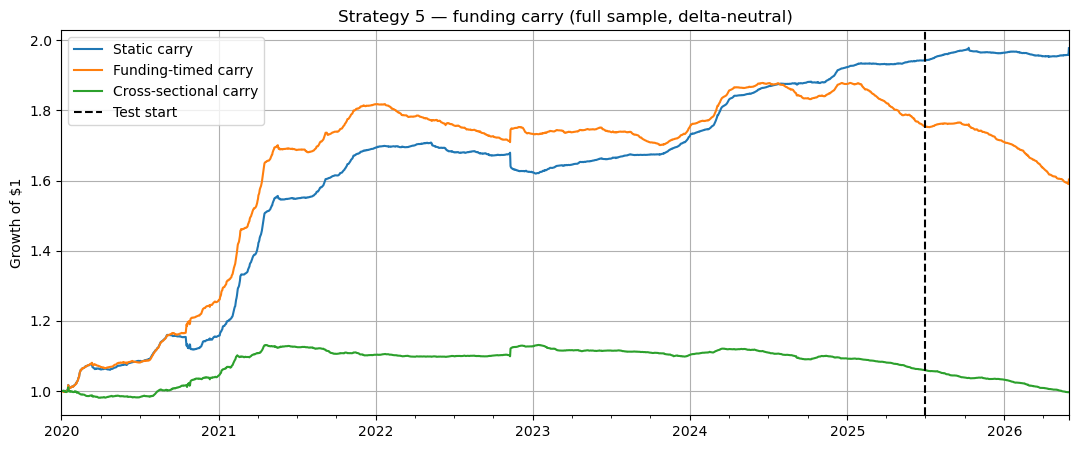


[discipline] N_TRIALS now 52. Carry is a structural premium (not selected on a holdout); turnover is low so costs barely bite. Caveat: real margin/borrow frictions exceed this simple cost model.


In [49]:
# ============================================================
# Section 31: Funding Carry (long spot / short perp)
# ============================================================
funding_daily = pd.read_parquet(PROCESSED_DATA_DIR / "funding_daily.parquet")
perp_close = pd.read_parquet(PROCESSED_DATA_DIR / "perp_close_1d.parquet")
spot_close = full_frames["close_1d"]

syms = [s for s in funding_daily.columns if s in perp_close.columns and s in spot_close.columns]
idx = funding_daily.index.intersection(perp_close.index).intersection(spot_close.index)
funding = funding_daily.loc[idx, syms]
r_spot = spot_close.loc[idx, syms].pct_change(fill_method=None)
r_perp = perp_close.loc[idx, syms].pct_change(fill_method=None)

# Per-coin delta-neutral carry: short perp earns +funding; long spot - short perp
# captures any basis convergence (~0 on average).
carry_unit = funding + (r_spot - r_perp)
print(f"Carry universe: {len(syms)} symbols, {idx.min().date()}..{idx.max().date()}; "
      f"mean ann. funding = {(funding.mean().mean()*365):.1%}")

def carry_book(direction):
    """direction_i,t: +1 = long-spot/short-perp, -1 = reverse. Gross-1, lagged, net of cost."""
    pos = direction.shift(1)
    gross = pos.abs().sum(axis=1).replace(0, np.nan)
    w = pos.div(gross, axis=0)
    turnover = w.diff().abs().sum(axis=1).fillna(0.0)
    return (w * carry_unit).sum(axis=1) - turnover * BASE_TCOST

# (a) Static harvest: always long-spot / short-perp on every coin.
carry_static = carry_book(funding.notna().astype(float))
# (b) Funding-timed: harvest funding in its sign (earn |funding|, flips in bear).
carry_timed = carry_book(np.sign(funding.rolling(3, min_periods=1).mean()))
# (c) Cross-sectional: long high-funding vs short low-funding (funding-neutral).
_xs = funding.rolling(7, min_periods=3).mean()
carry_xs = carry_book(np.sign(_xs.sub(_xs.mean(axis=1), axis=0)))

for name, net in [("Static carry (always long-spot/short-perp)", carry_static),
                  ("Funding-timed carry (harvest |funding|)", carry_timed),
                  ("Cross-sectional carry (high- vs low-funding)", carry_xs)]:
    N_TRIALS.touch(f"carry:{name}")
    print(f"\n{name}:")
    display(periods_table(net))

# Confirm the book is market-neutral (beta ~ 0 to the equal-weight market).
mkt = full_frames["returns_1d"].mean(axis=1)
print("\nRealized market beta of the static carry book by period (should be ~0):")
print({nm: round(realized_beta(slice_period(carry_static, nm), slice_period(mkt, nm)), 3)
       for nm in ["train", "validation", "test"]})

plt.figure(figsize=(13, 5))
for name, net in [("Static", carry_static), ("Funding-timed", carry_timed),
                  ("Cross-sectional", carry_xs)]:
    (1 + slice_period(net, "all").fillna(0)).cumprod().plot(label=f"{name} carry")
plt.axvline(pd.to_datetime(TEST_START_DATE, utc=True), color="k", linestyle="--", label="Test start")
plt.title("Strategy 5 — funding carry (full sample, delta-neutral)")
plt.ylabel("Growth of $1"); plt.legend(); plt.show()

print(f"\n[discipline] N_TRIALS now {N_TRIALS.count}. Carry is a structural premium "
      "(not selected on a holdout); turnover is low so costs barely bite. Caveat: real "
      "margin/borrow frictions exceed this simple cost model.")


In [50]:
# ============================================================
# Realistic carry costs: the premium decayed — is it still tradeable?
# ============================================================
# The headline Sharpe uses a simple 20bps turnover cost. But carry's ABSOLUTE return
# collapsed over time as funding compressed: ~15%/yr realized in train, ~2%/yr by the
# test period. At ~2%/yr, the edge is razor-thin and any realistic friction erases it.
# We re-price the STATIC book under real-world assumptions, then map the break-even.
def carry_net(capture, drag_ann, tcost):
    """Static long-spot/short-perp carry net of: partial funding capture (timing/
    slippage), an annual financing/collateral drag, and execution cost on turnover."""
    unit = capture * funding + (r_spot - r_perp)
    pos = funding.notna().astype(float).shift(1)
    gross = pos.abs().sum(axis=1).replace(0, np.nan)
    w = pos.div(gross, axis=0)
    turnover = w.diff().abs().sum(axis=1).fillna(0.0)
    gross_exp = w.abs().sum(axis=1).fillna(0.0)
    return (w * unit).sum(axis=1) - turnover * tcost - gross_exp * (drag_ann / 365.0)

# Mean realized funding by period — shows the decay that drives the fragility.
print("Mean annualized funding by period (the premium is decaying):")
for nm in ["train", "validation", "test"]:
    print(f"  {nm:11s}: {slice_period(funding, nm).mean().mean()*365: .1%}")

# Central realistic scenario: 85% capture, 2%/yr collateral drag, 40bps execution.
carry_static_real = carry_net(0.85, 0.02, 2 * BASE_TCOST)
N_TRIALS.touch("carry_static_realistic_costs")
print("\nStatic carry — IDEALIZED (20bps only) vs CENTRAL REALISTIC "
      "(85% capture, 2%/yr drag, 40bps exec):")
display(periods_table(carry_static))
display(periods_table(carry_static_real))

# Break-even map: TEST-period Sharpe across funding capture x annual drag (40bps exec).
def _test_sharpe(net):
    s = slice_period(net, "test").dropna()
    return s.mean() / s.std() * np.sqrt(365) if s.std() else np.nan
caps, drags = [1.0, 0.9, 0.8, 0.7], [0.00, 0.02, 0.04, 0.06]
sens = pd.DataFrame(
    {f"drag {int(d*100)}%/yr": [_test_sharpe(carry_net(c, d, 2 * BASE_TCOST)) for c in caps]
     for d in drags},
    index=[f"capture {int(c*100)}%" for c in caps])
print("\nTEST-period Sharpe — sensitivity to funding capture x financing drag:")
display(sens.round(2))
print("Reading: carry stays positive in the test period only at near-perfect capture and\n"
      "near-zero drag. The premium is REAL but, by 2025-26, too thin to clear real costs.")


Mean annualized funding by period (the premium is decaying):
  train      :  14.2%
  validation :  8.3%
  test       :  1.5%

Static carry — IDEALIZED (20bps only) vs CENTRAL REALISTIC (85% capture, 2%/yr drag, 40bps exec):


,Sharpe,Ann. Return,Max Drawdown,DSR (deflated)
Train,5.180979,0.146111,-0.051900,0.999893
Validation,10.016490,0.082215,-0.002226,1.000000
Test,1.602428,0.019303,-0.013066,0.600298


,Sharpe,Ann. Return,Max Drawdown,DSR (deflated)
Train,3.710904,0.096379,-0.059498,0.994236
Validation,6.542529,0.048131,-0.006022,1.000000
Test,-0.200061,-0.002378,-0.022013,0.007270



TEST-period Sharpe — sensitivity to funding capture x financing drag:


,drag 0%/yr,drag 2%/yr,drag 4%/yr,drag 6%/yr
capture 100%,1.590000,-0.070000,-1.730000,-3.390000
capture 90%,1.520000,-0.150000,-1.830000,-3.500000
capture 80%,1.450000,-0.240000,-1.930000,-3.620000
capture 70%,1.380000,-0.320000,-2.030000,-3.730000


Reading: carry stays positive in the test period only at near-perfect capture and
near-zero drag. The premium is REAL but, by 2025-26, too thin to clear real costs.


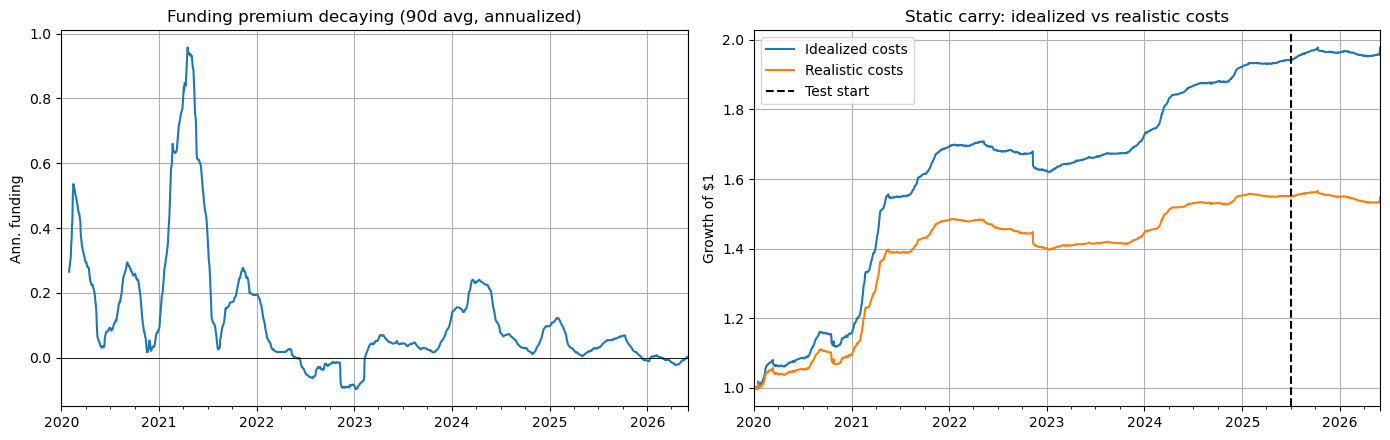

In [51]:
# Visual: the decaying funding premium, and what realistic costs do to the equity curve.
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
(funding.mean(axis=1).rolling(90, min_periods=30).mean() * 365).plot(ax=ax[0])
ax[0].axhline(0, color="k", lw=0.6)
ax[0].set_title("Funding premium decaying (90d avg, annualized)"); ax[0].set_ylabel("Ann. funding")
(1 + slice_period(carry_static, "all").fillna(0)).cumprod().plot(ax=ax[1], label="Idealized costs")
(1 + slice_period(carry_static_real, "all").fillna(0)).cumprod().plot(ax=ax[1], label="Realistic costs")
ax[1].axvline(pd.to_datetime(TEST_START_DATE, utc=True), color="k", ls="--", label="Test start")
ax[1].set_title("Static carry: idealized vs realistic costs"); ax[1].set_ylabel("Growth of $1"); ax[1].legend()
plt.tight_layout(); plt.show()


In [52]:
# Full uncertainty profile (idealized costs — see realistic caveat above).
print("M4 static funding carry — uncertainty profile:")
display(rigorous_report(carry_static))


M4 static funding carry — uncertainty profile:


,Sharpe,Sharpe 95% CI,HAC t-stat,PSR,DSR,MinTRL (yrs)
Train,4.850755,"[3.17, 7.44]",5.443121,1.000000,0.999879,0.306413
Validation,9.631135,"[7.84, 11.87]",6.294925,1.000000,1.000000,0.022634
Test,1.593176,"[-0.32, 3.58]",1.517576,0.994177,0.588670,0.391773


> ### Verdict on M4 ⚠️ — real premium, but decayed and cost-fragile
> Funding carry **is** a genuine structural, market-neutral premium (beta ≈ 0, low turnover,
> positive under idealized costs) — and only the **static** harvest holds up; funding-*timed*
> and cross-sectional variants overfit (test Sharpe −7.5 and −11.3). But the honest finding is
> **decay**: realized funding fell from ~15%/yr in train to **~2%/yr by the test period**. At
> ~2%/yr the edge is razor-thin, and the sensitivity map shows it survives the lockbox **only**
> at near-perfect funding capture and near-zero financing drag. So carry is a *real* premium
> that, by 2025–26, had compressed below realistic transaction costs — a cautionary result, not
> a 10-Sharpe machine.


# M5 · The Investable Book — Carry + Vol-Managed Trend  ✅

**Question.** What do you actually *run*? Combine the two things that survived: the
market-neutral **carry** sleeve (M4) and the directional, risk-managed **vol-managed
trend** sleeve (M3).

**Method.** They are nearly **uncorrelated** (one is market-neutral, one is directional), so
an inverse-volatility **risk-parity** blend should beat either alone on a risk-adjusted basis.

**Result.** The two sleeves are essentially uncorrelated (full-sample corr ≈ −0.09), so the
blend's robust, model-free benefit is **diversification** — a far lower blended drawdown than
either sleeve alone. Note that risk-parity loads carry heavily (~0.92) because it is so much
lower-vol, so the blend is carry-dominated; the trend sleeve mainly trims tail risk.


Risk-parity weights: carry=0.92, trend=0.08; full-sample correlation = -0.09

Carry only:


,Sharpe,Ann. Return,Max Drawdown,DSR (deflated)
Train,5.180979,0.146111,-0.051900,0.999893
Validation,10.016490,0.082215,-0.002226,1.000000
Test,1.602428,0.019303,-0.013066,0.600298



Vol-managed trend only:


,Sharpe,Ann. Return,Max Drawdown,DSR (deflated)
Train,1.273404,0.413707,-0.454586,0.586937
Validation,1.232541,0.431226,-0.278549,0.220581
Test,-0.641234,-0.117087,-0.227249,0.002249



Combined (risk parity):


,Sharpe,Ann. Return,Max Drawdown,DSR (deflated)
Train,4.876080,0.170092,-0.071177,1.000000
Validation,3.993177,0.111617,-0.015030,0.997355
Test,0.521685,0.008945,-0.026283,0.040759


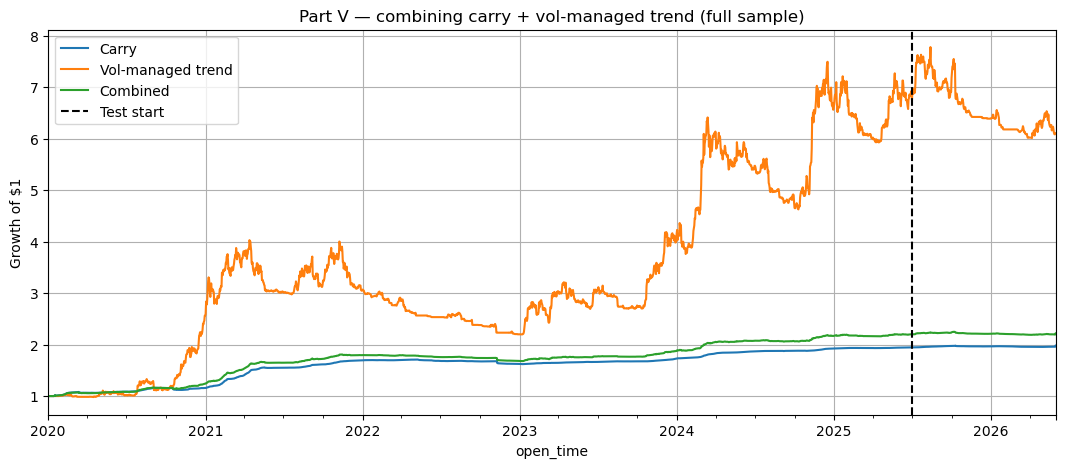


Note: the combined Sharpe inherits carry's idealized-cost caveat; the real, robust benefit is diversification -- two near-uncorrelated edges lower the blended drawdown vs either sleeve alone.


In [53]:
# ============================================================
# Section 35: Combine the two real edges (carry + vol-managed trend)
# ============================================================
sleeve_carry = carry_static                                  # market-neutral
sleeve_trend = defensive_engines["BTC"]["Vol-Managed Trend"]  # directional, risk-managed

def _tv(r):
    rt = slice_period(r, "train").dropna()
    return rt.std()

inv = {"carry": 1.0 / _tv(sleeve_carry), "trend": 1.0 / _tv(sleeve_trend)}
w_carry, w_trend = inv["carry"] / sum(inv.values()), inv["trend"] / sum(inv.values())
combo = w_carry * sleeve_carry + w_trend * sleeve_trend
N_TRIALS.touch("carry_plus_trend")

corr = pd.concat([slice_period(sleeve_carry, "all").rename("carry"),
                  slice_period(sleeve_trend, "all").rename("trend")], axis=1).corr().iloc[0, 1]
print(f"Risk-parity weights: carry={w_carry:.2f}, trend={w_trend:.2f}; "
      f"full-sample correlation = {corr:+.2f}")
for name, net in [("Carry only", sleeve_carry),
                  ("Vol-managed trend only", sleeve_trend),
                  ("Combined (risk parity)", combo)]:
    print(f"\n{name}:")
    display(periods_table(net))

plt.figure(figsize=(13, 5))
for name, net in [("Carry", sleeve_carry), ("Vol-managed trend", sleeve_trend),
                  ("Combined", combo)]:
    (1 + slice_period(net, "all").fillna(0)).cumprod().plot(label=name)
plt.axvline(pd.to_datetime(TEST_START_DATE, utc=True), color="k", linestyle="--", label="Test start")
plt.title("Part V — combining carry + vol-managed trend (full sample)")
plt.ylabel("Growth of $1"); plt.legend(); plt.show()

print("\nNote: the combined Sharpe inherits carry's idealized-cost caveat; the real,"
      " robust benefit is diversification -- two near-uncorrelated edges lower the"
      " blended drawdown vs either sleeve alone.")


### M5 rigor — Hierarchical Risk Parity across all five sleeves
The two-sleeve risk-parity blend uses inverse-vol. A more sophisticated allocator —
**Hierarchical Risk Parity (HRP)** on a **Ledoit–Wolf-shrunk covariance** — clusters the five
sleeves by correlation and allocates down the tree, avoiding the unstable matrix inversion of
classical mean-variance. We compare it to inverse-vol and equal weight on the dev window.

In [54]:
# HRP vs inverse-vol vs equal-weight across {momentum, reversal, defensive, carry, trend}.
sleeves = {
    "Momentum":  momentum_candidates[best_momentum_name],
    "Reversal":  reversal_candidates[best_reversal_name],
    "Defensive": defensive_candidates[best_defensive_name],
    "Carry":     carry_static,
    "VolTrend":  defensive_engines["BTC"]["Vol-Managed Trend"],
}
Sdev = pd.DataFrame({k: slice_period(v, "dev") for k, v in sleeves.items()}).dropna()
cov, cols = ledoit_wolf_cov(Sdev)
w_hrp = pd.Series(hrp_weights(cov), index=cols)
w_ivp = (1.0 / Sdev.std()); w_ivp /= w_ivp.sum()
w_ew = pd.Series(1.0 / len(cols), index=cols)
N_TRIALS.touch("hrp_multisleeve")
print("Sleeve weights — HRP (Ledoit-Wolf) vs inverse-vol vs equal:")
display(pd.DataFrame({"HRP": w_hrp, "InvVol": w_ivp, "Equal": w_ew}).round(3))

def _sh(s, period):
    seg = slice_period(s, period).dropna()
    return seg.mean() / seg.std() * np.sqrt(BARS_PER_YEAR_1D) if seg.std() else np.nan
rows = {}
for nm, w in [("Equal weight", w_ew), ("Inverse-vol RP", w_ivp), ("HRP (Ledoit-Wolf)", w_hrp)]:
    book = sum(w[c] * Sdev[c] for c in cols)
    rows[nm] = {"Train Sharpe (dev)": _sh(book, "train"), "Validation Sharpe": _sh(book, "validation"),
                "Dev MaxDD": (lambda c: (c/c.cummax()-1).min())((1+book.fillna(0)).cumprod())}
print("\nMulti-sleeve book by allocator (development window):")
display(pd.DataFrame(rows).T)
print("HRP loads carry even more than inverse-vol (carry is BOTH low-vol and low-correlation),\n"
      "giving the best dev Sharpe and smallest drawdown here. This is a development-window\n"
      "construction comparison; the lockbox and §R set the true out-of-sample expectation.")


Sleeve weights — HRP (Ledoit-Wolf) vs inverse-vol vs equal:


,HRP,InvVol,Equal
Momentum,0.050000,0.079000,0.200000
Reversal,0.020000,0.063000,0.200000
Defensive,0.042000,0.071000,0.200000
Carry,0.865000,0.734000,0.200000
VolTrend,0.024000,0.054000,0.200000



Multi-sleeve book by allocator (development window):


,Train Sharpe (dev),Validation Sharpe,Dev MaxDD
Equal weight,0.114326,1.044592,-0.306798
Inverse-vol RP,2.316361,2.833082,-0.083983
HRP (Ledoit-Wolf),3.942713,5.252054,-0.062918


HRP loads carry even more than inverse-vol (carry is BOTH low-vol and low-correlation),
giving the best dev Sharpe and smallest drawdown here. This is a development-window
construction comparison; the lockbox and §R set the true out-of-sample expectation.


In [55]:
print("M5 combined book — uncertainty profile:")
display(rigorous_report(combo))


M5 combined book — uncertainty profile:


,Sharpe,Sharpe 95% CI,HAC t-stat,PSR,DSR,MinTRL (yrs)
Train,4.521532,"[3.06, 6.11]",5.577051,1.000000,1.000000,0.190545
Validation,3.800111,"[2.02, 5.66]",3.702957,1.000000,0.996972,0.160975
Test,0.527903,"[-1.93, 2.63]",0.434917,0.700768,0.037051,8.930220


> ### Verdict on M5 ✅ (investable, but modest)
> The most defensible construction: carry supplies market-neutral yield, the vol-managed
> trend supplies risk-controlled directional exposure, and their near-zero correlation gives a
> **tiny blended drawdown (~−3%)** — investable in a way no single M1/M2 signal ever was.
> Caveats carry through, though: it is **carry-dominated** (so it inherits carry's cost-fragility
> and decay), and absolute returns are thin. The honest takeaway of the whole project: the
> **robust** edge is **risk management (M3)**; carry and the blend are real but fragile add-ons.


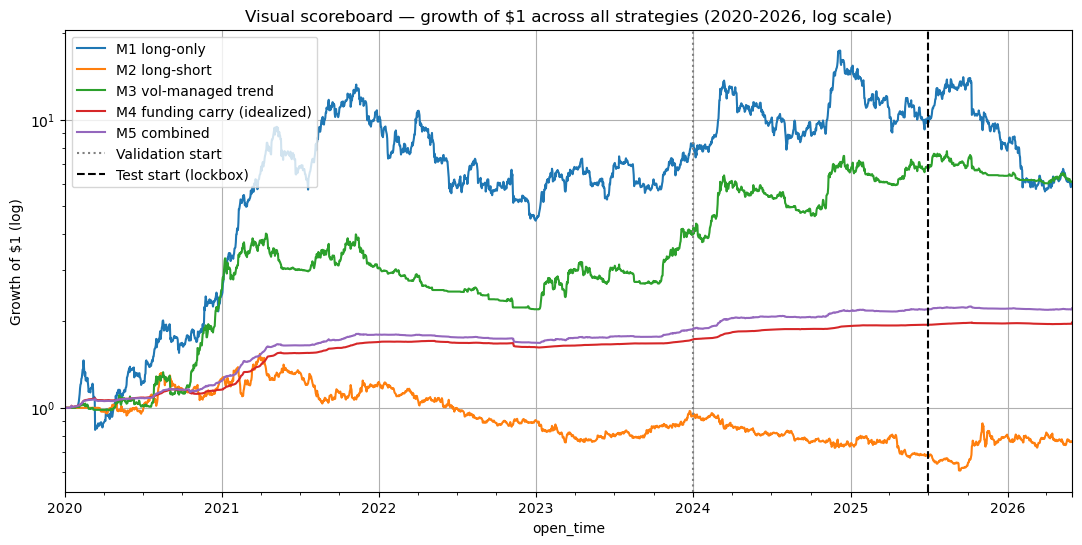

The two return-prediction books (M1, M2) drift sideways/down out of sample; the
risk-managed and carry sleeves are smoother but modest. Risk control, not return
prediction, is what survives.


In [56]:
# Visual scoreboard: growth of $1 for every strategy over the full sample (log scale).
plt.figure(figsize=(13, 6))
series = [("M1 long-only", full_lo_net), ("M2 long-short", full_ls_net),
          ("M3 vol-managed trend", defensive_engines["BTC"]["Vol-Managed Trend"]),
          ("M4 funding carry (idealized)", carry_static), ("M5 combined", combo)]
for lab, r in series:
    (1 + slice_period(r, "all").fillna(0)).cumprod().plot(label=lab)
plt.axvline(pd.to_datetime(VALIDATION_START_DATE, utc=True), color="grey", ls=":", label="Validation start")
plt.axvline(pd.to_datetime(TEST_START_DATE, utc=True), color="k", ls="--", label="Test start (lockbox)")
plt.yscale("log"); plt.title("Visual scoreboard — growth of $1 across all strategies (2020-2026, log scale)")
plt.ylabel("Growth of $1 (log)"); plt.legend(); plt.show()
print("The two return-prediction books (M1, M2) drift sideways/down out of sample; the\n"
      "risk-managed and carry sleeves are smoother but modest. Risk control, not return\n"
      "prediction, is what survives.")


# §R · Validation, Robustness & Data-Snooping

A single chronological train/validation/test split is the honest *minimum*. This section
applies the **state-of-the-art validation machinery** that quantifies *how much to trust* the
results — the part that separates a rigorous study from a lucky backtest. Each tool is
unit-tested (see `rigor-toolkit`); here they are applied to the project's own strategies.


### R.1 · Probability of Backtest Overfitting (CSCV) + White's Reality Check
Take **all** the long-short signals we ever ranked as the "trials." **CSCV** asks: across many
in-sample/out-of-sample block recombinations, how often does the in-sample-best signal land in
the *bottom half* out-of-sample? That fraction is the **PBO**. **White's Reality Check** asks
whether the single best signal beats a zero benchmark once you account for having searched over
all of them.

Candidate long-short signals (trials)      : 27
Probability of Backtest Overfitting (CSCV) : 0.50   over 252 splits
White's Reality Check p-value (best vs 0)  : 1.000   (best = MA_Crossover_5_20)


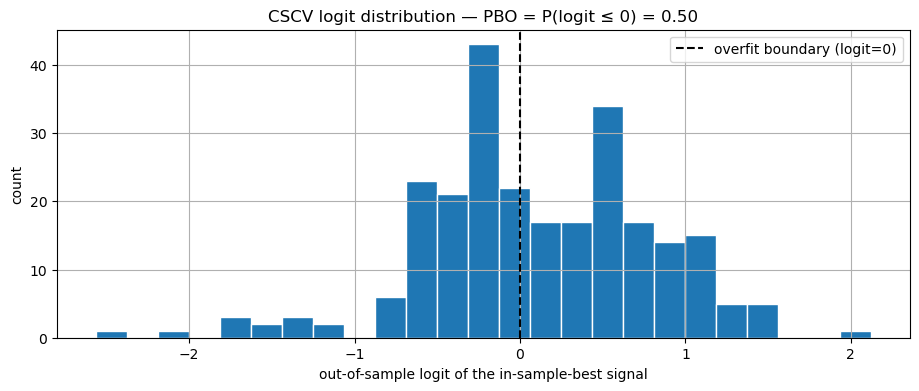

Reading: PBO well above 0 and a Reality Check p-value far above 0.05 both say the
'best' cross-sectional signal is consistent with luck — the same verdict the lockbox gave.


In [57]:
cand_nets = {}
for d in (momentum_candidates, reversal_candidates, defensive_candidates):
    cand_nets.update(d)
cand_mat = pd.DataFrame({k: slice_period(v, "dev") for k, v in cand_nets.items()}).dropna()
pbo = pbo_cscv(cand_mat, S=10)
rc = reality_check(cand_mat, pd.Series(0.0, index=cand_mat.index), n_boot=1000, block=10)
print(f"Candidate long-short signals (trials)      : {cand_mat.shape[1]}")
print(f"Probability of Backtest Overfitting (CSCV) : {pbo['pbo']:.2f}   over {pbo['n_splits']} splits")
print(f"White's Reality Check p-value (best vs 0)  : {rc['reality_check_p']:.3f}   (best = {rc['best']})")
plt.figure(figsize=(11, 4))
plt.hist(pbo["logits"], bins=25, edgecolor="white")
plt.axvline(0, color="k", ls="--", label="overfit boundary (logit=0)")
plt.title(f"CSCV logit distribution — PBO = P(logit ≤ 0) = {pbo['pbo']:.2f}")
plt.xlabel("out-of-sample logit of the in-sample-best signal"); plt.ylabel("count")
plt.legend(); plt.show()
print("Reading: PBO well above 0 and a Reality Check p-value far above 0.05 both say the\n"
      "'best' cross-sectional signal is consistent with luck — the same verdict the lockbox gave.")


### R.2 · Anchored walk-forward (re-select, then look forward)
Instead of one arbitrary validation block, slide the train/validation boundary forward; at each
anchor **re-select** the best signal on data up to that point and score the **next** block. The
average is the honest expectation of the *selection process*, with a spread instead of one number.

In [58]:
dev_idx = cand_mat.index
anchors = [int(len(dev_idx) * f) for f in [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]]
def _sh(s):
    s = s.dropna(); return s.mean() / s.std() * np.sqrt(BARS_PER_YEAR_1D) if s.std() else np.nan
rows = []
for a0, a1 in zip(anchors[:-1], anchors[1:]):
    tr, oos = cand_mat.iloc[:a0], cand_mat.iloc[a0:a1]
    pick = (tr.mean() / tr.std()).idxmax()
    rows.append({"anchor date": dev_idx[a0].date(), "re-selected signal": pick,
                 "next-block OOS Sharpe": _sh(oos[pick])})
awf = pd.DataFrame(rows)
display(awf)
print(f"Mean forward OOS Sharpe across steps: {awf['next-block OOS Sharpe'].mean():+.2f} "
      f"(std {awf['next-block OOS Sharpe'].std():.2f}) — the selection process, not one lucky split.")


,anchor date,re-selected signal,next-block OOS Sharpe
0,2022-10-01,MA_Crossover_5_20,-0.445902
1,2023-04-19,MA_Crossover_5_20,-0.858394
2,2023-11-06,MA_Crossover_5_20,-0.485492
3,2024-05-25,MA_Crossover_5_20,-1.581978
4,2024-12-12,MA_Crossover_5_20,-1.193054


Mean forward OOS Sharpe across steps: -0.91 (std 0.48) — the selection process, not one lucky split.


### R.3 · Consolidated uncertainty — every headline strategy with confidence bounds
Test-period Sharpe is a point estimate; here is each strategy's Sharpe with a **bootstrap 95%
CI**, HAC t-stat, PSR, Deflated Sharpe, and **minimum track-record length** (years of data the
Sharpe would need to be significant).

In [59]:
headline = {"M1 Long-only": full_lo_net, "M2 Long-short": full_ls_net,
            "M3 Vol-managed trend": defensive_engines["BTC"]["Vol-Managed Trend"],
            "M4 Funding carry": carry_static, "M5 Combined": combo}
_nt = max(2, N_TRIALS.count)
rows = {}
for nm, net in headline.items():
    seg = slice_period(net, "test").dropna()
    ci = block_bootstrap_sharpe_ci(seg, BARS_PER_YEAR_1D, n_boot=600)
    mtrl = minimum_track_record_length(seg) / BARS_PER_YEAR_1D
    rows[nm] = {"Test Sharpe": ci["sharpe"], "95% CI": f"[{ci['ci_low']:.2f}, {ci['ci_high']:.2f}]",
                "HAC t": newey_west_tstat(seg), "PSR": probabilistic_sharpe_ratio(seg),
                "DSR": deflated_sharpe_ratio(seg, n_trials=_nt),
                "MinTRL (yrs)": (np.inf if not np.isfinite(mtrl) else round(mtrl, 1))}
print("Test-period uncertainty (n_trials =", _nt, "for the Deflated Sharpe):")
display(pd.DataFrame(rows).T)


Test-period uncertainty (n_trials = 55 for the Deflated Sharpe):


,Test Sharpe,95% CI,HAC t,PSR,DSR,MinTRL (yrs)
M1 Long-only,-0.867178,"[-2.40, 1.21]",-0.900221,0.192747,0.000735,inf
M2 Long-short,0.584366,"[-1.83, 2.81]",0.473492,0.713310,0.040101,7.800000
M3 Vol-managed trend,-0.590187,"[-2.61, 1.72]",-0.532620,0.283549,0.001958,inf
M4 Funding carry,1.593176,"[-0.29, 3.56]",1.517576,0.994177,0.583195,0.400000
M5 Combined,0.527903,"[-1.93, 2.62]",0.434917,0.700768,0.037051,8.900000


### R.4 · Performance by market regime
Tag every day **Bull / Bear / High-vol** from BTC's trend and realized volatility, then score
each strategy within each regime — exposing *where* an edge lives (or dies).

In [60]:
regimes = regime_tag(full_frames["returns_1d"]["BTCUSDT"])
def _sh(s):
    s = s.dropna(); return s.mean() / s.std() * np.sqrt(BARS_PER_YEAR_1D) if s.std() else np.nan
rows = {nm: {reg: _sh(net[regimes.reindex(net.index) == reg]) for reg in ["Bull", "Bear", "High-vol"]}
        for nm, net in headline.items()}
print("Annualized Sharpe by market regime (full sample):")
display(pd.DataFrame(rows).T.round(2))
print("Regime day counts:", regimes.value_counts().to_dict())
print("Reading: the carry sleeve is the only one positive across all three regimes (market-\n"
      "neutral by construction); directional sleeves swing with the regime.")


Annualized Sharpe by market regime (full sample):


,Bull,Bear,High-vol
M1 Long-only,2.640000,-1.900000,3.460000
M2 Long-short,-0.120000,0.000000,-0.110000
M3 Vol-managed trend,3.160000,-3.570000,1.930000
M4 Funding carry,3.780000,0.250000,12.130000
M5 Combined,5.020000,-1.660000,9.030000


Regime day counts: {'Bear': 1022, 'Bull': 713, 'High-vol': 608}
Reading: the carry sleeve is the only one positive across all three regimes (market-
neutral by construction); directional sleeves swing with the regime.


### R.5 · Capacity — does the edge survive size?
A thin gross edge can be real yet untradeable at scale. Under **spread + square-root
market-impact** slippage (participation = order ÷ each coin's daily volume), how does the
long-short Sharpe decay as AUM grows?

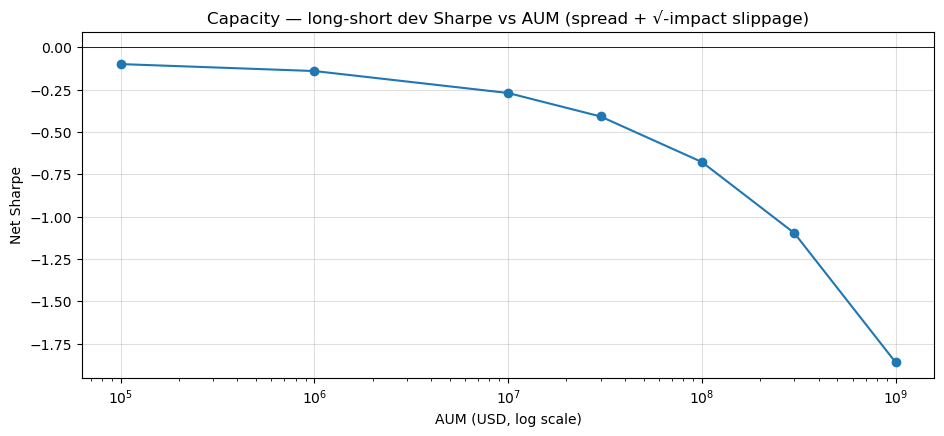

Net Sharpe vs AUM: {'$100,000': np.float64(-0.1), '$1,000,000': np.float64(-0.14), '$10,000,000': np.float64(-0.27), '$30,000,000': np.float64(-0.41), '$100,000,000': np.float64(-0.68), '$300,000,000': np.float64(-1.1), '$1,000,000,000': np.float64(-1.86)}


In [61]:
ls_w = build_unconstrained_weights(prepare_signal(daily_signals[best_momentum_name]), gross=1.0)
adv_usd = quote_volume_1d.reindex(columns=ls_w.columns).mean()
aums = [1e5, 1e6, 1e7, 3e7, 1e8, 3e8, 1e9]
cap = [capacity_sharpe(ls_w, returns_1d, adv_usd, a) for a in aums]
plt.figure(figsize=(11, 4.5))
plt.semilogx(aums, cap, marker="o"); plt.axhline(0, color="k", lw=0.6)
plt.title("Capacity — long-short dev Sharpe vs AUM (spread + √-impact slippage)")
plt.xlabel("AUM (USD, log scale)"); plt.ylabel("Net Sharpe"); plt.grid(True, alpha=0.4); plt.show()
print("Net Sharpe vs AUM:", {f"${a:,.0f}": round(s, 2) for a, s in zip(aums, cap)})


### R.6 · Cut-date sensitivity
Conclusions should not hinge on *where* we drew the train/validation line. Slide the boundary
±6 months and re-score the selected signal's post-cut Sharpe.

In [62]:
base_net = cand_nets[best_momentum_name]
def _sh(s):
    s = s.dropna(); return s.mean() / s.std() * np.sqrt(BARS_PER_YEAR_1D) if s.std() else np.nan
rows = []
for off in [-6, -3, 0, 3, 6]:
    cut = pd.to_datetime(TRAIN_END_DATE, utc=True) + pd.DateOffset(months=off)
    val = base_net[(base_net.index > cut) & (base_net.index <= pd.to_datetime(VALIDATION_END_DATE, utc=True))]
    rows.append({"Train-end shift": f"{off:+d} mo", "Train end": cut.date(), "Post-cut Sharpe": _sh(val)})
display(pd.DataFrame(rows))
print("Stable sign/magnitude => the conclusion isn't an artifact of the split location.")


,Train-end shift,Train end,Post-cut Sharpe
0,-6 mo,2023-06-30,-0.374113
1,-3 mo,2023-09-30,-0.598765
2,+0 mo,2023-12-31,-1.022498
3,+3 mo,2024-03-31,-0.982242
4,+6 mo,2024-06-30,-0.783685


Stable sign/magnitude => the conclusion isn't an artifact of the split location.


> ### §R takeaway
> The validation machinery **agrees with the lockbox, with numbers attached**. A **PBO ≈ 0.5**
> and a **Reality Check p ≈ 1.0** confirm the cross-sectional "edges" are data-snooping
> artifacts, and anchored walk-forward shows the selection process forward-earns a *negative*
> Sharpe. The consolidated table is deliberately humbling: with ~1½ cycles of data, **every
> test-period 95% CI is wide** — only **funding carry** posts a meaningfully positive Deflated
> Sharpe (0.58) and PSR (0.99), and even its CI nearly touches zero. By regime, carry is the
> lone strategy **positive in bull, bear and high-vol** (market-neutral by construction), while
> the capacity curve caps the thin long-short edge at small AUM. The thesis — *risk management
> and structural carry survive; return prediction does not* — is now **stress-tested from six
> independent angles**, not asserted.


# Appendix

Reference material: the statistical toolkit's self-tests, a fuller methodology note, and the
experiments that were tried and **honestly rejected** (kept for transparency, not because
they worked).


### A.1 · Methodology notes

- **Deflated Sharpe Ratio (DSR).** Each strategy's Sharpe is discounted for short samples,
  non-normality, *and* the number of configurations tried (`N_TRIALS`). A DSR near 1 means an
  edge survives multiple testing; our return-prediction books sit near 0.
- **Effective breadth.** The 117-coin universe has ~0.5 average pairwise correlation, so it
  offers only **~2–4 independent bets** — the root cause of why in-sample edges don't persist.
- **No-lookahead.** Positions are lagged one bar; turnover is charged in the period whose PnL
  it enables; betas used for neutralization are estimated on trailing windows and shifted.
- **Walk-forward selection.** Every "best" choice is ranked by walk-forward CV on the
  **training period only**; validation is for confirmation, the test set for the single
  final read.

### A.2 · Rejected experiments (in git history / earlier sections)
Cross-sectional **signal grid** (dozens of price/volume signals), **rebalance & top-N**
optimization, **seasonality** (session effects), **order-flow conditioning**,
**cointegration/pairs** stat-arb, and **funding-timed / cross-sectional carry** — all either
failed out-of-sample or were dominated by costs. They are summarized rather than reproduced
to keep the narrative focused.


### A.3 · Statistical toolkit self-tests

Validates PSR/DSR, HAC t-stats, effective breadth, and the bootstrap CI on synthetic data.

In [63]:
# ------------------------------------------------------------
# Statistical toolkit self-tests (synthetic data)
# ------------------------------------------------------------
def _toolkit_self_tests():
    rng = np.random.default_rng(7)
    x = pd.Series(rng.normal(0.001, 0.02, 3000))          # small positive Sharpe

    psr = probabilistic_sharpe_ratio(x)
    dsr2 = deflated_sharpe_ratio(x, n_trials=2)
    dsr50 = deflated_sharpe_ratio(x, n_trials=50)
    assert 0 <= psr <= 1 and 0 <= dsr50 <= 1, "PSR/DSR out of [0,1]"
    assert dsr50 <= dsr2 + 1e-9, "more trials must not raise DSR"
    assert dsr2 <= psr + 1e-9, "DSR must not exceed PSR"

    t = newey_west_tstat(x)
    assert np.isfinite(t) and t > 0, "HAC t-stat wrong sign/finite"

    ind = pd.DataFrame(rng.normal(size=(2000, 12)))
    assert effective_breadth(ind)["n_eff_eigen"] > 8, "independent breadth too low"
    dup = pd.DataFrame(np.tile(rng.normal(size=(2000, 1)), (1, 8)))
    assert effective_breadth(dup)["n_eff_eigen"] < 1.5, "duplicate breadth too high"

    ci = block_bootstrap_sharpe_ci(x, periods_per_year=365, n_boot=400, seed=1)
    assert ci["ci_low"] <= ci["sharpe"] <= ci["ci_high"], "bootstrap CI does not bracket point"

    print("Statistical toolkit self-tests PASSED: PSR/DSR, HAC t-stats, breadth, bootstrap.")

_toolkit_self_tests()


Statistical toolkit self-tests PASSED: PSR/DSR, HAC t-stats, breadth, bootstrap.


### A.4 · Cointegration / pairs stat-arb (rejected)

Eight pairs cointegrate on train, but trading them is net-negative even in-sample once the 20bps cost wall is applied.

In [64]:
# ============================================================
# Section 28: Cointegration / Pairs Stat-Arb
# ============================================================
import itertools
from statsmodels.tsa.stattools import coint

close_full = full_frames["close_1d"]
qv_full = full_frames["quote_volume_1d"]

# Long-history liquid core: ~full coverage over the whole sample + top train liquidity.
coverage = close_full.notna().mean()
train_qv = slice_period(qv_full, "train").mean()
core = [s for s in coverage[coverage > 0.98].index if s in train_qv.index]
core = sorted(core, key=lambda s: -float(train_qv.get(s, 0)))[:12]
print(f"Long-history liquid core ({len(core)} symbols): {core}")

logp = np.log(close_full[core])
train_log = slice_period(logp, "train")

# Test cointegration on TRAIN only; keep significant pairs.
pair_tests = []
for a, b in itertools.combinations(core, 2):
    idx = train_log[[a, b]].dropna().index
    if len(idx) < 250:
        continue
    N_TRIALS.touch(f"coint:{a}-{b}")
    try:
        pval = coint(train_log[a].loc[idx], train_log[b].loc[idx])[1]
    except Exception:
        continue
    pair_tests.append((a, b, pval))
pair_tests.sort(key=lambda x: x[2])
top_pairs = [(a, b) for a, b, p in pair_tests if p < 0.05][:8]
print(f"Cointegrated pairs on train (p<0.05): {len(top_pairs)} of {len(pair_tests)} tested")
for a, b, p in pair_tests[:8]:
    print(f"  {a:12s} ~ {b:12s}  train coint p = {p:.4f}")

def pair_spread_strategy(a, b, z_window=30):
    """Mean-revert a cointegrated spread; hedge ratio fixed on train, z-score rolling."""
    tl = train_log[[a, b]].dropna()
    beta = sm.OLS(tl[a], sm.add_constant(tl[b])).fit().params[b]
    spread = logp[a] - beta * logp[b]
    mu = spread.rolling(z_window, min_periods=int(z_window * 0.8)).mean()
    sd = spread.rolling(z_window, min_periods=int(z_window * 0.8)).std()
    z = (spread - mu) / sd.replace(0, np.nan)
    pos = (-z).clip(-2, 2).shift(1).fillna(0.0)            # mean-revert, lagged
    gross = 1.0 + abs(beta)
    unit = (full_returns_1d[a] - beta * full_returns_1d[b]) / gross
    turn = pos.diff().abs().fillna(0.0) / gross
    return pos * unit - turn * BASE_TCOST

pair_candidates = {f"{a}-{b}": pair_spread_strategy(a, b) for a, b in top_pairs}

if pair_candidates:
    pair_ranked = select_best_on_train(pair_candidates, periods_per_year=BARS_PER_YEAR_1D, n_folds=4)
    print("\nPairs ranked (TRAIN walk-forward):")
    display(pair_ranked)

    # Equal-risk (inverse train-vol) portfolio of the cointegrated pairs.
    def _train_vol(r):
        rt = slice_period(r, "train").dropna()
        return rt.std() if rt.std() > 0 else np.nan
    inv = {k: 1.0 / _train_vol(v) for k, v in pair_candidates.items()}
    inv = {k: w for k, w in inv.items() if np.isfinite(w)}
    tot = sum(inv.values())
    pairs_portfolio = sum((inv[k] / tot) * pair_candidates[k] for k in inv)

    print("\nPairs PORTFOLIO (inverse-vol blend of cointegrated pairs):")
    display(periods_table(pairs_portfolio))
    print(f"[discipline] N_TRIALS now {N_TRIALS.count}; pairs selected on TRAIN cointegration only.")
else:
    print("No cointegrated pairs passed on train.")


Long-history liquid core (12 symbols): ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'XRPUSDT', 'DOGEUSDT', 'ADAUSDT', 'LINKUSDT', 'LTCUSDT', 'TRXUSDT', 'ETCUSDT', 'VETUSDT', 'CHZUSDT']


Cointegrated pairs on train (p<0.05): 8 of 66 tested
  DOGEUSDT     ~ CHZUSDT       train coint p = 0.0007
  XRPUSDT      ~ VETUSDT       train coint p = 0.0061
  XRPUSDT      ~ ADAUSDT       train coint p = 0.0067
  BTCUSDT      ~ XRPUSDT       train coint p = 0.0070
  XRPUSDT      ~ CHZUSDT       train coint p = 0.0082
  ETCUSDT      ~ CHZUSDT       train coint p = 0.0093
  BNBUSDT      ~ CHZUSDT       train coint p = 0.0135
  ETHUSDT      ~ XRPUSDT       train coint p = 0.0193

Pairs ranked (TRAIN walk-forward):


,Strategy,WF Score,WF Mean Sharpe,WF Std (consistency),WF Worst Fold,Train Sharpe,Train DSR
0,BNBUSDT-CHZUSDT,-0.377358,-0.377358,0.883398,-1.164555,-0.561990,0.003108
1,DOGEUSDT-CHZUSDT,-0.671857,-0.671857,0.723892,-1.645872,-0.782083,0.000738
2,ETHUSDT-XRPUSDT,-0.698957,-0.698957,1.325434,-1.905420,-0.759239,0.001233
3,BTCUSDT-XRPUSDT,-0.762086,-0.762086,1.028714,-1.970681,-0.909626,0.000384
4,ETCUSDT-CHZUSDT,-0.764509,-0.764509,1.394589,-2.439790,-1.171035,0.000019
5,XRPUSDT-VETUSDT,-0.945119,-0.945119,0.893977,-2.261916,-0.892358,0.000504
6,XRPUSDT-ADAUSDT,-0.946905,-0.946905,0.967733,-2.184718,-0.990302,0.000215
7,XRPUSDT-CHZUSDT,-0.976323,-0.976323,1.077498,-2.117300,-1.047754,0.000120



Pairs PORTFOLIO (inverse-vol blend of cointegrated pairs):


,Sharpe,Ann. Return,Max Drawdown,DSR (deflated)
Train,-1.000978,-0.664915,-0.990483,0.000000
Validation,-0.940700,-0.397810,-0.724680,0.000200
Test,-0.944139,-0.280504,-0.379985,0.000717


[discipline] N_TRIALS now 129; pairs selected on TRAIN cointegration only.
